# Noise budget, 09-11 → 09-13 steady hold

44 h laser-driven hold (`LASER_OFFSET` = 1300, 5.8 mW at the chamber, rotor ~0.749 Hz;
dataset 1 of `analysis/dataset_20260911_drive_spindown.md`). One window (1–40 h), one set of constants.

| § | content | data |
|---|---|---|
| 1 | rotor frequency: extraction, estimator checks, primary noise PSD | LES |
| 2 | Pb-212 signal: decay timescale; expected recoil in frequency-noise units | model |
| 3 | thermal noise floor | model |
| 4 | sensitivity: σ_f(T) → minimum torque and force | LES |
| 5 | laser RIN | PD |
| 6 | correlation: does PD wander drive the rotor? k = (δf/f)/(δP/P) | LES + PD |
| 7 | noise projection: laser vs measured vs thermal | LES + PD |
| 8 | step-down observations (reported only) | CSV |
| 9 | conclusions | |

**No power calibration:** RIN and k are fractional; the sensitivity uses only I, τ and σ_f.

**Supersedes `sensitivity_20260911.ipynb`** (kept as a record): I = 1.1e-11 (was 1.7e-11),
lever arm 1.38 mm wing centroid (was 1.88 mm tip), window 1–40 h (was 1–45 h). §4 reproduces
September's numbers with September's settings.

## 0. Constants and data

| | value | source |
|---|---|---|
| I | 1.1e-11 kg·m² | from the weighed assembly (7 mg, 2026-09-30): disk 5.8 mg as k·M·R² (k = 0.51–0.54, R = 1.75 mm) + SAL-001 sail; ±0.5 mg → 0.99–1.21e-11. Supersedes the calculated 1.88e-11 (`CLAUDE.md`) and SolidWorks 1.7e-11, both too heavy |
| τ | 79.8 min | free decay, `spindown_20260913.ipynb`; viscous law over 0.22–0.79 Hz confirmed in `damping_law_comparison.ipynb` |
| lever arm | 1.38 mm | SAL-001 wing centroid (uniform full-wing coating, 0.88–1.88 mm); tip = 1.88 mm |
| T_bath, NSIG | 300 K, 5 | as in July/September |

In [1]:
import os, numpy as np, h5py, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch, csd, coherence, lfilter
from scipy.ndimage import uniform_filter1d

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data')
GPS_A, GPS_B = 1473204000, 1473376497          # dataset 1: laser-driven hold
DARK_FILE = 'Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5'   # dataset 2: laser OFF from +600 s
DARK_SKIP_S = 700                               # s into dataset 2 (laser off at +600 s)
DIVISOR = 2                                     # rotation = LES line / 2 (confirmed 09-14)

I_TOTAL = 1.1e-11         # kg m^2 (updated 2026-09-30; was 1.88e-11)
I_ALT   = 1.7e-11         # kg m^2, SolidWorks -- systematic only
TAU_S   = 79.8 * 60       # s
GAMMA   = 1 / TAU_S
R_EFF   = 1.38e-3         # m, wing centroid
R_TIP   = 1.88e-3         # m, wing tip
KB_J, T_BATH, NSIG = 1.380649e-23, 300.0, 5.0

WIN_H = (1, 40)           # analysis window, hours from file start

# cache for the slow validation blocks (§1.6(e)-(h)); results are reloaded unless their inputs change
import pickle, hashlib
CACHE_DIR = 'cache/noise_budget_20260911'
FORCE_RECOMPUTE = False   # True: recompute every cached block (e.g. after changing estimator code)

def cached(name, key, compute):
    """Return compute(), reloaded from CACHE_DIR/name.pkl if it was saved with the same key."""
    path = os.path.join(CACHE_DIR, f'{name}.pkl')
    h = hashlib.sha1(repr(key).encode()).hexdigest()
    if not FORCE_RECOMPUTE and os.path.exists(path):
        with open(path, 'rb') as f: d = pickle.load(f)
        if d['key'] == h:
            print(f'[cache] {name}: loaded'); return d['value']
    value = compute()
    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(path, 'wb') as f: pickle.dump({'key': h, 'value': value}, f)
    print(f'[cache] {name}: computed and saved'); return value

In [2]:
def load(path):
    """Segment-aware .h5 reader (as in sensitivity_20260911); checks for gaps."""
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        g0, i0, L = s['gps_start'][:], s['index_start'][:], s['length'][:]
        t = np.empty(len(y))
        for a, b, c in zip(g0, i0, L):
            t[b:b + c] = a + np.arange(c) / fs
    gap = np.abs(np.diff(g0) - L[:-1] / fs).max() if len(g0) > 1 else 0
    print(f'{os.path.basename(path)}: {len(y)/fs/3600:.2f} h, {len(g0)} segments, max gap {gap:.3f} s')
    return y, t, fs

def to_1hz(y, t, fs):
    n = int(len(y) // fs * fs); k = int(fs)
    return y[:n].reshape(-1, k).mean(1), t[:n].reshape(-1, k).mean(1)

les, t_les, fs = load(f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd_raw, t_pd, fs_pd = load(f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd1, tpd1 = to_1hz(pd_raw, t_pd, fs_pd); del pd_raw, t_pd
dk_raw, t_dk, fs_dk = load(f'{DATA}/PD/{DARK_FILE}')
dk1, _ = to_1hz(dk_raw, t_dk, fs_dk); del dk_raw, t_dk
dark = dk1[DARK_SKIP_S:]
DARK_LEVEL = dark.mean()
print(f'dark PD: {DARK_LEVEL:.3f} counts (std {dark.std():.3f}) over {len(dark)/3600:.1f} h')

Y1_RDS-LES_YAW_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5: 16.56 h, 100 segments, max gap 0.000 s
dark PD: 1.794 counts (std 0.089) over 16.4 h


### 0.1 Is the PD seeing only the laser?

Raw 1024 Hz PD, two 1 h stretches (10 h, 30 h), searched at rotation harmonics (rotation from
the LES). Dark PD on the same scale. The y-axis is a density; line amplitudes are in the table.

- **Rotor light (dotted):** present, strongest at 2× rotation, but only ~0.1 ‰ of the PD signal
  (0.08 ‰ at 10 h, 0.12 ‰ at 30 h). Coherent with both LES axes (0.88–1.00).
- **Comb at 0.308 Hz and multiples (▼), not interpreted:** ~0.15 ‰; not a rotation harmonic
  (0.308/0.749 = 0.41); absent with the laser off (so not PD electronics, but laser vs reflected
  light not separable); absent in and incoherent with both LES axes (doesn't exclude a tilt mode:
  a specular reflection moves 2× the tilt); steady for 39 h, off at ~43.5–44.3 h, before the
  45.5 h jump. Where absent, the amplitude column is bin noise; use peak/floor. Origin open.
  Lines at 1.93 and 1.99 Hz unassigned.

**No effect downstream:** everything uses the PD averaged over 150 s windows or slower, which cuts
0.3–3 Hz lines by ≳100× (≲10⁻³ ‰ vs ~2 ‰ slow wander). A slowly drifting steady reflected
component isn't measured; by order of magnitude it is a few tenths of a ‰, below the 2 ‰ wander.

         data |      line | freq (Hz) | peak/floor | amp (permil of hold PD)
   PD 10-11 h |  1x f_rot |    0.7483 |         27 |                   0.021
   PD 10-11 h |  2x f_rot |    1.4983 |        729 |                   0.078
   PD 10-11 h |  3x f_rot |    2.2467 |         10 |                   0.009
   PD 10-11 h |  4x f_rot |    2.9967 |        372 |                   0.059
   PD 10-11 h |   1x comb |    0.3083 |        866 |                   0.157
   PD 10-11 h |   2x comb |    0.6167 |        778 |                   0.124
   PD 10-11 h |   3x comb |    0.9267 |        257 |                   0.064
   PD 10-11 h |   4x comb |    1.2350 |         61 |                   0.030
  YAW 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
  PIT 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
   PD 30-31 h |  1x f_rot |    0.7483 |        164 |                   0.042
   PD 30-31 h |  2x f_rot |    1.4983 |       2204 |                   0.120

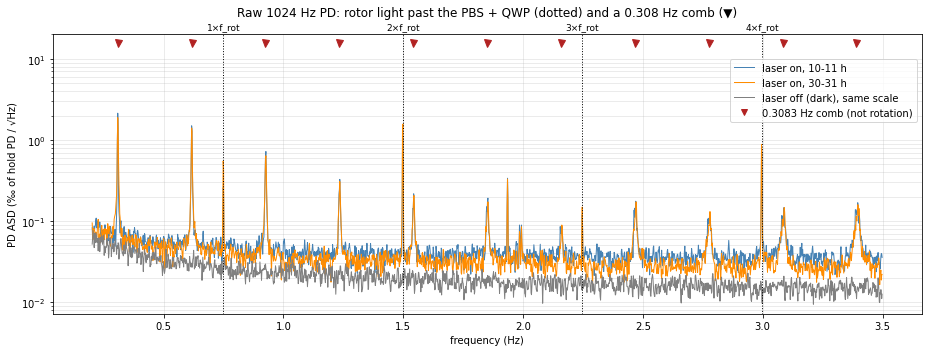


 hour | f_rot (Hz) | PD level | comb peak/floor | comb amp (permil)
  5.0 |     0.7492 |    470.6 |             620 |             0.145
 20.0 |     0.7492 |    470.4 |             881 |             0.161
 39.0 |     0.7492 |    472.0 |             665 |             0.151
 41.0 |     0.7492 |    439.5 |             180 |             0.108
 43.0 |     0.7483 |    407.2 |             408 |             0.120
 44.5 |     0.7483 |    404.9 |               2 |             0.036
 46.6 |     0.7883 |    390.0 |               3 |             0.062

 stretch | PD vs | coh @ 1x f_rot | coh @ 2x f_rot | coh @ comb
 10-11 h |   YAW |           0.88 |           0.99 |       0.04
 10-11 h |   PIT |           0.93 |           0.98 |       0.05
 30-31 h |   YAW |           0.99 |           1.00 |       0.29
 30-31 h |   PIT |           0.99 |           1.00 |       0.23
(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)


In [3]:
LEAK_H = (10, 30)       # 1 h stretches, hours from file start (both inside 1-40 h)
N_HARM = 4              # harmonics to tabulate, of f_rot and of the 0.308 Hz comb

def raw_asd(path, h0, dur=3600, nps_s=600):
    """Welch PSD of a raw 1024 Hz stretch [h0, h0+dur) h from file start (no gaps, checked in load)."""
    with h5py.File(path, 'r') as f:
        fsr = float(f.attrs['sample_rate']); a = int(h0*3600*fsr)
        y = f['data'][a:a + int(dur*fsr)].astype(float)
    fw, P = welch(y - y.mean(), fsr, nperseg=int(nps_s*fsr))
    return fw, P, y.mean()

def line(fw, P, f0, lvl):
    """Strongest bin within +-10 mHz of f0: (freq, peak/local median, amplitude in permil of lvl)."""
    m = (fw > f0 - 0.01) & (fw < f0 + 0.01); j = np.flatnonzero(m)[np.argmax(P[m])]
    amp = np.sqrt(2*P[j-2:j+3].sum()*(fw[1] - fw[0]))       # sinusoid amplitude, +-2 bins
    return fw[j], P[j]/np.median(P[max(j-200, 0):j+200]), amp/lvl*1e3

PD_HOLD = f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5'
LES_HOLD = f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'
PIT_HOLD = f'{DATA}/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_{GPS_A}_{GPS_B}.h5'
F_COMB = 0.3083         # Hz, comb fundamental (Welch peak, 1.7 mHz bins; same at 10 h and 30 h)

fig, ax = plt.subplots(figsize=(13, 5))
print(f"{'data':>13} | {'line':>9} | {'freq (Hz)':>9} | {'peak/floor':>10} | {'amp (permil of hold PD)':>23}")
for h0, col in zip(LEAK_H, ('steelblue', 'darkorange')):
    fw, P, lvl = raw_asd(PD_HOLD, h0)
    lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR   # rotation from the LES line
    m = (fw > 0.2) & (fw < 3.5)
    ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color=col, lw=1, label=f'laser on, {h0}-{h0+1} h')
    for name, f0 in [(f'{n}x f_rot', n*f_rot) for n in range(1, N_HARM+1)] + \
                    [(f'{n}x comb', n*F_COMB) for n in range(1, N_HARM+1)]:
        fj, pf, a = line(fw, P, f0, lvl)
        print(f'{"PD "+str(h0)+"-"+str(h0+1)+" h":>13} | {name:>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')
    for ch, (fq, Pq) in (('YAW', (fl, Pl)), ('PIT', raw_asd(PIT_HOLD, h0)[:2])):   # rotor motion, x and y
        fj, pf, _ = line(fq, Pq, F_COMB, 1)
        print(f'{ch+" "+str(h0)+"-"+str(h0+1)+" h":>13} | {"1x comb":>9} | {fj:9.4f} | {pf:10.0f} | {"(not in LES)" if pf < 10 else "PRESENT":>23}')

# laser off: same raw channel, 2-3 h into dataset 2, normalised to the HOLD PD level so it is directly comparable
fw, P, _ = raw_asd(f'{DATA}/PD/{DARK_FILE}', 2)
m = (fw > 0.2) & (fw < 3.5)
ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color='gray', lw=1, label='laser off (dark), same scale')
for n in range(1, N_HARM+1):
    fj, pf, a = line(fw, P, n*F_COMB, lvl)
    print(f'{"dark":>13} | {f"{n}x comb":>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')

for n in range(1, N_HARM+1):
    ax.axvline(n*f_rot, color='k', ls=':', lw=1)
    ax.text(n*f_rot, 1.01, f'{n}×f_rot', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=9)
for n in range(1, int(3.5/F_COMB) + 1):   # the comb runs to the plot edge
    ax.plot(n*F_COMB, 0.97, 'v', color='firebrick', ms=7, transform=ax.get_xaxis_transform())
ax.plot([], [], 'v', color='firebrick', label=f'{F_COMB} Hz comb (not rotation)')
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('PD ASD (‰ of hold PD / √Hz)')
ax.set_title('Raw 1024 Hz PD: rotor light past the PBS + QWP (dotted) and a 0.308 Hz comb (▼)', pad=18)
ax.set_ylim(top=20); ax.legend(loc='upper right', bbox_to_anchor=(1, 0.93)); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

# when does the comb switch off? 30 min stretches; f_rot from the LES line
print(f"\n{'hour':>5} | {'f_rot (Hz)':>10} | {'PD level':>8} | {'comb peak/floor':>15} | {'comb amp (permil)':>17}")
for h0 in (5, 20, 39, 41, 43, 44.5, 46.6):
    fw, P, lvl = raw_asd(PD_HOLD, h0, dur=1800); lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0, dur=1800)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR
    _, pf, a = line(fw, P, F_COMB, lvl)
    print(f'{h0:5.1f} | {f_rot:10.4f} | {lvl:8.1f} | {pf:15.0f} | {a:17.3f}')

# are the PD's rotor lines really rotor light? coherence with both LES axes (16 Hz is plenty below 3 Hz)
def raw16(path, h0, dur=3600):
    """Raw stretch decimated 1024 -> 16 Hz (FIR anti-alias)."""
    with h5py.File(path, 'r') as f:
        a = int(h0*3600*1024); y = f['data'][a:a + int(dur*1024)].astype(float)
    return decimate(decimate(y - y.mean(), 8, ftype='fir'), 8, ftype='fir')

print(f"\n{'stretch':>8} | {'PD vs':>5} | {'coh @ 1x f_rot':>14} | {'coh @ 2x f_rot':>14} | {'coh @ comb':>10}")
for h0 in LEAK_H:
    pd16, yaw16 = raw16(PD_HOLD, h0), raw16(LES_HOLD, h0)
    fq, Pq = welch(yaw16, fs=16, nperseg=16*600)
    mq = (fq > 1.3) & (fq < 1.7); f_rot = fq[mq][np.argmax(Pq[mq])]/DIVISOR
    for ch, sig in (('YAW', yaw16), ('PIT', raw16(PIT_HOLD, h0))):
        fc, C = coherence(pd16, sig, fs=16, nperseg=16*600)
        at = lambda f0: C[np.abs(fc - f0) < 0.003].max()
        print(f'{h0:3d}-{h0+1:<3d}h | {ch:>5} | {at(f_rot):14.2f} | {at(2*f_rot):14.2f} | {at(F_COMB):10.2f}')
print('(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)')

## 1. Rotor frequency

### 1.1 Frequency track

Tracker from `sensitivity_20260911.ipynb`: LES decimated to 16 Hz; 150 s Hann windows every 60 s;
largest FFT peak in a band (0.85–1.10×) re-centred on the last estimate; rotor = LES line / 2.
Two estimates per window, from the same peak bin i:

- `FR_RAW`: bin frequency fr[i], no interpolation;
- `FR`: fr[i] + three-point parabolic correction (the September method).

Tracking and SNR use `FR`, as before. `FR` is the base track: it centres the band for the §1.5
primary tracker and is used by σ_f(T) (§4) and the correlation (§6).

fs = 16 Hz, window 150 s = 2400 samples, step 60 s
bin spacing: df_optical = 1/150 s = 0.006667 Hz, df_rotor = 1/(2x150 s) = 0.003333 Hz
2873 estimates, FR 0.4125..0.7889 Hz, median SNR 622


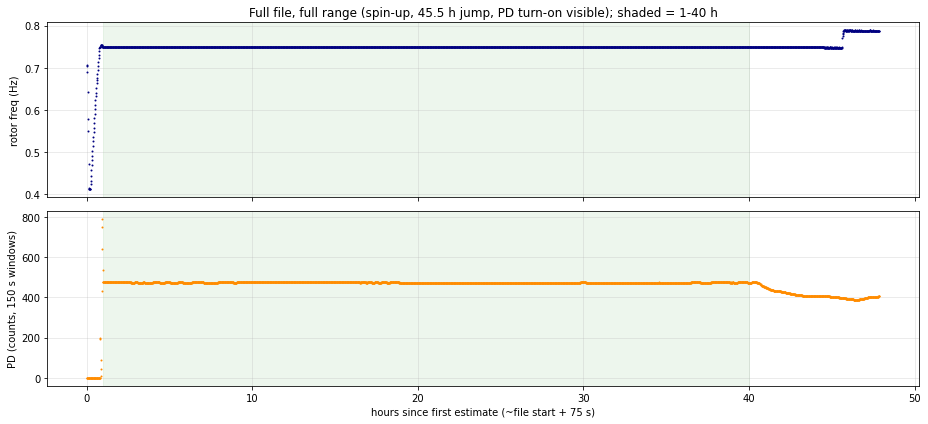

In [4]:
def peak_in_band(x, fsx, lo, hi):
    """Largest Hann-windowed FFT peak in (lo, hi). Returns (f_raw, f_interp, snr):
    f_raw is the peak bin's frequency fr[i]; f_interp adds the three-point parabolic correction."""
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fr[i], fpk, snr

y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16
T_FILE0 = t_les[0]; del les, t_les

WIN, STEP = 150.0, 60.0
nw, sw = int(WIN*fs16), int(STEP*fs16)
DF_OPT = fs16/nw                # FFT bin spacing of one window, in LES (optical) frequency
DF_ROT = DF_OPT/DIVISOR         # the same bin spacing expressed as rotor frequency
print(f'fs = {fs16:g} Hz, window {WIN:.0f} s = {nw} samples, step {STEP:.0f} s')
print(f'bin spacing: df_optical = 1/{WIN:.0f} s = {DF_OPT:.6f} Hz, '
      f'df_rotor = 1/({DIVISOR}x{WIN:.0f} s) = {DF_ROT:.6f} Hz')

rows, track = [], 1.50
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    fraw, fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.85, 0.02), track*1.10)
    if np.isnan(fpk) or fpk <= 0: continue
    rows.append((tc, fraw/DIVISOR, fpk/DIVISOR, snr))
    track = fpk
T, FR_RAW, FR, SNR = map(np.array, zip(*rows))
T_REF = T[0]                  # hours are counted from the first tracker estimate (as in September)
H_ALL = (T - T_REF)/3600
print(f'{len(T)} estimates, FR {FR.min():.4f}..{FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

# PD averaged over exactly the same 150 s windows -> one shared time grid for section 6
PDW = np.array([pd1[(tpd1 >= tc - WIN/2) & (tpd1 < tc + WIN/2)].mean() for tc in T])

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(H_ALL, FR, '.', ms=2, color='navy'); ax[0].set_ylabel('rotor freq (Hz)')
ax[1].plot(H_ALL, PDW, '.', ms=2, color='darkorange'); ax[1].set_ylabel('PD (counts, 150 s windows)')
for a in ax:
    a.axvspan(*WIN_H, color='green', alpha=0.07); a.grid(alpha=.3)
ax[1].set_xlabel('hours since first estimate (~file start + 75 s)')
ax[0].set_title(f'Full file, full range (spin-up, 45.5 h jump, PD turn-on visible); shaded = {WIN_H[0]}-{WIN_H[1]} h')
plt.tight_layout(); plt.show()

### 1.2 Analysis window: 1–40 h

After 40 h the operating point isn't stationary: the PD slides ~15% from 40.5 h, the frequency dips
~0.7 mHz in 43–45 h and jumps to ~0.788 Hz at 45.5 h (none investigated here). `mref` selects
1–40 h (hours from the first estimate) and is used throughout. The 2 h blocks: steady over 1–41 h.

In [5]:
mref = (H_ALL >= WIN_H[0]) & (H_ALL <= WIN_H[1])   # the 1-40 h analysis window, used throughout

print(f"{'hours':>7} | {'mean f (Hz)':>11} | {'std (mHz)':>9} | {'mean PD':>8}")
for a in range(1, 47, 2):
    m = (H_ALL >= a) & (H_ALL < a+2)
    print(f'{a:3d}-{a+2:<3d} | {FR[m].mean():11.5f} | {FR[m].std()*1e3:9.3f} | {PDW[m].mean():8.1f}')

  hours | mean f (Hz) | std (mHz) |  mean PD
  1-3   |     0.74897 |     0.101 |    475.4
  3-5   |     0.74898 |     0.111 |    473.5
  5-7   |     0.74887 |     0.110 |    473.6
  7-9   |     0.74900 |     0.134 |    473.5
  9-11  |     0.74915 |     0.068 |    474.3
 11-13  |     0.74908 |     0.080 |    474.9
 13-15  |     0.74902 |     0.084 |    475.7
 15-17  |     0.74901 |     0.083 |    475.1
 17-19  |     0.74897 |     0.090 |    474.6
 19-21  |     0.74903 |     0.113 |    472.7
 21-23  |     0.74914 |     0.092 |    473.2
 23-25  |     0.74910 |     0.092 |    472.7
 25-27  |     0.74908 |     0.080 |    473.2
 27-29  |     0.74908 |     0.084 |    473.0
 29-31  |     0.74906 |     0.065 |    473.4
 31-33  |     0.74907 |     0.073 |    473.2
 33-35  |     0.74906 |     0.075 |    473.4
 35-37  |     0.74909 |     0.078 |    473.6
 37-39  |     0.74908 |     0.096 |    473.9
 39-41  |     0.74910 |     0.083 |    470.9
 41-43  |     0.74904 |     0.151 |    427.5
 43-45  | 

### 1.3 Estimator check: raw bin vs parabolic interpolation

Does the interpolation create the ~0.1 mHz wander? Compare `FR_RAW` (A) with `FR` (B).

| | value | meaning |
|---|---|---|
| optical line | ~1.498 Hz | LES peak (two wings → two per turn) |
| f_rotor | ~0.749 Hz | optical / 2; the tracked quantity |
| df | 6.67 mHz optical, 3.33 mHz rotor | bin spacing of a 150 s window: step between A's possible *values* |
| ν | ~65 µHz – 8.3 mHz | Fourier frequency of the fluctuations: how *fast* f_rotor wanders |

df resolves the value of f; ν is its rate of change. Unrelated axes.

In [6]:
fA, fB, h11 = FR_RAW[mref], FR[mref], H_ALL[mref]      # 1-40 h (mref from 1.2)
dAB = fB - fA
print(f'bin spacing: df_optical = {DF_OPT:.6f} Hz, df_rotor = {DF_ROT:.6f} Hz')
print(f'{WIN_H[0]}-{WIN_H[1]} h, {mref.sum()} windows')
print(f'  A raw bin      : mean {fA.mean():.6f} Hz, std {fA.std()*1e3:.4f} mHz, '
      f'{len(np.unique(fA))} unique value(s): {np.unique(fA)} Hz')
print(f'  B interpolated : mean {fB.mean():.6f} Hz, std {fB.std()*1e3:.4f} mHz '
      f'(= {fB.std()/DF_ROT:.3f} of a bin)')
print(f'  B - A          : RMS {np.sqrt(np.mean(dAB**2))*1e3:.4f} mHz, max |B-A| {np.abs(dAB).max()*1e3:.4f} mHz')
print(f'  interpolation offset (B-A)/df_rotor: mean {dAB.mean()/DF_ROT:+.3f}, std {dAB.std()/DF_ROT:.3f}, '
      f'range {dAB.min()/DF_ROT:+.3f} .. {dAB.max()/DF_ROT:+.3f} bins')

bin spacing: df_optical = 0.006667 Hz, df_rotor = 0.003333 Hz
1-40 h, 2341 windows
  A raw bin      : mean 0.750000 Hz, std 0.0000 mHz, 1 unique value(s): [0.75] Hz
  B interpolated : mean 0.749046 Hz, std 0.1121 mHz (= 0.034 of a bin)
  B - A          : RMS 0.9611 mHz, max |B-A| 1.4386 mHz
  interpolation offset (B-A)/df_rotor: mean -0.286, std 0.034, range -0.432 .. -0.158 bins


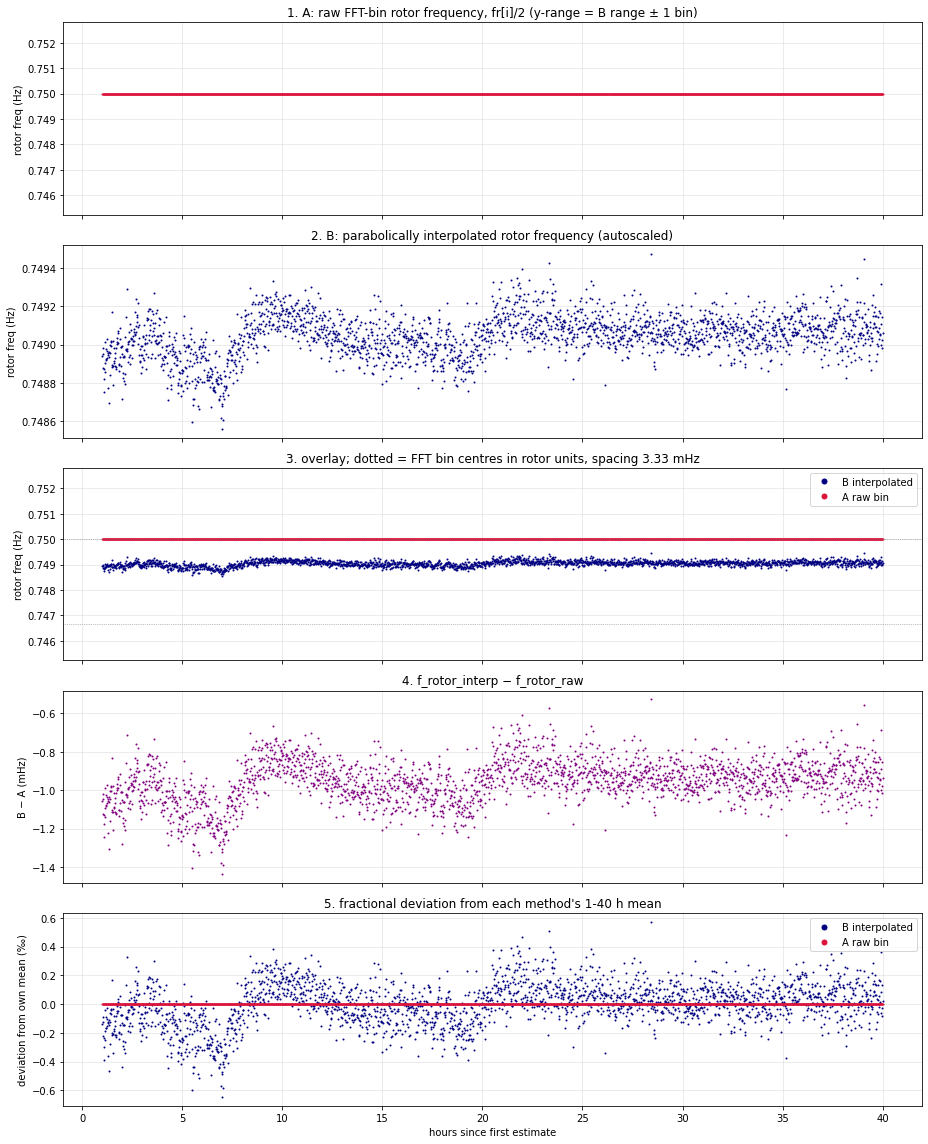

In [7]:
fig, ax = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
lim = (fB.min() - DF_ROT, fB.max() + DF_ROT)          # one bin either side of B's range
bins = np.arange(np.floor(lim[0]/DF_ROT), np.ceil(lim[1]/DF_ROT) + 1)*DF_ROT

ax[0].plot(h11, fA, '.', ms=2, color='crimson'); ax[0].set_ylim(lim)
ax[0].set_title('1. A: raw FFT-bin rotor frequency, fr[i]/2 (y-range = B range ± 1 bin)')
ax[1].plot(h11, fB, '.', ms=2, color='navy')
ax[1].set_title('2. B: parabolically interpolated rotor frequency (autoscaled)')
ax[2].plot(h11, fB, '.', ms=2, color='navy', label='B interpolated')
ax[2].plot(h11, fA, '.', ms=2, color='crimson', label='A raw bin')
for fk in bins: ax[2].axhline(fk, color='gray', lw=0.7, ls=':')
ax[2].set_ylim(lim); ax[2].legend(loc='upper right', markerscale=5)
ax[2].set_title(f'3. overlay; dotted = FFT bin centres in rotor units, spacing {DF_ROT*1e3:.2f} mHz')
for a in ax[:3]: a.set_ylabel('rotor freq (Hz)')

ax[3].plot(h11, dAB*1e3, '.', ms=2, color='purple')
ax[3].set_ylabel('B − A (mHz)'); ax[3].set_title('4. f_rotor_interp − f_rotor_raw')
ax[4].plot(h11, (fB/fB.mean() - 1)*1e3, '.', ms=2, color='navy', label='B interpolated')
ax[4].plot(h11, (fA/fA.mean() - 1)*1e3, '.', ms=2, color='crimson', label='A raw bin')
ax[4].set_ylabel('deviation from own mean (‰)'); ax[4].legend(loc='upper right', markerscale=5)
ax[4].set_title(f'5. fractional deviation from each method\'s {WIN_H[0]}-{WIN_H[1]} h mean')
ax[4].set_xlabel('hours since first estimate')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**One window's spectrum.** Dots: FFT bins. Line: ×16 zero-padded, the continuous spectrum the bins
sample. A = tallest bin. B = vertex of a parabola through it and its neighbours: an estimate of the
continuous peak, *assuming one isolated Hann-shaped line*. No added Fourier resolution: lines
< ~1 bin apart still merge. Right: the four scales on one axis.

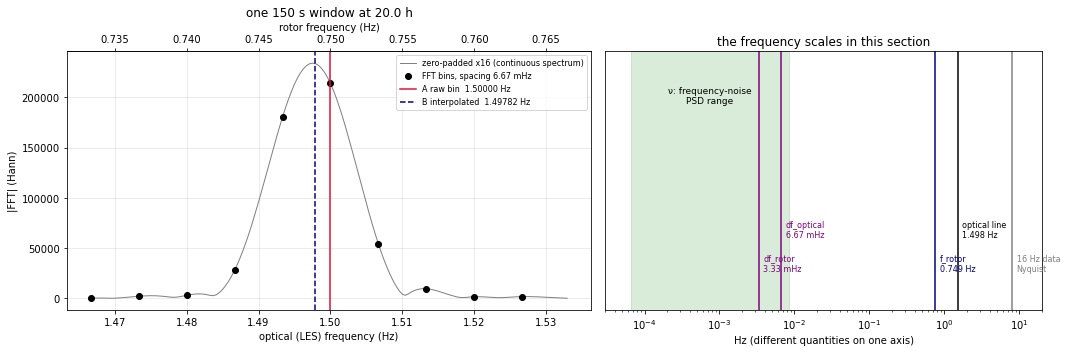

In [8]:
j = np.argmin(abs(H_ALL - 20))                         # one window at 20 h
i0 = int(round((T[j] - WIN/2 - t16[0])*fs16))
seg = y16[i0:i0+nw]; seg = (seg - seg.mean())*np.hanning(nw)
fr_b, X_b = np.fft.rfftfreq(nw, 1/fs16), np.abs(np.fft.rfft(seg))
fr_z, X_z = np.fft.rfftfreq(16*nw, 1/fs16), np.abs(np.fft.rfft(seg, 16*nw))
fraw_j, fint_j, _ = peak_in_band(y16[i0:i0+nw], fs16, 1.27, 1.65)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw=dict(width_ratios=[1.2, 1]))
w = (fr_b > fraw_j - 5*DF_OPT) & (fr_b < fraw_j + 5*DF_OPT)
wz = (fr_z > fraw_j - 5*DF_OPT) & (fr_z < fraw_j + 5*DF_OPT)
ax[0].plot(fr_z[wz], X_z[wz], color='gray', lw=1, label='zero-padded x16 (continuous spectrum)')
ax[0].plot(fr_b[w], X_b[w], 'o', color='k', label=f'FFT bins, spacing {DF_OPT*1e3:.2f} mHz')
ax[0].axvline(fraw_j, color='crimson', lw=1.5, label=f'A raw bin  {fraw_j:.5f} Hz')
ax[0].axvline(fint_j, color='navy', lw=1.5, ls='--', label=f'B interpolated  {fint_j:.5f} Hz')
ax[0].set_xlabel('optical (LES) frequency (Hz)'); ax[0].set_ylabel('|FFT| (Hann)')
ax[0].set_title(f'one 150 s window at {H_ALL[j]:.1f} h'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
sec = ax[0].secondary_xaxis('top', functions=(lambda x: x/DIVISOR, lambda x: x*DIVISOR))
sec.set_xlabel('rotor frequency (Hz)')

NPS_NU = 256                                           # Welch segment for the PSD below (as in section 3)
nu_lo, nu_hi = 1/(NPS_NU*STEP), 1/(2*STEP)
ax[1].axvspan(nu_lo, nu_hi, color='green', alpha=0.15)
ax[1].text(np.sqrt(nu_lo*nu_hi), 0.8, 'ν: frequency-noise\nPSD range', ha='center', fontsize=9)
marks = [(DF_ROT, 'df_rotor\n3.33 mHz', 'purple'), (DF_OPT, 'df_optical\n6.67 mHz', 'purple'),
         (fB.mean(), 'f_rotor\n0.749 Hz', 'navy'), (fB.mean()*DIVISOR, 'optical line\n1.498 Hz', 'k'),
         (fs16/2, '16 Hz data\nNyquist', 'gray')]
for k, (x, lab, c) in enumerate(marks):
    ax[1].axvline(x, color=c, lw=1.5); ax[1].text(x*1.15, 0.15 + 0.13*(k % 2), lab, fontsize=8, color=c)
ax[1].set_xscale('log'); ax[1].set_xlim(3e-5, 20); ax[1].set_ylim(0, 1); ax[1].set_yticks([])
ax[1].set_xlabel('Hz (different quantities on one axis)'); ax[1].set_title('the frequency scales in this section')
plt.tight_layout(); plt.show()

**Synthetic check.** Pure tones through the same `peak_in_band`, stepped across one bin:
1. bias of B vs position in the bin;
2. gain dB/d(true) (1 = sub-bin shifts reported at true size);
3. scatter of B from white noise at the measured median SNR.

Model: one stationary tone + white noise. Harmonics, AM and non-white motion near the line are not simulated.

observed B offset -0.286 bins -> true offset -0.338 bins, bias there +0.0517 bins = +0.172 mHz rotor (constant; shifts the mean only)
gain dB/dtrue: 1.07 at the operating point, 1.00..1.15 over ±1σ, 0.86..1.42 over the full 1-40 h range
A for a pure tone: bin 225 for every true offset in (-0.5, 0.5) -> constant 0.7500 Hz rotor
white noise at SNR 541 (measured median 546): B scatter 0.0038 mHz rotor vs observed B std 0.1121 mHz (30x larger)


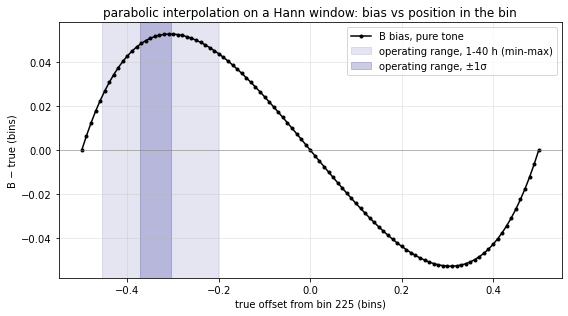

In [9]:
tt = np.arange(nw)/fs16
k0 = int(round(fA.mean()*DIVISOR/DF_OPT))            # A's bin index (225 -> 1.500 Hz optical)
band = (1.50*0.85, 1.50*1.10)
def est_B(d, noise=0.0, n=8, rng=None):
    """mean and std of B (optical Hz) for a tone at bin k0+d, averaged over n phases / noise draws"""
    out = []
    for p in np.linspace(0, 2*np.pi, n, endpoint=False):
        x = np.sin(2*np.pi*(k0 + d)*DF_OPT*tt + p)
        if noise: x = x + noise*rng.standard_normal(nw)
        out.append(peak_in_band(x, fs16, *band)[1:])
    out = np.array(out)
    return out[:, 0].mean(), out[:, 0].std(), np.median(out[:, 1])

d_true = np.linspace(-0.5, 0.5, 101)
bias = np.array([(est_B(d)[0] - (k0 + d)*DF_OPT)/DF_OPT for d in d_true])

# operating point: the true offset whose (biased) B matches the observed mean B offset
d_obs = dAB.mean()/DF_ROT
d_op = np.interp(d_obs, d_true + bias, d_true)
gain = 1 + np.gradient(bias, d_true)                  # dB/dtrue: how a real sub-bin shift is reported
d_lo, d_hi = (np.interp(v/DF_ROT, d_true + bias, d_true) for v in (dAB.min(), dAB.max()))
d_1s = d_op + np.array([-1, 1])*dAB.std()/DF_ROT
g_1s = np.interp(d_1s, d_true, gain); g_all = gain[(d_true >= d_lo) & (d_true <= d_hi)]

rng = np.random.default_rng(0)
_, _, snr0 = est_B(d_op, noise=0.03, n=50, rng=rng)
sig = 0.03*snr0/np.median(SNR[mref])                  # noise level giving the measured median SNR
_, sdB, snr_sim = est_B(d_op, noise=sig, n=300, rng=rng)
sd_noise = sdB/DIVISOR                                 # rotor Hz

print(f'observed B offset {d_obs:+.3f} bins -> true offset {d_op:+.3f} bins, '
      f'bias there {np.interp(d_op, d_true, bias):+.4f} bins = '
      f'{np.interp(d_op, d_true, bias)*DF_ROT*1e3:+.3f} mHz rotor (constant; shifts the mean only)')
print(f'gain dB/dtrue: {np.interp(d_op, d_true, gain):.2f} at the operating point, '
      f'{g_1s.min():.2f}..{g_1s.max():.2f} over ±1σ, {g_all.min():.2f}..{g_all.max():.2f} over the full 1-40 h range')
print(f'A for a pure tone: bin {k0} for every true offset in (-0.5, 0.5) -> constant {k0*DF_ROT:.4f} Hz rotor')
print(f'white noise at SNR {snr_sim:.0f} (measured median {np.median(SNR[mref]):.0f}): '
      f'B scatter {sd_noise*1e3:.4f} mHz rotor vs observed B std {fB.std()*1e3:.4f} mHz '
      f'({fB.std()/sd_noise:.0f}x larger)')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(d_true, bias, 'k.-', label='B bias, pure tone')
ax.axvspan(d_lo, d_hi, color='navy', alpha=0.1, label='operating range, 1-40 h (min-max)')
ax.axvspan(*d_1s, color='navy', alpha=0.2, label='operating range, ±1σ')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(f'true offset from bin {k0} (bins)'); ax.set_ylabel('B − true (bins)')
ax.set_title('parabolic interpolation on a Hann window: bias vs position in the bin')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**PSD of each estimator.** δf = f − mean(1–40 h); Welch, fs from timestamps (60 s, Nyquist 8.3 mHz),
nperseg 256, `detrend=False`. Dotted: white floor of the simulated estimator scatter (2σ²/fs), a model.

second-stage sampling: fs = 1/60.0 s = 1.667e-02 Hz, Nyquist 8.33 mHz, nperseg 256 -> resolution 65.1 µHz
  A raw bin      : var 0.000e+00 Hz², integral of PSD 0.000e+00 Hz², max S 0.000e+00 Hz²/Hz
  B interpolated : var 1.256e-08 Hz², integral of PSD 1.099e-08 Hz², max S 4.196e-05 Hz²/Hz


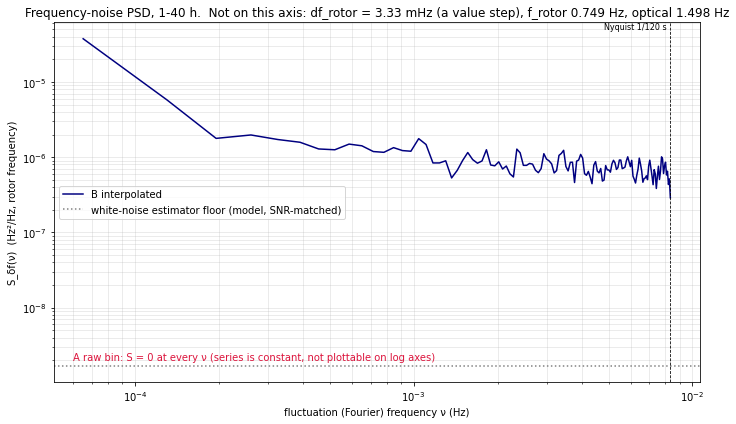

In [10]:
dtA = np.diff(T[mref])
fs_nu = 1/np.median(dtA)
assert np.allclose(dtA, 1/fs_nu), 'uneven cadence in 1-40 h: Welch needs an even grid'
print(f'second-stage sampling: fs = 1/{1/fs_nu:.1f} s = {fs_nu:.3e} Hz, Nyquist {fs_nu/2*1e3:.2f} mHz, '
      f'nperseg {NPS_NU} -> resolution {fs_nu/NPS_NU*1e6:.1f} µHz')

S = {}
for name, f in (('A raw bin', fA), ('B interpolated', fB)):
    nu, S[name] = welch(f - f.mean(), fs=fs_nu, nperseg=NPS_NU, detrend=False)
    print(f'  {name:15s}: var {np.var(f):.3e} Hz², integral of PSD {np.trapz(S[name], nu):.3e} Hz²,'
          f' max S {S[name].max():.3e} Hz²/Hz')

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(nu[1:], S['B interpolated'][1:], color='navy', label='B interpolated')
if (S['A raw bin'][1:] > 0).any():
    ax.loglog(nu[1:], S['A raw bin'][1:], color='crimson', label='A raw bin')
else:
    ax.text(0.03, 0.06, 'A raw bin: S = 0 at every ν (series is constant, not plottable on log axes)',
            transform=ax.transAxes, color='crimson')
ax.axhline(2*sd_noise**2/fs_nu, color='gray', ls=':', label='white-noise estimator floor (model, SNR-matched)')
ax.axvline(fs_nu/2, color='k', lw=0.8, ls='--'); ax.text(fs_nu/2*0.97, ax.get_ylim()[1], 'Nyquist 1/120 s',
                                                         ha='right', va='top', fontsize=8)
ax.set_xlabel('fluctuation (Fourier) frequency ν (Hz)')
ax.set_ylabel('S_δf(ν)  (Hz²/Hz, rotor frequency)')
ax.set_title(f'Frequency-noise PSD, {WIN_H[0]}-{WIN_H[1]} h.  Not on this axis: '
             f'df_rotor = {DF_ROT*1e3:.2f} mHz (a value step), f_rotor 0.749 Hz, optical 1.498 Hz')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

**Result (1–40 h):**
- **A is constant:** bin 225 (0.75000 Hz rotor) in every window. B's wander (std 0.11 mHz) spans
  ~0.07 bin, ~0.29 bin below bin 225, never near a bin edge. B − A (RMS 0.96, max 1.44 mHz) is
  mostly the constant offset.
- So B − A and the PSD difference measure A's quantisation, not estimator sensitivity. Zero from A
  doesn't mean no wander; non-zero B doesn't by itself prove it real.
- **Synthetic check:** the interpolation doesn't create the wander (white-noise scatter ~0.004 mHz,
  30× below observed). It does scale it: gain 1.07 at the operating point, 1.00–1.15 over ±1σ,
  0.86–1.42 at the extremes (~0.75 at a bin centre). The constant bias, +0.05 bin (+0.17 mHz;
  true mean ≈ 0.74888 Hz), cancels in δf.
- **Not covered:** frequency change within a window, AM, non-white motion near 1.5 Hz. A fully
  independent check would track the line's phase.

### 1.4 Window length: 150 / 300 / 600 s (robustness check only)

Same tracker at WIN = 150, 300, 600 s, STEP = 60 s; the 150 s run must reproduce `FR` exactly.

**One change for 300/600 s:** the band is centred on the 150 s estimate at the same time. Left
self-tracking, they lose the 1.498 Hz line during spin-up and lock onto the 3× (2.247 Hz) and
4× (2.996 Hz) rotation harmonics. Band width and `peak_in_band` unchanged.

δf = f − mean(1–40 h) removes constant offsets. Timestamps are window centres (offsets 75 s, 225 s);
1–40 h is the same absolute stretch for all three.

**Longer windows low-pass the track** (and overlap up to 90%), so less high-ν power at long WIN is
expected and is not a better measurement. The test is agreement at hour scales (ν ≤ 1/3600 s).

In [11]:
def track_rotor(win, step=STEP, guide=False):
    """The §1.1 tracking loop at window length win. Rotor Hz.
    guide=True centres the band on the 150 s track (FR) at the window centre instead of on
    this window's own last estimate -- the only change, needed to stay on the 1.498 Hz line.
    Returns (T, f_raw, f_interp, snr)."""
    nw_, sw_ = int(win*fs16), int(step*fs16)
    rows_, trk = [], 1.50
    for i in range(0, len(y16)-nw_, sw_):
        tc = t16[i] + win/2
        if guide: trk = np.interp(tc, T, FR)*DIVISOR
        fraw, fpk, snr = peak_in_band(y16[i:i+nw_], fs16, max(trk*0.85, 0.02), trk*1.10)
        if np.isnan(fpk) or fpk <= 0: continue
        rows_.append((tc, fraw/DIVISOR, fpk/DIVISOR, snr))
        trk = fpk
    return map(np.array, zip(*rows_))

WINS = (150, 300, 600)
WCOL = {150: 'navy', 300: 'darkorange', 600: 'forestgreen'}
N_RM = int(round(1800/STEP))                            # 30 min running mean, as in 6.1
TRK = {}
print(f"{'WIN':>5} | {'df_optical':>10} | {'df_rotor':>10} | {'N':>5} | {'mean f (Hz)':>11} | "
      f"{'std δf (mHz)':>12} | {'std 30-min mean (mHz)':>21} | {'sub-bin offset':>14} | {'interp gain':>11}")
for w in WINS:
    Tw, Rw, Fw, _ = track_rotor(w, guide=(w != 150))
    m = ((Tw - T_REF)/3600 >= WIN_H[0]) & ((Tw - T_REF)/3600 <= WIN_H[1])
    d = Fw[m] - Fw[m].mean()
    TRK[w] = dict(t=Tw[m], h=(Tw[m] - T_REF)/3600, f=Fw[m], d=d,
                  rm=uniform_filter1d(d, N_RM, mode='nearest'))
    dfo = fs16/int(w*fs16)
    off = ((Fw[m] - Rw[m])/(dfo/DIVISOR)).mean()             # observed B offset from the peak bin, in bins
    g = np.interp(np.interp(off, d_true + bias, d_true), d_true, gain)   # 1.3 pure-tone gain at that offset
    print(f'{w:5d} | {dfo:10.6f} | {dfo/DIVISOR:10.6f} | {m.sum():5d} | {Fw[m].mean():11.6f} | '
          f'{d.std()*1e3:12.4f} | {TRK[w]["rm"].std()*1e3:21.4f} | {off:+14.3f} | {g:11.2f}')
assert np.array_equal(TRK[150]['f'], FR[mref]) and np.array_equal(TRK[150]['t'], T[mref]), \
    '150 s re-run does not reproduce FR'
print('(Hz; df_optical = 1/WIN, df_rotor = 1/(2 WIN).)  150 s re-run reproduces FR exactly.')
print('sub-bin offset = mean interpolation offset (bins); interp gain = dB/d(true) there, from the 1.3 pure-tone check')

# slow structure: compare the 30 min running means on the 150 s time grid
print('\n30 min running means vs 150 s (interpolated onto the 150 s timestamps):')
for w in WINS[1:]:
    rm_w = np.interp(TRK[150]['t'], TRK[w]['t'], TRK[w]['rm'])
    r = np.corrcoef(TRK[150]['rm'], rm_w)[0, 1]
    print(f'  {w} s: correlation {r:.3f}, std of difference {(rm_w - TRK[150]["rm"]).std()*1e3:.4f} mHz')

  WIN | df_optical |   df_rotor |     N | mean f (Hz) | std δf (mHz) | std 30-min mean (mHz) | sub-bin offset | interp gain
  150 |   0.006667 |   0.003333 |  2341 |    0.749046 |       0.1121 |                0.0755 |         -0.286 |        1.07
  300 |   0.003333 |   0.001667 |  2340 |    0.748793 |       0.0892 |                0.0702 |         +0.276 |        1.04
  600 |   0.001667 |   0.000833 |  2340 |    0.748910 |       0.0936 |                0.0832 |         -0.237 |        0.97
(Hz; df_optical = 1/WIN, df_rotor = 1/(2 WIN).)  150 s re-run reproduces FR exactly.
sub-bin offset = mean interpolation offset (bins); interp gain = dB/d(true) there, from the 1.3 pure-tone check

30 min running means vs 150 s (interpolated onto the 150 s timestamps):
  300 s: correlation 0.996, std of difference 0.0087 mHz
  600 s: correlation 0.997, std of difference 0.0097 mHz


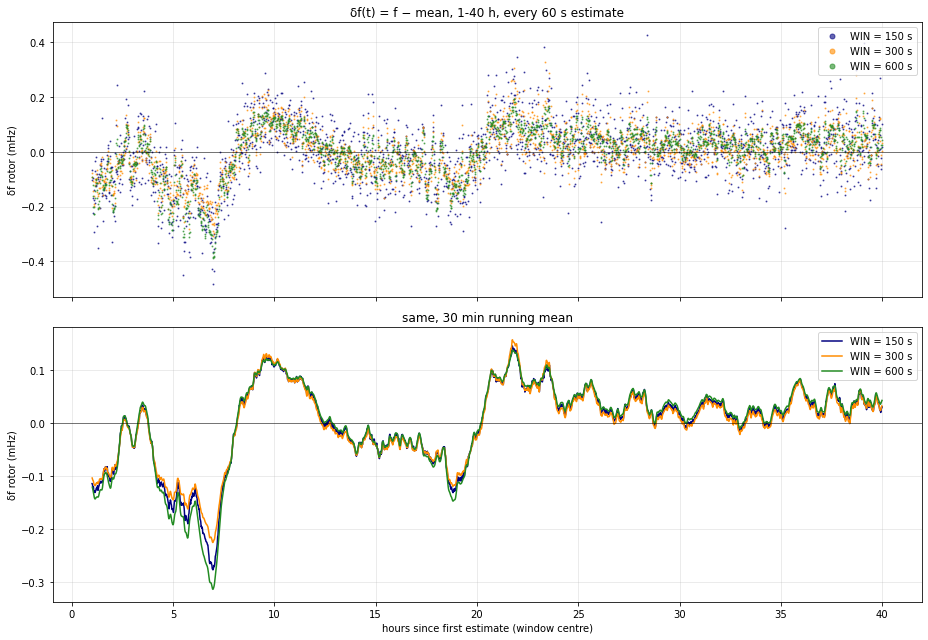

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for w in WINS:
    ax[0].plot(TRK[w]['h'], TRK[w]['d']*1e3, '.', ms=2, color=WCOL[w], alpha=0.6, label=f'WIN = {w} s')
    ax[1].plot(TRK[w]['h'], TRK[w]['rm']*1e3, color=WCOL[w], lw=1.5, label=f'WIN = {w} s')
ax[0].set_title(f'δf(t) = f − mean, {WIN_H[0]}-{WIN_H[1]} h, every 60 s estimate')
ax[1].set_title('same, 30 min running mean')
for a in ax:
    a.axhline(0, color='k', lw=0.5); a.set_ylabel('δf rotor (mHz)'); a.grid(alpha=.3)
    a.legend(loc='upper right', markerscale=5)
ax[1].set_xlabel('hours since first estimate (window centre)')
plt.tight_layout(); plt.show()

Welch: fs = 1/60 s, nperseg 256, detrend=False (as in 1.3)
hour-scale band 0 < ν ≤ 1/3600 s: bins at 65, 130, 195, 260 µHz
  WIN | mean S, hour-scale (Hz²/Hz) | ratio to 150 s | per-bin ratios to 150 s
  150 |                   1.174e-05 |          1.000 | 1.00  1.00  1.00  1.00
  300 |                   1.005e-05 |          0.856 | 0.85  0.84  0.95  0.86
  600 |                   1.406e-05 |          1.198 | 1.21  1.19  1.08  1.11


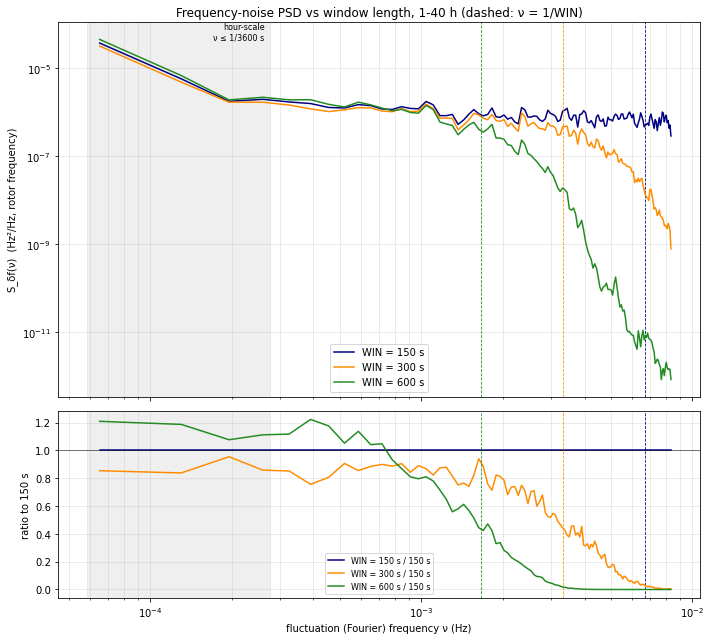

In [13]:
S_w = {}
for w in WINS:
    dt_w = np.diff(TRK[w]['t'])
    assert np.allclose(dt_w, STEP), f'uneven cadence at WIN = {w} s'
    nu_w, S_w[w] = welch(TRK[w]['d'], fs=1/STEP, nperseg=NPS_NU, detrend=False)
NU_HR = 1/3600
hr = (nu_w > 0) & (nu_w <= NU_HR)
print(f'Welch: fs = 1/{STEP:.0f} s, nperseg {NPS_NU}, detrend=False (as in 1.3)')
print(f'hour-scale band 0 < ν ≤ 1/3600 s: bins at {", ".join(f"{v*1e6:.0f}" for v in nu_w[hr])} µHz')
print(f"{'WIN':>5} | {'mean S, hour-scale (Hz²/Hz)':>27} | {'ratio to 150 s':>14} | {'per-bin ratios to 150 s'}")
for w in WINS:
    print(f'{w:5d} | {S_w[w][hr].mean():27.3e} | {S_w[w][hr].mean()/S_w[150][hr].mean():14.3f} | '
          + '  '.join(f'{x:.2f}' for x in S_w[w][hr]/S_w[150][hr]))

fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
for w in WINS:
    ax[0].loglog(nu_w[1:], S_w[w][1:], color=WCOL[w], label=f'WIN = {w} s')
    ax[1].semilogx(nu_w[1:], S_w[w][1:]/S_w[150][1:], color=WCOL[w], label=f'WIN = {w} s / 150 s')
    for a in ax: a.axvline(1/w, color=WCOL[w], lw=0.8, ls='--')
for a in ax:
    a.axvspan(nu_w[1]*0.9, NU_HR, color='gray', alpha=0.12)
    a.grid(alpha=.3, which='both')
ax[0].text(NU_HR*0.95, ax[0].get_ylim()[1], 'hour-scale\nν ≤ 1/3600 s', ha='right', va='top', fontsize=8)
ax[0].set_ylabel('S_δf(ν)  (Hz²/Hz, rotor frequency)'); ax[0].legend()
ax[0].set_title(f'Frequency-noise PSD vs window length, {WIN_H[0]}-{WIN_H[1]} h (dashed: ν = 1/WIN)')
ax[1].axhline(1, color='k', lw=0.5); ax[1].set_ylabel('ratio to 150 s'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('fluctuation (Fourier) frequency ν (Hz)')
plt.tight_layout(); plt.show()

**Result (1–40 h):**
- **Hour-scale structure agrees:** 30 min running means correlate at 0.996 (300 s) and 0.997 (600 s)
  with 150 s; difference std ~0.01 mHz vs 0.07–0.08 mHz of structure. Largest disagreement: the
  5–7 h dip, ~0.04 mHz deeper at 600 s.
- **Hour-scale PSD within ±20%** (0.86×, 1.20×; ±10% in amplitude). Not monotonic in WIN and not
  explained by the operating-point gains (1.07, 1.04, 0.97). Recorded, not explained.
- **Above ~1 mHz the PSDs separate:** window filtering (600 s from ~1 mHz, 300 s from ~2 mHz).
  Less bandwidth, not less rotor noise.
- **For σ_f(T):** WIN changes the result by ≲10% for T ≳ 1 h; at shorter T it sets the result.

### 1.5 Rotor frequency-noise PSD (primary)

**Primary tracker: 60 s window, 20 s step** (`track_rotor`, §1.4; band centred on the 150 s track, since
a self-tracking 60 s window locks onto the 3× rotation line during spin-up). Used for the thermal-noise
and Pb-212 comparisons from here on:
- δf(t) = f(t) − f0, f0 = mean over 1–40 h, in Hz;
- S_δf(ν) in Hz²/Hz: **one Hann periodogram over the full record** (`detrend=False`), fs from the timestamps.

Faint: raw bins (χ², 2 dof, roughly ±100% each). Solid: log-binned average (10 per decade). Method checks are in §1.6.

mean rotor frequency f0 (1-40 h) = 0.749140 Hz
std of delta_f                        = 1.396e-04 Hz = 0.1396 mHz
tracker                               = 60 s window, 20 s step
total duration                        = 7020 estimates x 20 s = 39.00 h
Fourier resolution 1/T                = 7.123e-06 Hz
Nyquist frequency                     = 2.500e-02 Hz  (period 40 s)


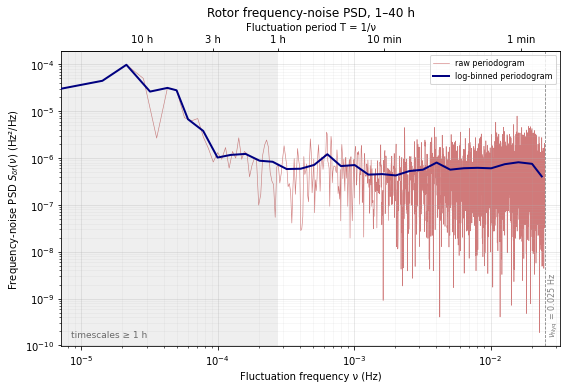

In [14]:
from scipy.signal import periodogram

def log_bin(nu, S, per_decade=10):
    """Average S in log-spaced ν bins (ν > 0). Returns (ν geometric mean, mean S, n bins)."""
    edges = 10**np.arange(np.log10(nu[1]), np.log10(nu[-1]) + 1/per_decade, 1/per_decade)
    idx = np.digitize(nu[1:], edges)
    out = [(np.exp(np.log(nu[1:][idx == k]).mean()), S[1:][idx == k].mean(), (idx == k).sum())
           for k in np.unique(idx)]
    return map(np.array, zip(*out))

WIN_P, STEP_P = 60.0, 20.0                              # primary tracker
T_60, R_60, F_60, SNR_60 = track_rotor(WIN_P, step=STEP_P, guide=True)
m60 = ((T_60 - T_REF)/3600 >= WIN_H[0]) & ((T_60 - T_REF)/3600 <= WIN_H[1])
t_p, f_p = T_60[m60], F_60[m60]
assert abs(f_p.mean() - FR[mref].mean()) < 1e-3, 'primary track is not on the 1.498 Hz line'
dt_p = np.diff(t_p)
assert np.allclose(dt_p, dt_p[0]), 'uneven cadence'
fs_p = 1/np.median(dt_p)
f0 = f_p.mean()
delta_f = f_p - f0                                      # Hz
nu_p, S_df = periodogram(delta_f, fs=fs_p, window='hann', detrend=False)   # one segment, full record
nu_lb, S_lb, n_lb = log_bin(nu_p, S_df)
T_rec = len(delta_f)/fs_p

print(f'mean rotor frequency f0 ({WIN_H[0]}-{WIN_H[1]} h) = {f0:.6f} Hz')
print(f'std of delta_f                        = {delta_f.std():.3e} Hz = {delta_f.std()*1e3:.4f} mHz')
print(f'tracker                               = {WIN_P:.0f} s window, {STEP_P:.0f} s step')
print(f'total duration                        = {len(delta_f)} estimates x {1/fs_p:.0f} s = {T_rec/3600:.2f} h')
print(f'Fourier resolution 1/T                = {1/T_rec:.3e} Hz')
print(f'Nyquist frequency                     = {fs_p/2:.3e} Hz  (period {2/fs_p:.0f} s)')

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_p[1:], S_df[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1, label='raw periodogram')
ax.loglog(nu_lb, S_lb, color='navy', lw=2.0, zorder=3, label='log-binned periodogram')
ax.axvline(fs_p/2, color='gray', lw=0.8, ls='--')
ax.text(fs_p/2*1.04, 0.03, f'$\\nu_{{\\rm Nyq}}$ = {fs_p/2:.3f} Hz', transform=ax.get_xaxis_transform(),
        rotation=90, va='bottom', fontsize=8, color='gray')
ax.set_xlim(nu_p[1], fs_p/2*1.3)
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Frequency-noise PSD $S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency-noise PSD, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)
ax.legend(fontsize=8, loc='upper right')

def inv(x):
    with np.errstate(divide='ignore'): return 1/x      # matplotlib probes x = 0 when building the axis
top = ax.secondary_xaxis('top', functions=(inv, inv))
per = [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (3*3600, '3 h'), (10*3600, '10 h')]
top.set_xticks([p for p, _ in per]); top.set_xticklabels([l for _, l in per])
top.xaxis.set_minor_locator(plt.NullLocator())
top.set_xlabel('Fluctuation period T = 1/ν')
plt.tight_layout(); plt.show()

### 1.6 Method checks for §1.5 (validation only)

**(a) 60 s vs 150 s tracker**, both as full-record Hann periodograms, log-binned. Dotted: each tracker's
estimator white-noise floor (tone + white noise at its measured median SNR, as in §1.3; a model).
Interpolation gain depends on where the line sits in the bin (§1.3) and differs between the two windows.

60 s: 7020 estimates, bin df_rotor = 8.33 mHz, median SNR 552; 150 s: 2341 estimates, median SNR 546
  mean 0.749140 Hz (150 s: 0.749046),  std δf 0.1396 mHz (150 s: 0.1121)
  estimator white-noise floor (model): 60 s 2.82e-09, 150 s 1.70e-09 Hz²/Hz (scatter 0.0084 vs 0.0038 mHz)
  interpolation: sub-bin offset -0.103 bin, gain 0.79 (150 s: 1.07) -> expected PSD ratio from gain alone 0.55
  band-mean PSD ratio 60 s / 150 s, hour-scale, ν ≤ 1/3600 s: 0.60
  band-mean PSD ratio 60 s / 150 s, 1-6 mHz: 0.67
  10-25 mHz: mean S = 7.00e-07 Hz²/Hz = 248x the 60 s floor


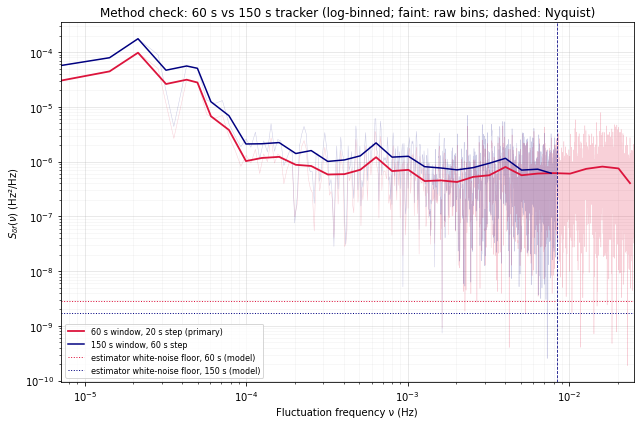

In [15]:
t_150, f_150 = T[mref], FR[mref]
d_150 = f_150 - f_150.mean()
fs_150 = 1/np.median(np.diff(t_150))
nu_150, S_150 = periodogram(d_150, fs=fs_150, window='hann', detrend=False)
nu_150_lb, S_150_lb, _ = log_bin(nu_150, S_150)

def sim_scatter(win, f_opt, snr_target, n=300, seed=1):
    """std (rotor Hz) of the interpolated estimate for a pure tone + white noise at snr_target."""
    nw_ = int(win*fs16); tt_ = np.arange(nw_)/fs16; rng_ = np.random.default_rng(seed)
    def run(sig, k):
        out = np.array([peak_in_band(np.sin(2*np.pi*f_opt*tt_ + p) + sig*rng_.standard_normal(nw_),
                                     fs16, f_opt*0.85, f_opt*1.10)[1:] for p in rng_.uniform(0, 2*np.pi, k)])
        return out[:, 0].std(), np.median(out[:, 1])
    _, snr0 = run(0.03, 50)
    return run(0.03*snr0/snr_target, n)[0]/DIVISOR

snr_60 = np.median(SNR_60[m60])
sd_60 = sim_scatter(WIN_P, f0*DIVISOR, snr_60)
floor_60, floor_150 = 2*sd_60**2/fs_p, 2*sd_noise**2/fs_150   # one-sided white level, Hz²/Hz

dfo_60 = fs16/int(WIN_P*fs16)
off_60 = ((f_p - R_60[m60])/(dfo_60/DIVISOR)).mean()
g_60 = np.interp(np.interp(off_60, d_true + bias, d_true), d_true, gain)
g_150 = np.interp(np.interp(dAB.mean()/DF_ROT, d_true + bias, d_true), d_true, gain)
band = lambda nu, lo, hi: (nu >= lo) & (nu <= hi)

print(f'60 s: {len(f_p)} estimates, bin df_rotor = {dfo_60/DIVISOR*1e3:.2f} mHz, median SNR {snr_60:.0f}; '
      f'150 s: {len(f_150)} estimates, median SNR {np.median(SNR[mref]):.0f}')
print(f'  mean {f0:.6f} Hz (150 s: {f_150.mean():.6f}),  std δf {delta_f.std()*1e3:.4f} mHz (150 s: {d_150.std()*1e3:.4f})')
print(f'  estimator white-noise floor (model): 60 s {floor_60:.2e}, 150 s {floor_150:.2e} Hz²/Hz '
      f'(scatter {sd_60*1e3:.4f} vs {sd_noise*1e3:.4f} mHz)')
print(f'  interpolation: sub-bin offset {off_60:+.3f} bin, gain {g_60:.2f} (150 s: {g_150:.2f}) '
      f'-> expected PSD ratio from gain alone {(g_60/g_150)**2:.2f}')
for lo, hi, lab in ((nu_p[1], 1/3600, 'hour-scale, ν ≤ 1/3600 s'), (1e-3, 6e-3, '1-6 mHz')):
    r = S_df[band(nu_p, lo, hi)].mean()/S_150[band(nu_150, lo, hi)].mean()
    print(f'  band-mean PSD ratio 60 s / 150 s, {lab}: {r:.2f}')
b = band(nu_p, 10e-3, 25e-3)
print(f'  10-25 mHz: mean S = {S_df[b].mean():.2e} Hz²/Hz = {S_df[b].mean()/floor_60:.0f}x the 60 s floor')

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(nu_p[1:], S_df[1:], color='crimson', lw=0.5, alpha=0.2)
ax.loglog(nu_150[1:], S_150[1:], color='navy', lw=0.5, alpha=0.2)
ax.loglog(nu_lb, S_lb, color='crimson', lw=1.8, label=f'{WIN_P:.0f} s window, {STEP_P:.0f} s step (primary)')
ax.loglog(nu_150_lb, S_150_lb, color='navy', lw=1.5, label='150 s window, 60 s step')
ax.axhline(floor_60, color='crimson', ls=':', lw=1, label='estimator white-noise floor, 60 s (model)')
ax.axhline(floor_150, color='navy', ls=':', lw=1, label='estimator white-noise floor, 150 s (model)')
for x, c in ((fs_150/2, 'navy'), (fs_p/2, 'crimson')): ax.axvline(x, color=c, ls='--', lw=0.8)
ax.set_xlim(nu_p[1], fs_p/2)
ax.set_xlabel('Fluctuation frequency ν (Hz)'); ax.set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title('Method check: 60 s vs 150 s tracker (log-binned; faint: raw bins; dashed: Nyquist)')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**(a) result.**
- Same shape from 7 µHz to 8 mHz, including the red component below ~60 µHz.
- **Different level, from the estimator.** Band-mean ratio 60 s / 150 s: 0.60 at hour scales, 0.67 at
  1–6 mHz. The pure-tone interpolation gains (0.79 at 60 s, line near a bin centre; 1.07 at 150 s)
  predict 0.55. Against the true wander, that model puts the 60 s PSD at ~0.6× and the 150 s at
  ~1.1×. **Not corrected.**
- 10–25 mHz (60 s only): mean 7e-7 Hz²/Hz, ~250× the modelled 60 s floor; rolls off towards 25 mHz
  where the 60 s window smooths the track.
- The floors model white noise only; non-white effects are not covered.

**(b) Full-record periodogram vs Welch with 4.27 h segments** (the previous estimate), on the primary
60 s series. A 4.27 h segment can't resolve anything slower than ~65 µHz, so slower wander has nowhere
to go but its lowest bins.

Welch: nperseg 768 (4.27 h), lowest ν 6.51e-05 Hz; periodogram lowest ν 7.12e-06 Hz
  ν (µHz) |     Welch | periodogram (nearest bin) | ratio
     65.1 |  1.99e-05 |        6.22e-06 ( 64.1 µHz) |   3.2
    130.2 |  3.00e-06 |        1.38e-06 (128.2 µHz) |   2.2
    195.3 |  9.30e-07 |        9.06e-07 (192.3 µHz) |   1.0
1-2 mHz mean: Welch 5.41e-07, periodogram 5.10e-07, ratio 1.06
3-6 mHz mean: Welch 5.36e-07, periodogram 6.32e-07, ratio 0.85
10-25 mHz mean: Welch 6.93e-07, periodogram 7.00e-07, ratio 0.99
periodogram below Welch's lowest bin (9 bins, 7.1-64.1 µHz): mean 3.31e-05 Hz²/Hz, 56x the 1-6 mHz level


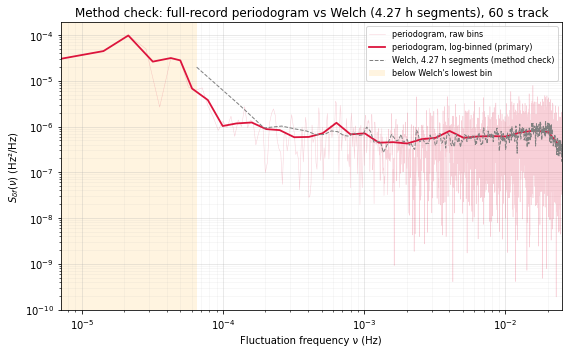

In [16]:
NPS_P = int(round(NPS_NU*STEP*fs_p))                    # 4.27 h segment at the 20 s cadence
nu_pw, S_pw = welch(delta_f, fs=fs_p, nperseg=NPS_P, detrend=False)
print(f'Welch: nperseg {NPS_P} ({NPS_P/fs_p/3600:.2f} h), lowest ν {nu_pw[1]:.2e} Hz; periodogram lowest ν {nu_p[1]:.2e} Hz')
print(f"{'ν (µHz)':>9} | {'Welch':>9} | {'periodogram (nearest bin)':>25} | ratio")
for v, s in zip(nu_pw[1:4], S_pw[1:4]):
    j = np.argmin(abs(nu_p - v))
    print(f'{v*1e6:9.1f} | {s:9.2e} | {S_df[j]:15.2e} ({nu_p[j]*1e6:5.1f} µHz) | {s/S_df[j]:5.1f}')
for lo, hi in ((1e-3, 2e-3), (3e-3, 6e-3), (10e-3, 25e-3)):
    x = S_pw[band(nu_pw, lo, hi)].mean(); y = S_df[band(nu_p, lo, hi)].mean()
    print(f'{lo*1e3:.0f}-{hi*1e3:.0f} mHz mean: Welch {x:.2e}, periodogram {y:.2e}, ratio {x/y:.2f}')
below = (nu_p > 0) & (nu_p < nu_pw[1])
print(f"periodogram below Welch's lowest bin ({below.sum()} bins, {nu_p[below][0]*1e6:.1f}-{nu_p[below][-1]*1e6:.1f} µHz): "
      f'mean {S_df[below].mean():.2e} Hz²/Hz, {S_df[below].mean()/S_df[band(nu_p, 1e-3, 6e-3)].mean():.0f}x the 1-6 mHz level')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(nu_p[1:], S_df[1:], color='crimson', lw=0.5, alpha=0.2, label='periodogram, raw bins')
ax.loglog(nu_lb, S_lb, color='crimson', lw=1.8, label='periodogram, log-binned (primary)')
ax.loglog(nu_pw[1:], S_pw[1:], color='gray', lw=1.0, ls='--', label='Welch, 4.27 h segments (method check)')
ax.axvspan(nu_p[1], nu_pw[1], color='orange', alpha=0.12, lw=0, label="below Welch's lowest bin")
ax.set_xlim(nu_p[1], fs_p/2)
ax.set_xlabel('Fluctuation frequency ν (Hz)'); ax.set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title('Method check: full-record periodogram vs Welch (4.27 h segments), 60 s track')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**(b) result** (as on the 150 s series):
- Welch's lowest bins are high, 3.2× at 65 µHz and 2.2× at 130 µHz: power from slower wander piles
  into them. That was the rise at the left edge of the old curve.
- Elsewhere the two agree (ratio 0.85–1.06, 1–25 mHz).
- Below 65 µHz (9 bins, 7–64 µHz) the periodogram averages 3.3e-5 Hz²/Hz, ~56× the 1–6 mHz level:
  the red component, resolved only by the full record.

**(c) 30 s window, 10 s step** (Nyquist 50 mHz), same full-record periodogram and log-binning as §1.5,
band centred on the 150 s track. Log-binned 60 s / 20 s primary overlaid for reference. A 30 s window
has 16.7 mHz rotor bins, more per-point scatter, and smooths the track above ~1/30 s ≈ 33 mHz.

30 s window, 10 s step: 14041 estimates, 39.00 h, bin df_rotor = 16.7 mHz, median SNR 467 (60 s: 552)
  mean 0.749151 Hz (60 s: 0.749140),  std δf 0.1773 mHz (60 s: 0.1396)
  resolution 7.122e-06 Hz, Nyquist 5.000e-02 Hz
  estimator white-noise floor (model): 7.33e-09 Hz²/Hz (scatter 0.0191 mHz; 60 s: 2.82e-09)
  interpolation: sub-bin offset -0.051 bin, gain 0.76 (60 s: 0.79) -> expected PSD ratio 30 s / 60 s from gain alone 0.92
  band-mean PSD ratio 30 s / 60 s, hour-scale, ν ≤ 1/3600 s: 0.86
  band-mean PSD ratio 30 s / 60 s, 1-6 mHz: 0.96
  band-mean PSD ratio 30 s / 60 s, 10-25 mHz: 1.85
  25-50 mHz (30 s only): mean S = 1.25e-07 Hz²/Hz = 17x the 30 s floor


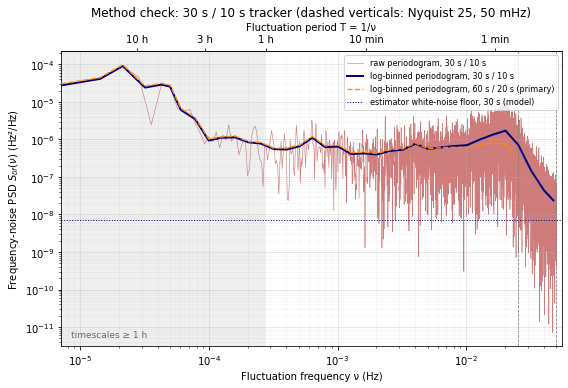

In [17]:
WIN_V, STEP_V = 30.0, 10.0
T_30, R_30, F_30, SNR_30 = track_rotor(WIN_V, step=STEP_V, guide=True)
m30 = ((T_30 - T_REF)/3600 >= WIN_H[0]) & ((T_30 - T_REF)/3600 <= WIN_H[1])
t_30, f_30 = T_30[m30], F_30[m30]
assert abs(f_30.mean() - f0) < 1e-3, '30 s track is not on the 1.498 Hz line'
assert np.allclose(np.diff(t_30), STEP_V), 'uneven cadence'
fs_30 = 1/np.median(np.diff(t_30))
d_30 = f_30 - f_30.mean()
nu_30, S_30 = periodogram(d_30, fs=fs_30, window='hann', detrend=False)
nu_30_lb, S_30_lb, _ = log_bin(nu_30, S_30)

snr_30 = np.median(SNR_30[m30])
sd_30 = sim_scatter(WIN_V, f_30.mean()*DIVISOR, snr_30)
floor_30 = 2*sd_30**2/fs_30
dfo_30 = fs16/int(WIN_V*fs16)
off_30 = ((f_30 - R_30[m30])/(dfo_30/DIVISOR)).mean()
g_30 = np.interp(np.interp(off_30, d_true + bias, d_true), d_true, gain)

print(f'{WIN_V:.0f} s window, {STEP_V:.0f} s step: {len(f_30)} estimates, {len(d_30)/fs_30/3600:.2f} h, '
      f'bin df_rotor = {dfo_30/DIVISOR*1e3:.1f} mHz, median SNR {snr_30:.0f} (60 s: {snr_60:.0f})')
print(f'  mean {f_30.mean():.6f} Hz (60 s: {f0:.6f}),  std δf {d_30.std()*1e3:.4f} mHz (60 s: {delta_f.std()*1e3:.4f})')
print(f'  resolution {nu_30[1]:.3e} Hz, Nyquist {fs_30/2:.3e} Hz')
print(f'  estimator white-noise floor (model): {floor_30:.2e} Hz²/Hz (scatter {sd_30*1e3:.4f} mHz; 60 s: {floor_60:.2e})')
print(f'  interpolation: sub-bin offset {off_30:+.3f} bin, gain {g_30:.2f} (60 s: {g_60:.2f}) '
      f'-> expected PSD ratio 30 s / 60 s from gain alone {(g_30/g_60)**2:.2f}')
for lo, hi, lab in ((nu_p[1], 1/3600, 'hour-scale, ν ≤ 1/3600 s'), (1e-3, 6e-3, '1-6 mHz'), (10e-3, 25e-3, '10-25 mHz')):
    r = S_30[band(nu_30, lo, hi)].mean()/S_df[band(nu_p, lo, hi)].mean()
    print(f'  band-mean PSD ratio 30 s / 60 s, {lab}: {r:.2f}')
b = band(nu_30, 25e-3, 50e-3)
print(f'  25-50 mHz (30 s only): mean S = {S_30[b].mean():.2e} Hz²/Hz = {S_30[b].mean()/floor_30:.0f}x the 30 s floor')

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_30[1:], S_30[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1, label='raw periodogram, 30 s / 10 s')
ax.loglog(nu_30_lb, S_30_lb, color='navy', lw=2.0, zorder=3, label='log-binned periodogram, 30 s / 10 s')
ax.loglog(nu_lb, S_lb, color='darkorange', lw=1.4, ls='--', zorder=4, label='log-binned periodogram, 60 s / 20 s (primary)')
ax.axhline(floor_30, color='navy', ls=':', lw=1, label='estimator white-noise floor, 30 s (model)')
for x in (fs_p/2, fs_30/2): ax.axvline(x, color='gray', lw=0.8, ls='--')
ax.set_xlim(nu_30[1], fs_30/2*1.1)
ax.axvspan(nu_30[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Frequency-noise PSD $S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title('Method check: 30 s / 10 s tracker (dashed verticals: Nyquist 25, 50 mHz)')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8, loc='upper right')
top = ax.secondary_xaxis('top', functions=(inv, inv))
per = [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (3*3600, '3 h'), (10*3600, '10 h')]
top.set_xticks([p for p, _ in per]); top.set_xticklabels([l for _, l in per])
top.xaxis.set_minor_locator(plt.NullLocator()); top.set_xlabel('Fluctuation period T = 1/ν')
plt.tight_layout(); plt.show()

**(c) result**, as observations:
- **7 µHz – 6 mHz: 30 s and 60 s agree.** Band-mean ratio 30 s / 60 s is 0.86 at hour scales and 0.96
  at 1–6 mHz; the interpolation gains (0.76 vs 0.79) predict 0.92.
- **10–25 mHz: the 30 s track shows 1.85× more power.** Its log-binned curve rises to ~2e-6 Hz²/Hz
  near ~20 mHz (periods ~50 s), where the 60 s curve is already falling. The 60 s window smooths the
  track from ~1/60 s ≈ 17 mHz, so **the primary under-reports this band** by roughly that factor. The
  rise is ~300× the modelled 30 s white-noise floor. Not interpreted.
- **Above ~25 mHz** the 30 s curve falls steeply (to ~2e-8 at 50 mHz), its own window smoothing from
  ~1/30 s ≈ 33 mHz. 25–50 mHz mean: 1.3e-7 Hz²/Hz, 17× the modelled floor.
- So the §1.5 primary is robust to the window below ~6–10 mHz; above that, its level depends on WIN.

**(d) Final-PSD window: Hann vs rectangular**, on the same 60 s / 20 s δf series (1–40 h). Only the ~39 h
periodogram's window changes; the Hann window inside the 60 s tracking FFT is untouched. Both: mean
subtracted, `detrend=False`, one-sided density (Hz²/Hz). R(ν) = S_rect/S_Hann.

bin |  ν (µHz) |    S_Hann |    S_rect | R = rect/Hann
  1 |     7.12 |  3.02e-05 |  6.64e-05 |   2.20
  2 |    14.25 |  4.46e-05 |  1.21e-05 |   0.27
  3 |    21.37 |  9.78e-05 |  1.50e-04 |   1.54
  4 |    28.49 |  4.98e-05 |  4.87e-05 |   0.98
  5 |    35.61 |  2.67e-06 |  4.35e-06 |   1.63
  6 |    42.74 |  3.14e-05 |  4.74e-05 |   1.51
  7 |    49.86 |  2.79e-05 |  3.61e-05 |   1.29
  8 |    56.98 |  7.27e-06 |  1.42e-06 |   0.20

      band (Hz) |  bins | ratio of band means | median R |       R range
1e-05-1.0e-04 |    13 |                1.18 |     1.51 |  0.20 -  6.35
1e-04-1.0e-03 |   126 |                1.08 |     1.00 |  0.01 - 25.61
1e-03-1.0e-02 |  1264 |                0.97 |     1.00 |  0.00 - 104.81
1e-02-2.5e-02 |  2107 |                1.02 |     1.04 |  0.00 - 866.04


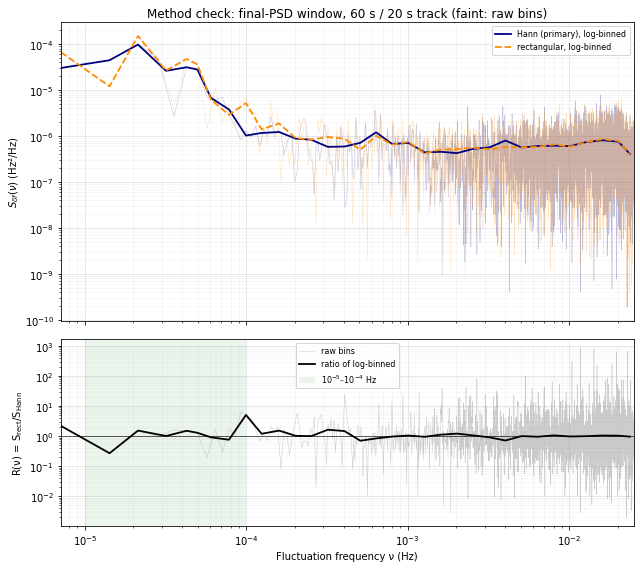

In [18]:
_, S_df_rect = periodogram(delta_f, fs=fs_p, window='boxcar', detrend=False)   # same series, no taper
R_win = S_df_rect/np.where(S_df > 0, S_df, np.nan)
_, S_lb_rect, _ = log_bin(nu_p, S_df_rect)                # same log bins as S_lb (same ν grid)

print(f"{'bin':>3} | {'ν (µHz)':>8} | {'S_Hann':>9} | {'S_rect':>9} | R = rect/Hann")
for j in range(1, 9):
    print(f'{j:3d} | {nu_p[j]*1e6:8.2f} | {S_df[j]:9.2e} | {S_df_rect[j]:9.2e} | {R_win[j]:6.2f}')
print(f"\n{'band (Hz)':>15} | {'bins':>5} | {'ratio of band means':>19} | {'median R':>8} | {'R range':>13}")
for lo, hi in ((1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2), (1e-2, fs_p/2)):
    b = band(nu_p, lo, hi)
    print(f'{lo:.0e}-{hi:.1e} | {b.sum():5d} | {S_df_rect[b].mean()/S_df[b].mean():19.2f} | '
          f'{np.median(R_win[b]):8.2f} | {R_win[b].min():5.2f} - {R_win[b].max():5.2f}')

fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1]))
ax[0].loglog(nu_p[1:], S_df[1:], color='navy', lw=0.5, alpha=0.25)
ax[0].loglog(nu_p[1:], S_df_rect[1:], color='darkorange', lw=0.5, alpha=0.25)
ax[0].loglog(nu_lb, S_lb, color='navy', lw=1.8, label='Hann (primary), log-binned')
ax[0].loglog(nu_lb, S_lb_rect, color='darkorange', lw=1.8, ls='--', label='rectangular, log-binned')
ax[0].set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)'); ax[0].legend(fontsize=8)
ax[0].set_title('Method check: final-PSD window, 60 s / 20 s track (faint: raw bins)')
ax[1].loglog(nu_p[1:], R_win[1:], color='gray', lw=0.5, alpha=0.4, label='raw bins')
ax[1].loglog(nu_lb, S_lb_rect/S_lb, color='k', lw=1.8, label='ratio of log-binned')
ax[1].axhline(1, color='k', lw=0.6)
ax[1].axvspan(1e-5, 1e-4, color='green', alpha=0.08, lw=0, label='10$^{-5}$–10$^{-4}$ Hz')
ax[1].set_ylabel('R(ν) = S$_{\\rm rect}$/S$_{\\rm Hann}$'); ax[1].set_xlabel('Fluctuation frequency ν (Hz)')
ax[1].legend(fontsize=8)
for a in ax: a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12); a.set_xlim(nu_p[1], fs_p/2)
plt.tight_layout(); plt.show()

**(d) result:**
- **Band-averaged level: little window dependence.** Ratio of band means, rectangular / Hann: 1.18
  (10–100 µHz), 1.08 (0.1–1 mHz), 0.97 (1–10 mHz), 1.02 (10–25 mHz). The log-binned curves overlap
  closely across the whole range.
- **Individual bins: large differences.** In the first 8 bins R ranges 0.20–2.20 (10–100 µHz: median
  1.51, range 0.20–6.35). Each bin is a single estimate, and the window redistributes power between
  neighbouring bins, so per-bin comparisons at the lowest ν depend on the window.
- No serious window dependence at the band level, so Hann stays the primary measured PSD.

**(e) Tracker window length, 60–1200 s: is the sub-bin structure physical?** Diagnostic only.

Same algorithm as the primary tracker for every T_w (segment mean removed, Hann taper, FFT, peak in the
0.85–1.10× band, three-point parabolic interpolation, ÷2). Step 20 s for all, so consecutive estimates
overlap heavily and are **not independent**. The band is centred on the 150 s track, as for the primary
(self-tracking long windows lock onto rotation harmonics during spin-up, §1.4). The 60 s run must equal
the primary series exactly.

A Hann-windowed FFT peak reports a *weighted* average of the instantaneous frequency. For small
frequency modulation the weight is the phase-slope kernel $K(t) \propto \int_t^{T_w/2} w(s)\,s\,ds$ (w = Hann),
a bump narrower than T_w. Comparing a T_w trace with the 60 s trace therefore uses the 60 s trace
convolved with that tracker's K, never raw point-by-point scatter.

In [19]:
TW_LIST = (60, 150, 300, 600, 1200)
STEP_E = 20.0
DATA_FP = (GPS_A, GPS_B, len(y16), round(float(y16[::997].sum()), 6), WIN_H)   # identifies the input data in cache keys

def _e_tracks():
    out = {}
    for w in TW_LIST:
        Tw_, Rw_, Fw_, Sw_ = track_rotor(w, step=STEP_E, guide=True)
        m = ((Tw_ - T_REF)/3600 >= WIN_H[0]) & ((Tw_ - T_REF)/3600 <= WIN_H[1])
        out[w] = dict(t=Tw_[m], raw=Rw_[m], f=Fw_[m], snr=np.median(Sw_[m]), d=Fw_[m] - Fw_[m].mean())
    return out
TRK_E = cached('e_tracks', ('v1', DATA_FP, TW_LIST, STEP_E), _e_tracks)
assert np.array_equal(TRK_E[60]['f'], f_p) and np.array_equal(TRK_E[60]['t'], t_p), '60 s run != primary'

# consistency: the 150 s run (20 s step, guided) vs the original self-tracking 150 s FR (60 s step), shared windows
c150 = np.isin(np.round(TRK_E[150]['t'], 6), np.round(T[mref], 6))
print(f'150 s guided vs original FR on {c150.sum()} shared windows: max |diff| = '
      f'{np.abs(TRK_E[150]["f"][c150] - FR[mref][np.isin(np.round(T[mref], 6), np.round(TRK_E[150]["t"], 6))]).max():.1e} Hz')

print(f"\n{'T_w':>6} | {'FFT-bin spacing 1/(2T_w)':>24} | {'N':>5} | {'mean f (Hz)':>11} | {'std δf (mHz)':>12} | {'median SNR':>10}")
for w in TW_LIST:
    e = TRK_E[w]
    print(f'{w:4d} s | {1/(2*w)*1e3:20.3f} mHz | {len(e["f"]):5d} | {e["f"].mean():11.6f} | {e["d"].std()*1e3:12.4f} | {e["snr"]:10.0f}')
print('(FFT-bin spacing is the raw-bin quantisation step, not the uncertainty of the interpolated estimate.)')

[cache] e_tracks: loaded
150 s guided vs original FR on 2341 shared windows: max |diff| = 0.0e+00 Hz

   T_w | FFT-bin spacing 1/(2T_w) |     N | mean f (Hz) | std δf (mHz) | median SNR
  60 s |                8.333 mHz |  7020 |    0.749140 |       0.1396 |        552
 150 s |                3.333 mHz |  7021 |    0.749045 |       0.1117 |        549
 300 s |                1.667 mHz |  7020 |    0.748793 |       0.0892 |        522
 600 s |                0.833 mHz |  7020 |    0.748910 |       0.0936 |        458
1200 s |                0.417 mHz |  7020 |    0.748863 |       0.0736 |        266
(FFT-bin spacing is the raw-bin quantisation step, not the uncertainty of the interpolated estimate.)


   T_w | vs 60 s smoothed with K_Tw: corr | rms diff (mHz) | 1 h means: corr | rms diff (mHz) | std 1 h mean (mHz)
 150 s |                            0.949 |         0.0427 |           0.997 |         0.0204 |             0.0726
 300 s |                            0.990 |         0.0241 |           0.996 |         0.0156 |             0.0675
 600 s |                            0.994 |         0.0327 |           0.995 |         0.0280 |             0.0800
1200 s |                            0.986 |         0.0190 |           0.989 |         0.0157 |             0.0658
  60 s |                                  |                |                 |                |             0.0527


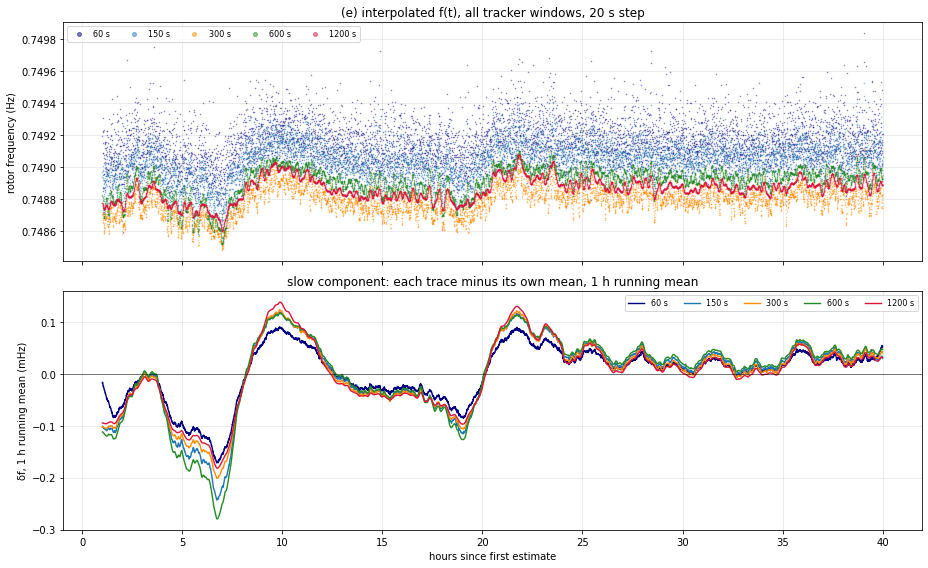

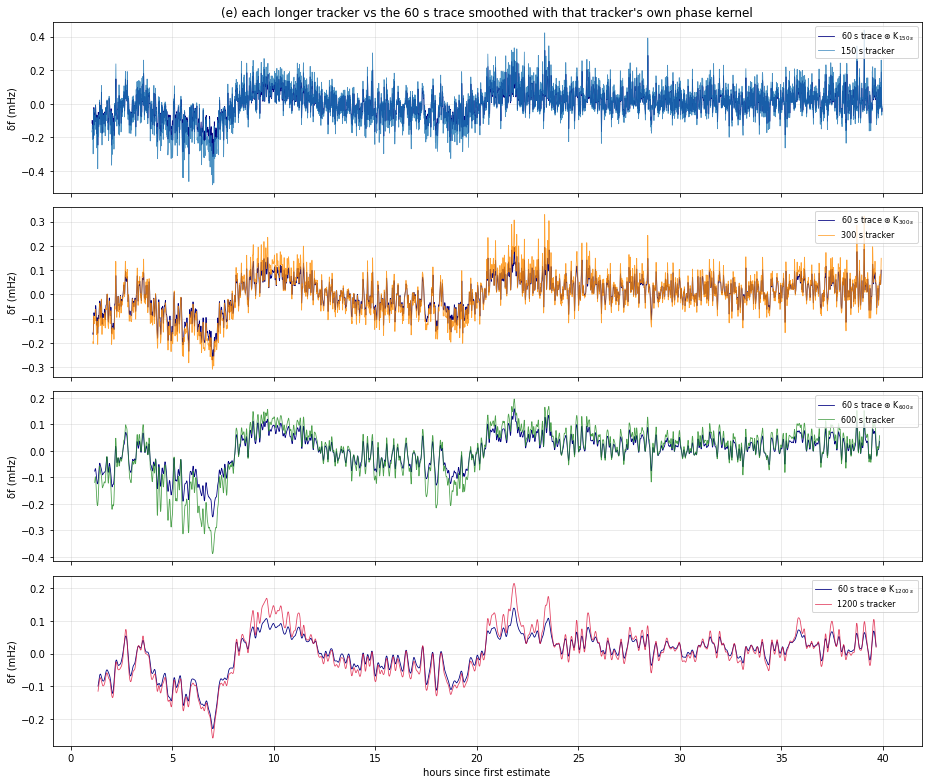

In [20]:
def phase_kernel(win, dt):
    """Weight of the instantaneous frequency in a Hann-windowed FFT-peak estimate (small-FM limit),
    sampled every dt over [-win/2, win/2]; normalised to sum 1."""
    s = np.linspace(-win/2, win/2, 4001); wv = np.cos(np.pi*s/win)**2
    G = np.cumsum((wv*s)[::-1])[::-1]*(s[1] - s[0])        # ∫_s^{T/2} w(u) u du for s >= 0 (mirrors for s < 0)
    Kf = np.interp(np.abs(s), s[s >= 0], G[s >= 0])
    tk = np.arange(-win/2, win/2 + dt/2, dt)
    K = np.interp(tk, s, Kf); return K/K.sum()

t60, d60 = TRK_E[60]['t'], TRK_E[60]['d']
N_SLOW = int(round(3600/STEP_E))                          # 1 h running mean = "slow component"
slow60 = uniform_filter1d(d60, N_SLOW, mode='nearest')
print(f"{'T_w':>6} | {'vs 60 s smoothed with K_Tw: corr':>32} | {'rms diff (mHz)':>14} | {'1 h means: corr':>15} | {'rms diff (mHz)':>14} | {'std 1 h mean (mHz)':>18}")
CMP_E = {}
for w in TW_LIST[1:]:
    e = TRK_E[w]
    dw = np.interp(t60, e['t'], e['d'])                     # T_w trace on the 60 s timestamps
    ok = (t60 >= e['t'][0]) & (t60 <= e['t'][-1])
    sm60 = np.convolve(d60, phase_kernel(w, STEP_E), mode='same')
    edge = int(w/STEP_E)                                    # drop convolution edges
    ok &= (np.arange(len(t60)) >= edge) & (np.arange(len(t60)) < len(t60) - edge)
    a, b = dw[ok] - dw[ok].mean(), sm60[ok] - sm60[ok].mean()
    sw = uniform_filter1d(dw, N_SLOW, mode='nearest')
    CMP_E[w] = dict(dw=dw, sm60=sm60, ok=ok, slow=sw)
    print(f'{w:4d} s | {np.corrcoef(a, b)[0, 1]:32.3f} | {np.sqrt(np.mean((a - b)**2))*1e3:14.4f} | '
          f'{np.corrcoef(sw[ok], slow60[ok])[0, 1]:15.3f} | {np.sqrt(np.mean((sw[ok] - slow60[ok])**2))*1e3:14.4f} | {sw[ok].std()*1e3:18.4f}')
print(f'{"60 s":>6} | {"":>32} | {"":>14} | {"":>15} | {"":>14} | {slow60.std()*1e3:18.4f}')

cols = dict(zip(TW_LIST, ('navy', 'tab:blue', 'darkorange', 'forestgreen', 'crimson')))
hh = (t60 - T_REF)/3600
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for w in TW_LIST:
    e = TRK_E[w]
    ax[0].plot((e['t'] - T_REF)/3600, e['f'], '.', ms=1, color=cols[w], alpha=0.5, label=f'{w} s')
    ax[1].plot(hh, uniform_filter1d(np.interp(t60, e['t'], e['d']), N_SLOW, mode='nearest')*1e3, color=cols[w], lw=1.4, label=f'{w} s')
ax[0].set_ylabel('rotor frequency (Hz)'); ax[0].legend(markerscale=8, fontsize=8, ncol=5)
ax[0].set_title('(e) interpolated f(t), all tracker windows, 20 s step')
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_ylabel('δf, 1 h running mean (mHz)'); ax[1].legend(fontsize=8, ncol=5)
ax[1].set_xlabel('hours since first estimate'); ax[1].set_title('slow component: each trace minus its own mean, 1 h running mean')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(len(TW_LIST) - 1, 1, figsize=(13, 11), sharex=True)
for a, w in zip(ax, TW_LIST[1:]):
    c = CMP_E[w]
    a.plot(hh[c['ok']], c['sm60'][c['ok']]*1e3, color='navy', lw=0.8, label=f'60 s trace ⊛ K$_{{{w}\\,s}}$')
    a.plot(hh[c['ok']], c['dw'][c['ok']]*1e3, color=cols[w], lw=0.8, alpha=0.8, label=f'{w} s tracker')
    a.set_ylabel('δf (mHz)'); a.legend(fontsize=8, loc='upper right'); a.grid(alpha=.3)
ax[0].set_title('(e) each longer tracker vs the 60 s trace smoothed with that tracker\'s own phase kernel')
ax[-1].set_xlabel('hours since first estimate')
plt.tight_layout(); plt.show()

   T_w | FFT-bin spacing | observed std δf | synthetic estimator σ | observed / estimator
[cache] e_sigma: loaded
  60 s |       8.333 mHz |      0.1396 mHz |           0.00840 mHz |                   17
 150 s |       3.333 mHz |      0.1117 mHz |           0.00342 mHz |                   33
 300 s |       1.667 mHz |      0.0892 mHz |           0.00195 mHz |                   46
 600 s |       0.833 mHz |      0.0936 mHz |           0.00105 mHz |                   89
1200 s |       0.417 mHz |      0.0736 mHz |           0.00087 mHz |                   85
(synthetic: same peak_in_band, Hann taper, band and interpolation; 300 realisations, random phase;
 white noise scaled so the median SNR matches the measured median SNR of that tracker)


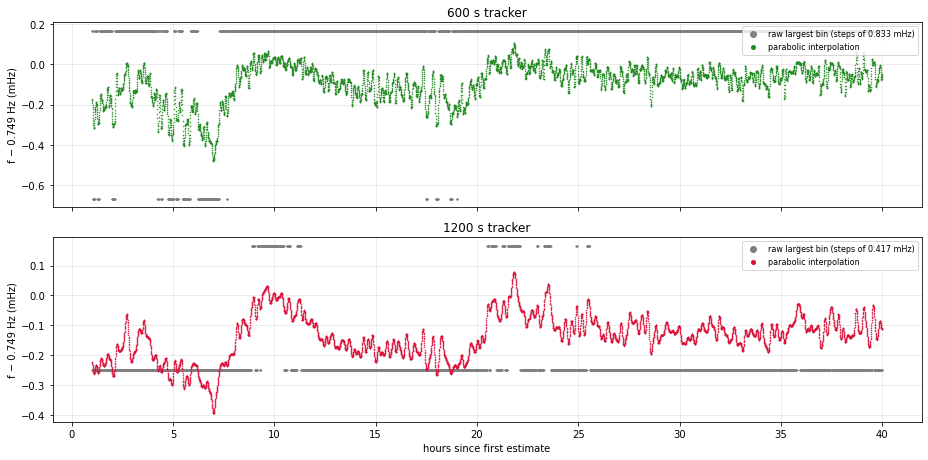

In [21]:
# stationary-tone estimator test at each T_w: pure tone at the observed line + white noise at that tracker's median SNR
print(f"{'T_w':>6} | {'FFT-bin spacing':>15} | {'observed std δf':>15} | {'synthetic estimator σ':>21} | {'observed / estimator':>20}")
SIG_E = cached('e_sigma', ('v1', DATA_FP, TW_LIST),
               lambda: {w: sim_scatter(w, TRK_E[w]['f'].mean()*DIVISOR, TRK_E[w]['snr']) for w in TW_LIST})
for w in TW_LIST:
    e = TRK_E[w]
    print(f'{w:4d} s | {1/(2*w)*1e3:11.3f} mHz | {e["d"].std()*1e3:11.4f} mHz | {SIG_E[w]*1e3:17.5f} mHz | {e["d"].std()/SIG_E[w]:20.0f}')
print('(synthetic: same peak_in_band, Hann taper, band and interpolation; 300 realisations, random phase;\n'
      ' white noise scaled so the median SNR matches the measured median SNR of that tracker)')

# raw largest-bin estimate vs interpolated, for the two longest windows
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for a, w in zip(ax, (600, 1200)):
    e = TRK_E[w]; h = (e['t'] - T_REF)/3600
    a.plot(h, e['raw']*1e3 - 749, '.', ms=1.5, color='gray', label=f'raw largest bin (steps of {1/(2*w)*1e3:.3f} mHz)')
    a.plot(h, e['f']*1e3 - 749, '.', ms=1, color=cols[w], label='parabolic interpolation')
    a.set_ylabel('f − 0.749 Hz (mHz)'); a.legend(fontsize=8, markerscale=8, loc='upper right'); a.grid(alpha=.3)
    a.set_title(f'{w} s tracker')
ax[-1].set_xlabel('hours since first estimate')
plt.tight_layout(); plt.show()

**(e) result:**
1. **The broad evolution persists across a 20× range of window length** (bin spacing 8.3 → 0.42 mHz).
   1 h running means correlate with the 60 s trace at 0.989–0.997, with rms differences of 0.016–0.028 mHz
   against 0.05–0.08 mHz of structure. The 5–7 h dip, the ~10 h rise, the 19 h dip and the 21–23 h step
   appear in every trace. Amplitudes differ between trackers (std of the 1 h means: 0.053 mHz at 60 s,
   0.066–0.080 mHz for 150–1200 s); the deepest point of the 5–7 h dip is the largest disagreement.
   Whether this is estimator gain is tested directly in §1.6(f).
2. **Measured variation ≫ stationary-tone estimator scatter at every T_w:** observed/estimator = 17 (60 s),
   33, 46, 89, 85 (1200 s). Model caveat: pure tone + white noise at matched SNR.
3. **What disappears with T_w is what the averaging predicts.** Std of δf falls from 0.140 mHz (60 s) to
   0.074 mHz (1200 s). Each longer trace matches the 60 s trace convolved with that tracker's phase kernel
   (corr 0.949 / 0.990 / 0.994 / 0.986 for 150 / 300 / 600 / 1200 s; rms 0.019–0.043 mHz). The longer
   trackers see what the 60 s trace predicts after smoothing.
4. **No sign that the structure is generated by the interpolation:**
   - it reproduces with the line at different sub-bin positions for each T_w; an interpolation artefact
     would depend on that position;
   - **the raw largest-bin estimate, which uses no interpolation, follows the same structure** wherever the
     wander reaches a bin edge. At 600 s it drops one bin during the 1–8 h and ~17–19 h dips. At 1200 s
     it steps up one bin during the ~9–11 h and ~21–23 h highs.
   Estimator-dependent: the absolute mean (0.748793–0.749140 Hz across T_w, the constant interpolation
   bias). The amplitude differences between trackers are measured in §1.6(f), not assumed.

**(f) Injected frequency-modulation transfer function.** Validation only.

Synthetic optical signal at 16 Hz: a pure tone at $2f_{\rm rotor}(t)$ with
$f_{\rm rotor}(t) = f_0 + A_{\rm inj}\sin(2\pi\nu_m t)$ (phase integrated exactly), plus white noise scaled per
tracker so its median SNR matches the measured one (as in (e)). f0 = the 1200 s tracker's mean (smallest
bin, so smallest absolute interpolation bias). Tracked with the same `peak_in_band` (mean removal, Hann,
FFT, 0.85–1.10× band, parabolic interpolation, ÷2), 20 s step, band centred on the injected optical
frequency (the synthetic counterpart of guiding on the 150 s track). A sinusoid at the known ν_m plus a
constant is fitted to the tracked series: $G = A_{\rm rec}/A_{\rm inj}$, φ = phase relative to the injection.

Record length per ν_m: max(4/ν_m, 2 h), capped at 100 h, so the lowest ν_m tested (10⁻⁵ Hz) has ≥ 3.6
cycles. **Below 10⁻⁵ Hz nothing is measured.** For ν_m·T_w ≪ 1 the response is quasi-static, so lower
ν_m are expected to sit on the same plateau, but that is an expectation, not a measurement.

**Model (dashed):** static pure-tone gain at the carrier's sub-bin position (§1.3 curve) × the response
$\hat K_{T_w}(\nu)=\sum_t K(t)\cos 2\pi\nu t$ of the phase kernel from (e). This is a first-order model, to
compare with the measurement, not a substitute for it.

In [22]:
import time
F0_SIM = TRK_E[1200]['f'].mean()                         # rotor Hz
A_MAIN = 0.1e-3                                           # Hz (rotor), main-sweep amplitude
NU_LIST = np.unique(np.r_[np.logspace(-5, np.log10(2e-2), 17), 3.32e-5, 1e-4, 1/3600])
T_SIM_MAX = 100*3600
t_sim = lambda nu: min(max(4/nu, 2*3600), T_SIM_MAX)
rng_f = np.random.default_rng(7)

def sigma_for(win, f_opt, snr_target, n=40):
    """white-noise std (per 16 Hz sample, unit-amplitude tone) giving the target median SNR"""
    nw_ = int(win*fs16); tt_ = np.arange(nw_)/fs16
    snr0 = np.median([peak_in_band(np.sin(2*np.pi*f_opt*tt_ + p) + 0.03*rng_f.standard_normal(nw_), fs16,
                                   f_opt*0.85, f_opt*1.10)[2] for p in rng_f.uniform(0, 2*np.pi, n)])
    return 0.03*snr0/snr_target

def synth(T_s, f0, dphi, sigma):
    """unit tone at DIVISOR*(f0 + δf(t)); dphi(t) = 2π·DIVISOR·∫δf dt"""
    t = np.arange(int(T_s*fs16))/fs16
    y = np.sin(2*np.pi*DIVISOR*f0*t + dphi(t) + rng_f.uniform(0, 2*np.pi))
    return y + sigma*rng_f.standard_normal(len(t)) if sigma else y

def track_synth(y, win, step, f_opt_fn):
    """the track_rotor(guide=True) loop on a synthetic series; band centred on f_opt_fn(window centre)"""
    nw_, sw_ = int(win*fs16), int(step*fs16)
    out = []
    for i in range(0, len(y) - nw_, sw_):
        tc = i/fs16 + win/2
        trk = f_opt_fn(tc)
        _, fpk, _ = peak_in_band(y[i:i+nw_], fs16, max(trk*0.85, 0.02), trk*1.10)
        out.append((tc, fpk/DIVISOR))
    return map(np.array, zip(*out))

def run_sine(win, nu, A, sigma, f0=F0_SIM):
    y = synth(t_sim(nu), f0, lambda t: DIVISOR*A*(1 - np.cos(2*np.pi*nu*t))/nu, sigma)
    tc, fr = track_synth(y, win, STEP_E, lambda tc: DIVISOR*(f0 + A*np.sin(2*np.pi*nu*tc)))
    M = np.c_[np.ones_like(tc), np.sin(2*np.pi*nu*tc), np.cos(2*np.pi*nu*tc)]
    c, a, b = np.linalg.lstsq(M, fr, rcond=None)[0]
    return np.hypot(a, b)/A, np.arctan2(b, a), (fr - M @ [c, a, b]).std()

def static_gain(win, f0):
    x = DIVISOR*f0*win; frac = x - np.round(x)                # true offset from the nearest bin centre
    return np.interp(frac, d_true, gain), frac

def kernel_response(win, nu):
    dt = 0.5; K = phase_kernel(win, dt); tk = np.arange(-win/2, win/2 + dt/2, dt)[:len(K)]
    return np.array([np.sum(K*np.cos(2*np.pi*v*tk)) for v in np.atleast_1d(nu)])

def _f_main():
    global rng_f; rng_f = np.random.default_rng(7)
    sig = {w: sigma_for(w, F0_SIM*DIVISOR, TRK_E[w]['snr']) for w in TW_LIST}
    return sig, {w: np.array([run_sine(w, nu, A_MAIN, sig[w]) for nu in NU_LIST]) for w in TW_LIST}  # G, phase, resid
SIGMA_F, GF = cached('f_main', ('v1', DATA_FP, F0_SIM, A_MAIN, tuple(NU_LIST), TW_LIST, STEP_E, T_SIM_MAX), _f_main)
print(f'f0 = {F0_SIM:.6f} Hz;  {len(NU_LIST)} modulation frequencies {NU_LIST[0]:.1e}-{NU_LIST[-1]:.1e} Hz;  A_inj = {A_MAIN*1e3:.2f} mHz')
for w in TW_LIST:
    g0, fr0 = static_gain(w, F0_SIM)
    print(f'  T_w = {w:4d} s: carrier at {fr0:+.3f} bin, static pure-tone gain {g0:.3f}, noise σ = {SIGMA_F[w]:.3f} (SNR {TRK_E[w]["snr"]:.0f})')


[cache] f_main: loaded
f0 = 0.748863 Hz;  20 modulation frequencies 1.0e-05-2.0e-02 Hz;  A_inj = 0.10 mHz
  T_w =   60 s: carrier at -0.136 bin, static pure-tone gain 0.794, noise σ = 0.027 (SNR 552)
  T_w =  150 s: carrier at -0.341 bin, static pure-tone gain 1.072, noise σ = 0.038 (SNR 549)
  T_w =  300 s: carrier at +0.318 bin, static pure-tone gain 1.023, noise σ = 0.056 (SNR 522)
  T_w =  600 s: carrier at -0.364 bin, static pure-tone gain 1.128, noise σ = 0.088 (SNR 458)
  T_w = 1200 s: carrier at +0.272 bin, static pure-tone gain 0.940, noise σ = 0.221 (SNR 266)


G(ν_m, T_w) = A_rec/A_inj   (measured; model in brackets)
 ν_m (Hz) |   60 s         |  150 s         |  300 s         |  600 s         | 1200 s        
 1.00e-05 | 0.794 (+0.79) | 1.072 (+1.07) | 1.030 (+1.02) | 1.149 (+1.13) | 1.017 (+0.94)
 1.61e-05 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.155 (+1.13) | 1.009 (+0.94)
 2.59e-05 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.155 (+1.13) | 1.009 (+0.94)
 3.32e-05 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.155 (+1.13) | 1.009 (+0.94)
 4.16e-05 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.154 (+1.13) | 1.008 (+0.94)
 6.69e-05 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.154 (+1.13) | 1.006 (+0.94)
 1.00e-04 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.153 (+1.13) | 1.002 (+0.93)
 1.08e-04 | 0.794 (+0.79) | 1.073 (+1.07) | 1.027 (+1.02) | 1.152 (+1.13) | 1.002 (+0.93)
 1.73e-04 | 0.794 (+0.79) | 1.073 (+1.07) | 1.026 (+1.02) | 1.148 (+1.12) | 0.988 (+0.92)
 2.78e-04 | 0.794 (+0.79) | 1.072 (+1

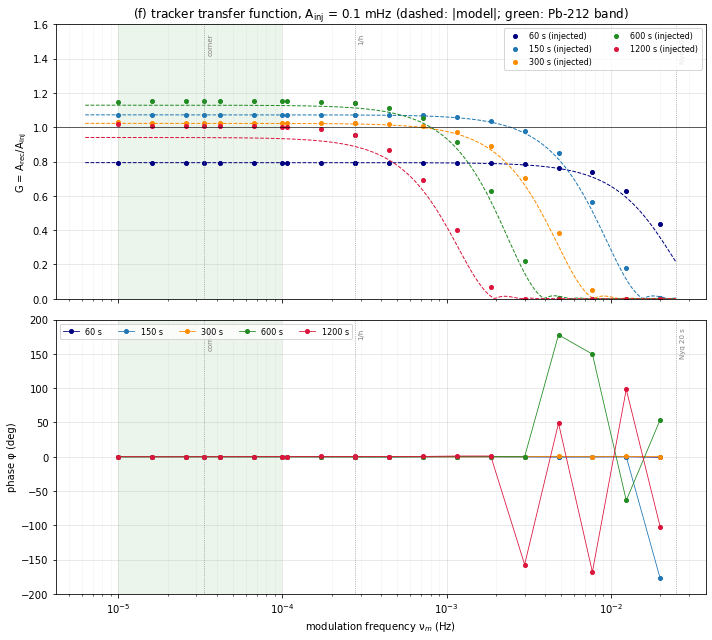

In [23]:
nu_f = np.logspace(-5.2, np.log10(2.5e-2), 300)
PRED = {w: static_gain(w, F0_SIM)[0]*kernel_response(w, nu_f) for w in TW_LIST}

print('G(ν_m, T_w) = A_rec/A_inj   (measured; model in brackets)')
print(f"{'ν_m (Hz)':>9} | " + ' | '.join(f'{w:>4d} s        ' for w in TW_LIST))
for j, nu in enumerate(NU_LIST):
    print(f'{nu:9.2e} | ' + ' | '.join(f'{GF[w][j,0]:5.3f} ({static_gain(w, F0_SIM)[0]*kernel_response(w, nu)[0]:+5.2f})' for w in TW_LIST))

def crossing(nu, g, level):
    below = np.flatnonzero(g < level)
    if not len(below) or below[0] == 0: return np.nan
    i = below[0]; x0, x1 = np.log10(nu[i-1]), np.log10(nu[i])
    return 10**(x0 + (level - g[i-1])*(x1 - x0)/(g[i] - g[i-1]))

print(f"\n{'T_w':>6} | {'plateau G (ν ≤ 1e-4)':>20} | {'ν at -10% (meas)':>16} | {'ν at -10% (model)':>17} | {'ν at 50% (meas)':>15} | {'1/T_w':>8}")
G0F = {}
for w in TW_LIST:
    G0F[w] = GF[w][NU_LIST <= 1e-4, 0].mean()
    gm = GF[w][:, 0]/G0F[w]; gp = np.abs(PRED[w])/abs(PRED[w][0])
    print(f'{w:4d} s | {G0F[w]:20.3f} | {crossing(NU_LIST, gm, 0.9):16.2e} | {crossing(nu_f, gp, 0.9):17.2e} | '
          f'{crossing(NU_LIST, gm, 0.5):15.2e} | {1/w:8.2e}')

fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
for w in TW_LIST:
    ax[0].semilogx(NU_LIST, GF[w][:, 0], 'o', ms=4, color=cols[w], label=f'{w} s (injected)')
    ax[0].semilogx(nu_f, np.abs(PRED[w]), '--', lw=1, color=cols[w])
    ax[1].semilogx(NU_LIST, np.degrees(GF[w][:, 1]), 'o-', ms=4, lw=0.8, color=cols[w], label=f'{w} s')
ax[0].axhline(1, color='k', lw=0.6)
for a in ax:
    a.axvspan(1e-5, 1e-4, color='green', alpha=0.08, lw=0)
    for x, lab in ((3.32e-5, 'corner'), (1/3600, '1/h'), (fs_p/2, 'Nyq 20 s')):
        a.axvline(x, color='gray', lw=0.7, ls=':'); a.text(x*1.05, 0.97, lab, transform=a.get_xaxis_transform(),
                                                           rotation=90, va='top', fontsize=7, color='gray')
    a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12)
ax[0].set_ylabel('G = A$_{\\rm rec}$/A$_{\\rm inj}$'); ax[0].set_ylim(0, 1.6); ax[0].legend(fontsize=8, ncol=2)
ax[0].set_title(f'(f) tracker transfer function, A$_{{\\rm inj}}$ = {A_MAIN*1e3:.1f} mHz (dashed: |model|; green: Pb-212 band)')
ax[1].set_ylabel('phase φ (deg)'); ax[1].set_xlabel('modulation frequency ν$_m$ (Hz)'); ax[1].set_ylim(-200, 200)
ax[1].legend(fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

[cache] f_sub: loaded

AMPLITUDE LINEARITY: G at A_inj = 0.03, 0.10, 0.30 mHz
  ν_m 1e-04,   60 s: 0.793  0.794  0.794   (max/min 1.002)
  ν_m 1e-04,  150 s: 1.072  1.073  1.085   (max/min 1.012)
  ν_m 1e-04,  300 s: 1.022  1.027  1.070   (max/min 1.046)
  ν_m 1e-04,  600 s: 1.129  1.153  1.105   (max/min 1.044)
  ν_m 1e-04, 1200 s: 0.939  1.002  0.982   (max/min 1.067)
  ν_m 1e-03,   60 s: 0.793  0.793  0.793   (max/min 1.000)
  ν_m 1e-03,  150 s: 1.055  1.062  1.074   (max/min 1.018)
  ν_m 1e-03,  300 s: 0.981  0.987  1.023   (max/min 1.043)
  ν_m 1e-03,  600 s: 0.957  0.977  0.971   (max/min 1.022)
  ν_m 1e-03, 1200 s: 0.500  0.495  0.547   (max/min 1.106)

CARRIER SUB-BIN POSITION (ν_m = 1e-4 Hz, A = 0.1 mHz): G measured (static pure-tone model)
   T_w | frac 0.00      | frac 0.25      | frac 0.50      | frac 0.75      | max/min
  60 s | 0.751 (0.75) | 0.907 (0.91) | 1.636 (1.64) | 0.907 (0.91) | 2.18
 150 s | 0.751 (0.75) | 0.908 (0.91) | 1.596 (1.64) | 0.908 (0.91) | 2.13
 300 s 

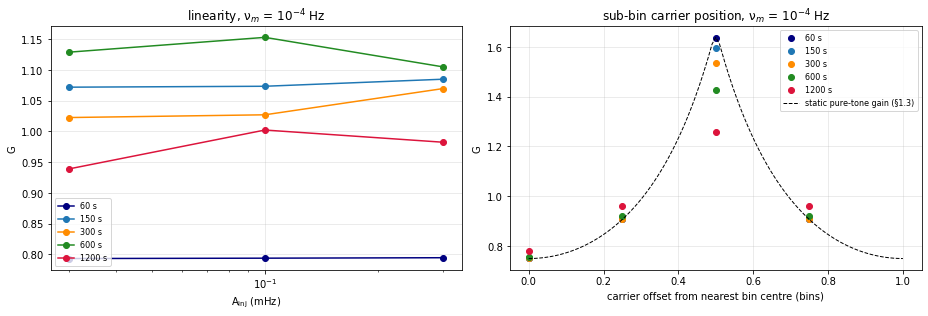

In [24]:
# amplitude linearity, carrier position, noise-free control
AMPS = (0.03e-3, 0.1e-3, 0.3e-3); NU_SUB = (1e-4, 1e-3); FRACS = (0.0, 0.25, 0.5, 0.75); NU_NF = (3.32e-5, 1e-4, 1e-3, 5e-3)
def _f_sub():
    global rng_f; rng_f = np.random.default_rng(8)
    lin = {(w, nu, A): run_sine(w, nu, A, SIGMA_F[w]) for w in TW_LIST for nu in NU_SUB for A in AMPS}
    binp = {(w, fr_): run_sine(w, 1e-4, A_MAIN, SIGMA_F[w], f0=(np.round(DIVISOR*F0_SIM*w) + fr_)/(DIVISOR*w))
            for w in TW_LIST for fr_ in FRACS}
    nf = {(w, nu): run_sine(w, nu, A_MAIN, 0) for w in TW_LIST for nu in NU_NF}
    return lin, binp, nf
LIN, BINP, NF = cached('f_sub', ('v1', DATA_FP, F0_SIM, A_MAIN, AMPS, NU_SUB, FRACS, NU_NF, TW_LIST), _f_sub)
print()

print('AMPLITUDE LINEARITY: G at A_inj = ' + ', '.join(f'{A*1e3:.2f}' for A in AMPS) + ' mHz')
for nu in NU_SUB:
    for w in TW_LIST:
        g = [LIN[(w, nu, A)][0] for A in AMPS]
        print(f'  ν_m {nu:.0e}, {w:4d} s: ' + '  '.join(f'{x:.3f}' for x in g) + f'   (max/min {max(g)/min(g):.3f})')

print('\nCARRIER SUB-BIN POSITION (ν_m = 1e-4 Hz, A = 0.1 mHz): G measured (static pure-tone model)')
print(f"{'T_w':>6} | " + ' | '.join(f'frac {f:4.2f}     ' for f in FRACS) + ' | max/min')
for w in TW_LIST:
    g = [BINP[(w, f)][0] for f in FRACS]
    gm = [np.interp((f + 0.5) % 1 - 0.5, d_true, gain) for f in FRACS]
    print(f'{w:4d} s | ' + ' | '.join(f'{a:.3f} ({b:.2f})' for a, b in zip(g, gm)) + f' | {max(g)/min(g):.2f}')

print('\nNOISE-FREE vs NOISY (A = 0.1 mHz) and stationary-tone scatter from (e)')
print(f"{'T_w':>6} | {'ν_m':>7} | {'G noisy':>7} | {'G noise-free':>12} | {'resid rms noisy':>15} | {'resid rms noise-free':>20} | {'stationary σ (e)':>16}")
for w in TW_LIST:
    for nu in NU_NF:
        gn, _, rn = GF[w][np.argmin(abs(NU_LIST - nu))]
        g0, _, r0 = NF[(w, nu)]
        print(f'{w:4d} s | {nu:7.1e} | {gn:7.3f} | {g0:12.3f} | {rn*1e3:11.5f} mHz | {r0*1e3:16.6f} mHz | {SIG_E[w]*1e3:12.5f} mHz')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for w in TW_LIST:
    ax[0].plot([A*1e3 for A in AMPS], [LIN[(w, 1e-4, A)][0] for A in AMPS], 'o-', color=cols[w], label=f'{w} s')
    ax[1].plot(FRACS, [BINP[(w, f)][0] for f in FRACS], 'o', ms=6, color=cols[w], label=f'{w} s')
dd = np.linspace(0, 1, 201)
ax[1].plot(dd, np.interp((dd + 0.5) % 1 - 0.5, d_true, gain), 'k--', lw=1, label='static pure-tone gain (§1.3)')
ax[0].set_xscale('log'); ax[0].set_xlabel('A$_{\\rm inj}$ (mHz)'); ax[0].set_ylabel('G'); ax[0].set_title('linearity, ν$_m$ = 10$^{-4}$ Hz')
ax[1].set_xlabel('carrier offset from nearest bin centre (bins)'); ax[1].set_ylabel('G'); ax[1].set_title('sub-bin carrier position, ν$_m$ = 10$^{-4}$ Hz')
for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

[cache] f_pb: loaded
Pb-like injection, 0.487 mHz x 2^(-t/10.6 h), 60 s / 20 s tracker, carrier at -0.136 bin:
  A_rec/A_inj = 0.778 (noisy),  0.778 (noise-free);  static pure-tone gain there 0.794
  carrier at 0.00 bin: A_rec/A_inj = 0.753
  carrier at 0.25 bin: A_rec/A_inj = 0.949
  carrier at 0.50 bin: A_rec/A_inj = 1.522
  carrier at 0.75 bin: A_rec/A_inj = 0.872

(e) amplitude ratios vs injected plateau gains, relative to 60 s:
   T_w | (e) std of 1 h means (mHz) | ratio to 60 s | G plateau (f) | ratio to 60 s
  60 s |                     0.0527 |          1.00 |         0.794 |          1.00
 150 s |                     0.0726 |          1.38 |         1.073 |          1.35
 300 s |                     0.0675 |          1.28 |         1.028 |          1.29
 600 s |                     0.0800 |          1.52 |         1.153 |          1.45
1200 s |                     0.0658 |          1.25 |         1.009 |          1.27


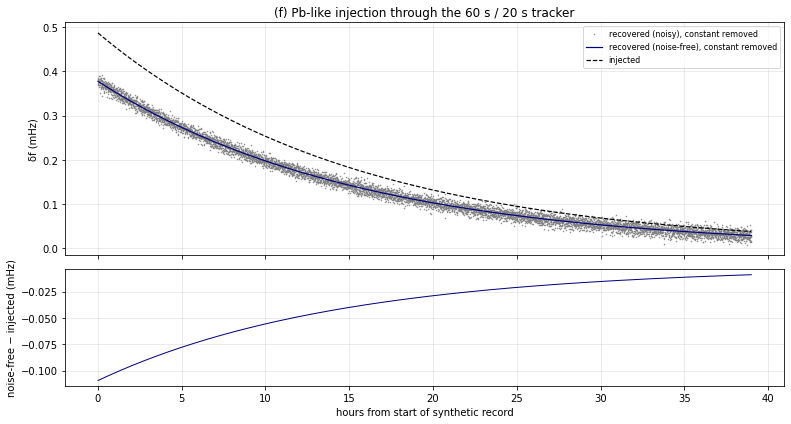

In [25]:
# Pb-like injection through the primary 60 s / 20 s tracker, and the (e) amplitude ratios vs measured gain
D_INJ = 0.487e-3; T_PB_SIM = 39*3600
T_HALF_INJ_H = 10.6; LAMBDA_INJ = np.log(2)/(T_HALF_INJ_H*3600)   # §2 is defined later
def run_pb(f0, sigma, win=WIN_P, step=STEP_P):
    y = synth(T_PB_SIM, f0, lambda t: 2*np.pi*DIVISOR*D_INJ*(1 - np.exp(-LAMBDA_INJ*t))/LAMBDA_INJ, sigma)
    tc, fr = track_synth(y, win, step, lambda tc: DIVISOR*(f0 + D_INJ*np.exp(-LAMBDA_INJ*tc)))
    M = np.c_[np.ones_like(tc), np.exp(-LAMBDA_INJ*tc)]
    (c, a) = np.linalg.lstsq(M, fr, rcond=None)[0]
    return tc, fr - c, a/D_INJ

def _f_pb():
    global rng_f; rng_f = np.random.default_rng(9)
    noisy, clean = run_pb(F0_SIM, SIGMA_F[60]), run_pb(F0_SIM, 0)
    by_frac = {fr_: run_pb((np.round(DIVISOR*F0_SIM*WIN_P) + fr_)/(DIVISOR*WIN_P), SIGMA_F[60])[2] for fr_ in FRACS}
    return noisy, clean, by_frac
(tc_pb, rec_pb, R_pb), (_, rec_pb0, R_pb0), R_PB_FR = cached(
    'f_pb', ('v1', F0_SIM, D_INJ, T_PB_SIM, T_HALF_INJ_H, WIN_P, STEP_P, SIGMA_F[60], FRACS), _f_pb)
print(f'Pb-like injection, {D_INJ*1e3:.3f} mHz x 2^(-t/{T_HALF_INJ_H} h), {WIN_P:.0f} s / {STEP_P:.0f} s tracker, carrier at '
      f'{static_gain(WIN_P, F0_SIM)[1]:+.3f} bin:')
print(f'  A_rec/A_inj = {R_pb:.3f} (noisy),  {R_pb0:.3f} (noise-free);  static pure-tone gain there {static_gain(WIN_P, F0_SIM)[0]:.3f}')
for fr_ in FRACS:
    print(f'  carrier at {fr_:.2f} bin: A_rec/A_inj = {R_PB_FR[fr_]:.3f}')

print('\n(e) amplitude ratios vs injected plateau gains, relative to 60 s:')
print(f"{'T_w':>6} | {'(e) std of 1 h means (mHz)':>26} | {'ratio to 60 s':>13} | {'G plateau (f)':>13} | {'ratio to 60 s':>13}")
s60 = slow60.std()
for w in TW_LIST:
    s = s60 if w == 60 else CMP_E[w]['slow'][CMP_E[w]['ok']].std()
    print(f'{w:4d} s | {s*1e3:26.4f} | {s/s60:13.2f} | {G0F[w]:13.3f} | {G0F[w]/G0F[60]:13.2f}')

h_pb = tc_pb/3600
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
ax[0].plot(h_pb, rec_pb*1e3, '.', ms=1, color='gray', label='recovered (noisy), constant removed')
ax[0].plot(h_pb, rec_pb0*1e3, color='navy', lw=1.2, label='recovered (noise-free), constant removed')
ax[0].plot(h_pb, D_INJ*np.exp(-LAMBDA_INJ*tc_pb)*1e3, 'k--', lw=1.2, label='injected')
ax[0].set_ylabel('δf (mHz)'); ax[0].legend(fontsize=8)
ax[0].set_title(f'(f) Pb-like injection through the {WIN_P:.0f} s / {STEP_P:.0f} s tracker')
ax[1].plot(h_pb, (rec_pb0 - D_INJ*np.exp(-LAMBDA_INJ*tc_pb))*1e3, color='navy', lw=1)
ax[1].set_ylabel('noise-free − injected (mHz)'); ax[1].set_xlabel('hours from start of synthetic record')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**(f) result** (validation only; nothing is corrected):
1. **Low-ν plateau.** For ν_m ≲ 2×10⁻⁴ Hz, including the whole Pb-212 band and the 33 µHz corner, G is
   flat in ν_m: 0.794 (60 s), 1.073 (150 s), 1.028 (300 s), 1.153 (600 s), 1.009 (1200 s). The tracker
   is quasi-static there. The plateau is **not 1**: it equals the static pure-tone interpolation gain at
   that tracker's carrier sub-bin position (−0.14, −0.34, +0.32, −0.36, +0.27 bin; model 0.79, 1.07,
   1.02, 1.13, 0.94).
2. **Attenuation onset** (G down 10% from its plateau): 8.6 mHz (60 s), 3.1 mHz (150 s), 1.5 mHz
   (300 s), 0.76 mHz (600 s), 0.36 mHz (1200 s), i.e. ≈ 0.45/T_w. 50% points: –, 8.0, 4.0, 2.0,
   0.98 mHz. The 60 s tracker is at 0.43 at 20 mHz. The kernel model reproduces the shape and onset
   within a few %.
3. **Phase:** 0° (within ~1°) wherever G is appreciable; no delay, as expected for a symmetric window.
   Above the cutoff, where G ≈ 0, the phase is undefined (the 600 s sign flip near 5 mHz is a sidelobe
   the model also predicts).
4. **Amplitude linearity** (0.03 / 0.1 / 0.3 mHz): 60 s linear to 0.2%; 150 s ≤ 2%; 300–1200 s 2–7%
   (11% for 1200 s at 1 mHz, already attenuated). Longer windows are mildly nonlinear because the same
   modulation spans a larger fraction of their bin, where the gain varies.
5. **Carrier sub-bin position dominates the gain:** G = 0.75 at a bin centre, 0.91 at 0.25 bin, up to
   1.64 at a bin edge (60 s; 1.26–1.6 for the long windows, where the modulation averages over the
   peak). It follows the §1.3 static pure-tone gain curve.
6. **Noise-free vs noisy:** the same G (within ~1% where G is appreciable). The noisy residual rms
   matches the stationary-tone σ from (e) for 60–150 s. For 600–1200 s the noise-free residual
   (0.006–0.008 mHz) exceeds that σ: deterministic distortion from the gain varying across the bin.
7. **Pb-like injection through the 60 s / 20 s tracker:** A_rec/A_inj = **0.778** (noisy and noise-free
   alike), close to the 0.794 sinusoid plateau; the residual is a pure scale factor (lower panel).
   With the carrier at 0 / 0.25 / 0.5 / 0.75 bin: 0.753 / 0.949 / 1.522 / 0.872.
8. **The (e) amplitude differences are explained by this gain.** Ratio of the std of 1 h means to 60 s
   in (e): 1.38 / 1.28 / 1.52 / 1.25; ratio of injected plateau gains: 1.35 / 1.29 / 1.45 / 1.27.

**(g) Independent continuous-frequency estimator (no FFT-bin interpolation).** Validation only.

Each 60 s segment (20 s step, same windows as the primary) is fitted in the time domain with
$y(t) = c_0 + c_1 t + A\cos 2\pi f t + B\sin 2\pi f t$ (t centred in the segment, no taper). f is a continuous
free parameter: for each trial f the linear parameters are solved by least squares and the residual is
minimised over f (bounded Brent, tolerance 10⁻⁹ Hz). The FFT supplies only the starting point: the raw
largest bin in the same band (no interpolation), with f confined to ±1 bin around it. Same optical line
as the parabolic tracker, then ÷2. Both estimators run on identical segments (paired comparison).

Expectation, to be tested: a correctly specified least-squares fit has no sub-bin-position gain, and for
slow modulation reports the uniformly weighted mean frequency over the segment (G → 1 at low ν). The
segment is not tapered, so other spectral content leaks into the fit more than with a Hann window.

[cache] g_synth: loaded
1. STATIONARY TONE + matched noise (60 s / 20 s): bias = mean(est - true), scatter = std
   carrier |  offset |  parab bias |   parab σ | direct bias |  direct σ  (mHz)
  measured |  -0.136 |     +0.2674 |   0.00799 |    +0.00023 |   0.00568
  0.00 bin |  +0.000 |     -0.0000 |   0.00827 |    -0.00009 |   0.00533
  0.25 bin |  +0.250 |     -0.4158 |   0.00927 |    +0.00005 |   0.00528
  0.50 bin |  +0.500 |     -0.0000 |   0.01400 |    -0.00002 |   0.00520
  0.75 bin |  -0.250 |     +0.4158 |   0.00915 |    -0.00002 |   0.00536

2. MODULATION A = 0.1 mHz at ν_m = 1e-04 Hz: G = A_rec/A_inj
   carrier | G parabolic | G direct | resid parab | resid direct (mHz)
  measured |       0.794 |    0.999 |     0.00816 |      0.00561
  0.00 bin |       0.751 |    1.000 |     0.00806 |      0.00554
  0.25 bin |       0.907 |    0.999 |     0.00912 |      0.00545
  0.50 bin |       1.636 |    1.000 |     0.01440 |      0.00569
  0.75 bin |       0.907 |    0.998 |     0.00932

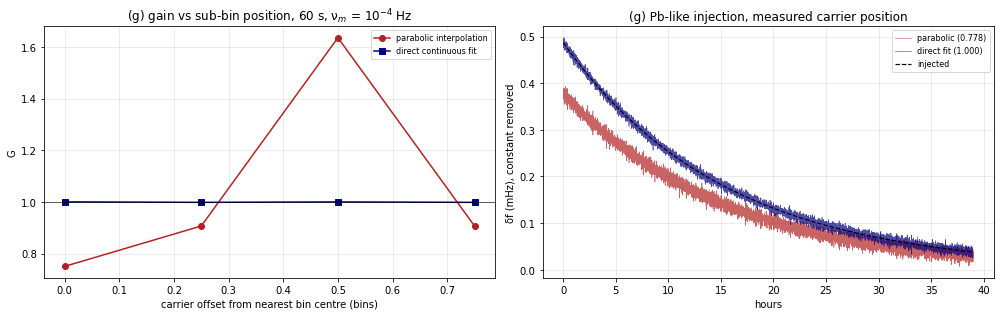

In [26]:
from scipy.optimize import minimize_scalar

def freq_direct(x, fsx, f_guess, df_bin):
    """continuous-frequency LS fit of c0 + c1 t + A cos 2πft + B sin 2πft; f within ±1 bin of f_guess"""
    n = len(x); tt = (np.arange(n) - (n - 1)/2)/fsx
    base = np.c_[np.ones(n), tt]
    def cost(f):
        M = np.c_[base, np.cos(2*np.pi*f*tt), np.sin(2*np.pi*f*tt)]
        r = x - M @ np.linalg.lstsq(M, x, rcond=None)[0]
        return r @ r
    return minimize_scalar(cost, bounds=(f_guess - df_bin, f_guess + df_bin), method='bounded',
                           options=dict(xatol=1e-9)).x

def track_both(y, win, step, f_opt_fn, t0=0.0):
    """same windows and band as track_rotor(guide=True); returns (tc, parabolic, direct), rotor Hz"""
    nw_, sw_ = int(win*fs16), int(step*fs16); out = []
    for i in range(0, len(y) - nw_, sw_):
        tc = t0 + i/fs16 + win/2; trk = f_opt_fn(tc); seg = y[i:i+nw_]
        fraw, fpk, _ = peak_in_band(seg, fs16, max(trk*0.85, 0.02), trk*1.10)
        out.append((tc, fpk/DIVISOR, freq_direct(seg, fs16, fraw, fs16/nw_)/DIVISOR))
    return map(np.array, zip(*out))

POS_G = [('measured', F0_SIM)] + [(f'{fr_:.2f} bin', (np.round(DIVISOR*F0_SIM*WIN_P) + fr_)/(DIVISOR*WIN_P)) for fr_ in FRACS]
sig60 = SIGMA_F[60]
NU_G, A_G = 1e-4, 0.1e-3

def _g_synth():
    global rng_f; rng_f = np.random.default_rng(10)
    stat, gg, pbg = {}, {}, {}
    for lab, f0b in POS_G:                                  # 1. stationary tone
        y = synth(2*3600, f0b, lambda t: 0*t, sig60)
        tc, fpa, fdi = track_both(y, WIN_P, STEP_P, lambda tc: DIVISOR*f0b)
        stat[lab] = (fpa.mean() - f0b, fpa.std(), fdi.mean() - f0b, fdi.std())
    for lab, f0b in POS_G:                                  # 2. slow sinusoidal modulation
        y = synth(t_sim(NU_G), f0b, lambda t: DIVISOR*A_G*(1 - np.cos(2*np.pi*NU_G*t))/NU_G, sig60)
        tc, fpa, fdi = track_both(y, WIN_P, STEP_P, lambda tc: DIVISOR*(f0b + A_G*np.sin(2*np.pi*NU_G*tc)))
        M = np.c_[np.ones_like(tc), np.sin(2*np.pi*NU_G*tc), np.cos(2*np.pi*NU_G*tc)]
        res = []
        for f_ in (fpa, fdi):
            b = np.linalg.lstsq(M, f_, rcond=None)[0]; res.append((np.hypot(b[1], b[2])/A_G, (f_ - M @ b).std()))
        gg[lab] = res
    for lab, f0b in POS_G:                                  # 3. Pb-like injection
        y = synth(T_PB_SIM, f0b, lambda t: 2*np.pi*DIVISOR*D_INJ*(1 - np.exp(-LAMBDA_INJ*t))/LAMBDA_INJ, sig60)
        tc, fpa, fdi = track_both(y, WIN_P, STEP_P, lambda tc: DIVISOR*(f0b + D_INJ*np.exp(-LAMBDA_INJ*tc)))
        M = np.c_[np.ones_like(tc), np.exp(-LAMBDA_INJ*tc)]
        bp, bd = (np.linalg.lstsq(M, f_, rcond=None)[0] for f_ in (fpa, fdi))
        pbg[lab] = (tc, fpa - bp[0], fdi - bd[0], bp[1]/D_INJ, bd[1]/D_INJ, bp[0] - f0b, bd[0] - f0b)
    return stat, gg, pbg
STAT_G, GG, PBG = cached('g_synth', ('v1', F0_SIM, sig60, tuple(POS_G), NU_G, A_G, D_INJ, T_PB_SIM, T_HALF_INJ_H,
                                     WIN_P, STEP_P), _g_synth)

print('1. STATIONARY TONE + matched noise (60 s / 20 s): bias = mean(est - true), scatter = std')
print(f"{'carrier':>10} | {'offset':>7} | {'parab bias':>11} | {'parab σ':>9} | {'direct bias':>11} | {'direct σ':>9}  (mHz)")
for lab, f0b in POS_G:
    b_p, s_p, b_d, s_d = STAT_G[lab]
    print(f'{lab:>10} | {static_gain(WIN_P, f0b)[1]:+7.3f} | {b_p*1e3:+11.4f} | {s_p*1e3:9.5f} | {b_d*1e3:+11.5f} | {s_d*1e3:9.5f}')
print(f'\n2. MODULATION A = {A_G*1e3:.1f} mHz at ν_m = {NU_G:.0e} Hz: G = A_rec/A_inj')
print(f"{'carrier':>10} | {'G parabolic':>11} | {'G direct':>8} | {'resid parab':>11} | {'resid direct':>12} (mHz)")
for lab, _ in POS_G:
    res = GG[lab]
    print(f'{lab:>10} | {res[0][0]:11.3f} | {res[1][0]:8.3f} | {res[0][1]*1e3:11.5f} | {res[1][1]*1e3:12.5f}')
print(f'\n3. Pb-LIKE INJECTION {D_INJ*1e3:.3f} mHz x 2^(-t/{T_HALF_INJ_H} h), 39 h: A_rec/A_inj')
for lab, _ in POS_G:
    p = PBG[lab]
    print(f'{lab:>10}: parabolic {p[3]:.3f}, direct {p[4]:.3f}   (offset: parab {p[5]*1e3:+.4f}, direct {p[6]*1e3:+.5f} mHz)')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
fr_x = [0, 0.25, 0.5, 0.75]
ax[0].plot(fr_x, [GG[l][0][0] for l, _ in POS_G[1:]], 'o-', color='firebrick', label='parabolic interpolation')
ax[0].plot(fr_x, [GG[l][1][0] for l, _ in POS_G[1:]], 's-', color='navy', label='direct continuous fit')
ax[0].axhline(1, color='k', lw=0.6); ax[0].set_xlabel('carrier offset from nearest bin centre (bins)'); ax[0].set_ylabel('G')
ax[0].set_title(f'(g) gain vs sub-bin position, {WIN_P:.0f} s, ν$_m$ = 10$^{{-4}}$ Hz'); ax[0].legend(fontsize=8)
tc_, fpa_, fdi_ = PBG['measured'][:3]
ax[1].plot(tc_/3600, fpa_*1e3, color='firebrick', lw=0.6, alpha=0.7, label=f'parabolic ({PBG["measured"][3]:.3f})')
ax[1].plot(tc_/3600, fdi_*1e3, color='navy', lw=0.6, alpha=0.7, label=f'direct fit ({PBG["measured"][4]:.3f})')
ax[1].plot(tc_/3600, D_INJ*np.exp(-LAMBDA_INJ*tc_)*1e3, 'k--', lw=1.2, label='injected')
ax[1].set_xlabel('hours'); ax[1].set_ylabel('δf (mHz), constant removed'); ax[1].legend(fontsize=8)
ax[1].set_title('(g) Pb-like injection, measured carrier position')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

[cache] g_real: loaded
real data, 7020 windows (parabolic branch reproduces the primary exactly)

                             |  parabolic | direct fit
mean f (Hz)                  |   0.749140 |   0.748876
std δf (mHz)                 |     0.1396 |     0.1296
std of 1 h means (mHz)       |     0.0527 |     0.0664

correlation: raw δf 0.890; 1 h means 0.9990
rms difference: raw 0.0640 mHz; 1 h means 0.0139 mHz
1 h means, least-squares slope direct vs parabolic: 1.258   (1/0.794 = 1.259)

major multi-hour structures (1 h means, mHz):
  5-8 h dip (min)     : parabolic -0.1713, direct -0.2149, ratio 1.254
  8-12 h rise (max)   : parabolic +0.0908, direct +0.1134, ratio 1.248
  17-20 h dip (min)   : parabolic -0.0854, direct -0.1069, ratio 1.253
  20-24 h step (max)  : parabolic +0.0900, direct +0.1133, ratio 1.258


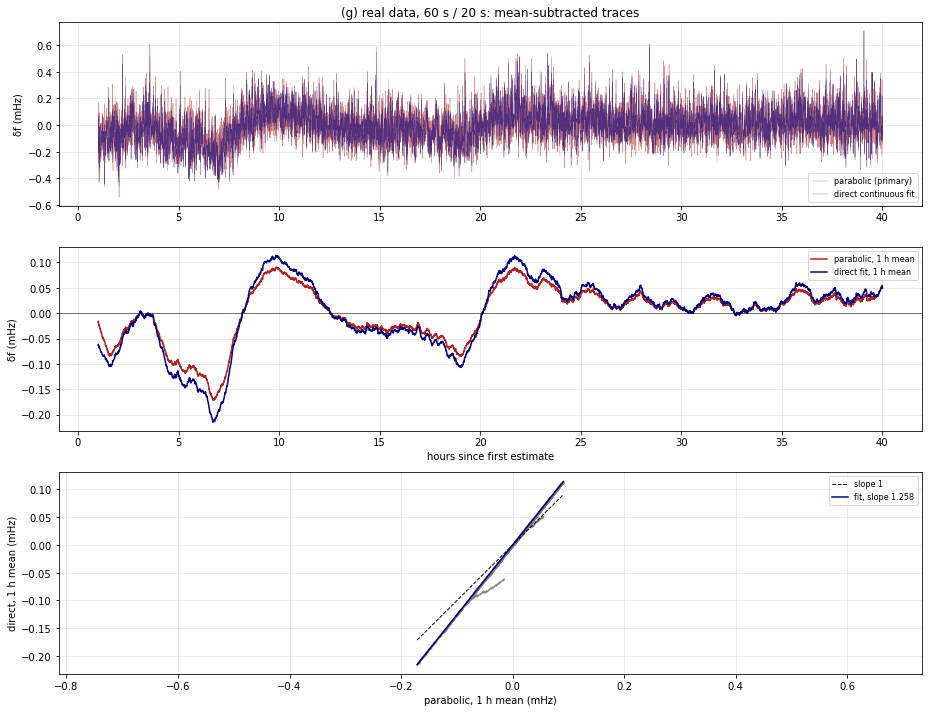

In [27]:
# 4. real data: same 60 s / 20 s windows, guided band as the primary
t0_ = time.time()
Tg, Fg_par, Fg_dir = cached('g_real', ('v1', DATA_FP, WIN_P, STEP_P),
    lambda: tuple(track_both(y16, WIN_P, STEP_P, lambda tc: np.interp(tc, T, FR)*DIVISOR, t0=t16[0])))
mg = ((Tg - T_REF)/3600 >= WIN_H[0]) & ((Tg - T_REF)/3600 <= WIN_H[1])
Tg, Fg_par, Fg_dir = Tg[mg], Fg_par[mg], Fg_dir[mg]
assert np.array_equal(Fg_par, f_p) and np.allclose(Tg, t_p), 'parabolic branch != primary series'
print(f'real data, {len(Tg)} windows (parabolic branch reproduces the primary exactly)\n')

dpa, ddi = Fg_par - Fg_par.mean(), Fg_dir - Fg_dir.mean()
spa, sdi = (uniform_filter1d(x, N_SLOW, mode='nearest') for x in (dpa, ddi))
print(f"{'':28s} | {'parabolic':>10} | {'direct fit':>10}")
print(f"{'mean f (Hz)':28s} | {Fg_par.mean():10.6f} | {Fg_dir.mean():10.6f}")
print(f"{'std δf (mHz)':28s} | {dpa.std()*1e3:10.4f} | {ddi.std()*1e3:10.4f}")
print(f"{'std of 1 h means (mHz)':28s} | {spa.std()*1e3:10.4f} | {sdi.std()*1e3:10.4f}")
print(f'\ncorrelation: raw δf {np.corrcoef(dpa, ddi)[0, 1]:.3f}; 1 h means {np.corrcoef(spa, sdi)[0, 1]:.4f}')
print(f'rms difference: raw {np.sqrt(np.mean((dpa - ddi)**2))*1e3:.4f} mHz; 1 h means {np.sqrt(np.mean((spa - sdi)**2))*1e3:.4f} mHz')
slope = np.polyfit(spa, sdi, 1)[0]
print(f'1 h means, least-squares slope direct vs parabolic: {slope:.3f}   (1/0.794 = {1/0.794:.3f})')
hg = (Tg - T_REF)/3600
print('\nmajor multi-hour structures (1 h means, mHz):')
for lab, lo, hi, fn in (('5-8 h dip (min)', 5, 8, np.min), ('8-12 h rise (max)', 8, 12, np.max),
                        ('17-20 h dip (min)', 17, 20, np.min), ('20-24 h step (max)', 20, 24, np.max)):
    m = (hg >= lo) & (hg <= hi); a, b = fn(spa[m]), fn(sdi[m])
    print(f'  {lab:20s}: parabolic {a*1e3:+.4f}, direct {b*1e3:+.4f}, ratio {b/a:.3f}')

fig, ax = plt.subplots(3, 1, figsize=(13, 10), gridspec_kw=dict(height_ratios=[1, 1, 1.1]))
ax[0].plot(hg, dpa*1e3, color='firebrick', lw=0.4, alpha=0.6, label='parabolic (primary)')
ax[0].plot(hg, ddi*1e3, color='navy', lw=0.4, alpha=0.6, label='direct continuous fit')
ax[0].set_ylabel('δf (mHz)'); ax[0].set_title('(g) real data, 60 s / 20 s: mean-subtracted traces')
ax[1].plot(hg, spa*1e3, color='firebrick', lw=1.5, label='parabolic, 1 h mean')
ax[1].plot(hg, sdi*1e3, color='navy', lw=1.5, label='direct fit, 1 h mean')
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_ylabel('δf (mHz)'); ax[1].set_xlabel('hours since first estimate')
ax[2].plot(spa*1e3, sdi*1e3, '.', ms=1, color='gray')
xx = np.array([spa.min(), spa.max()])*1e3
ax[2].plot(xx, xx, 'k--', lw=1, label='slope 1'); ax[2].plot(xx, slope*xx, color='navy', lw=1.5, label=f'fit, slope {slope:.3f}')
ax[2].set_xlabel('parabolic, 1 h mean (mHz)'); ax[2].set_ylabel('direct, 1 h mean (mHz)'); ax[2].set_aspect('equal', 'datalim')
for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**(g) result** (validation only; primary unchanged):
1. **Stationary tone:** direct-fit bias ≤ 0.0003 mHz at every carrier position (parabolic: up to ±0.42 mHz,
   +0.27 mHz at the measured position). Direct-fit scatter 0.0052–0.0057 mHz vs parabolic 0.0080–0.0140 mHz.
2. **Slow modulation (0.1 mHz, 10⁻⁴ Hz):** direct-fit G = 0.998–1.001 at all five carrier positions;
   parabolic 0.751–1.636. The direct fit shows no sub-bin-position gain dependence.
3. **Pb-like injection:** direct fit A_rec/A_inj = 1.000 at all positions, offset ≤ 0.0001 mHz;
   parabolic 0.752–1.522 (0.778 at the measured position).
4. **Real data, same windows:** the two estimators give the same slow evolution, 1 h means correlate at
   0.999 and every major structure is present in both. The direct fit's amplitude is larger by a
   uniform factor: least-squares slope 1.258 (1 h means), and 1.248–1.258 for the four major structures
   (5–8 h dip, 8–12 h rise, 17–20 h dip, 20–24 h step). The injection-measured parabolic gain predicts
   1/0.794 = 1.259. Std of 1 h means: 0.0664 mHz (direct) vs 0.0527 mHz (parabolic). Mean frequency:
   0.748876 Hz (direct) vs 0.749140 Hz (parabolic); the 1200 s parabolic mean is 0.748863 Hz.
5. Raw-δf correlation is lower (0.890) and the direct fit has the smaller total std (0.130 vs 0.140 mHz)
   despite the larger slow amplitude. The two estimators weight the segment differently (uniform vs
   Hann), so their fast-timescale responses differ; their high-ν transfer functions were not compared here.

**(h) Estimator selection: transfer function of the direct fit vs the parabolic tracker, 60 s / 20 s.**
Validation only. Same injection framework as (f) (carrier f0, matched noise, A_inj = 0.1 mHz, record
max(4/ν_m, 2 h) up to 100 h), same direct-fit model as (g); both estimators run on identical synthetic
segments. Swept from 10⁻⁵ Hz to 24 mHz. **25 mHz (the 20 s-step Nyquist) is not measurable**: a
sinusoid sampled exactly at Nyquist has no recoverable amplitude or phase; the model value is given.

Models (dashed): parabolic = static pure-tone gain × Hann phase kernel (as (f)); direct = static gain 1 ×
uniform-weight phase kernel $K(t)\propto (T_w/2)^2 - t^2$.

[cache] h_tf: loaded

 ν_m (Hz) | G parabolic | (model) |  φ par | G direct | (model) |  φ dir
 1.00e-05 |       0.794 |  +0.794 |   -0.0 |    1.000 |  +1.000 |   +0.1
 1.61e-05 |       0.794 |  +0.794 |   +0.0 |    1.000 |  +1.000 |   +0.1
 2.59e-05 |       0.794 |  +0.794 |   -0.0 |    0.999 |  +1.000 |   -0.1
 3.32e-05 |       0.794 |  +0.794 |   +0.0 |    1.000 |  +1.000 |   +0.0
 4.16e-05 |       0.794 |  +0.794 |   -0.0 |    1.000 |  +1.000 |   +0.1
 6.69e-05 |       0.794 |  +0.794 |   -0.0 |    1.002 |  +1.000 |   +0.1
 1.00e-04 |       0.794 |  +0.793 |   +0.0 |    0.998 |  +1.000 |   -0.1
 1.08e-04 |       0.794 |  +0.793 |   +0.0 |    1.000 |  +1.000 |   -0.0
 1.73e-04 |       0.794 |  +0.793 |   +0.0 |    1.002 |  +1.000 |   +0.1
 2.78e-04 |       0.794 |  +0.793 |   -0.0 |    1.000 |  +1.000 |   +0.2
 4.47e-04 |       0.793 |  +0.793 |   -0.0 |    0.999 |  +0.999 |   -0.2
 7.19e-04 |       0.793 |  +0.793 |   -0.1 |    0.998 |  +0.998 |   -0.2
 1.00e-03 |       0.793 |  +0

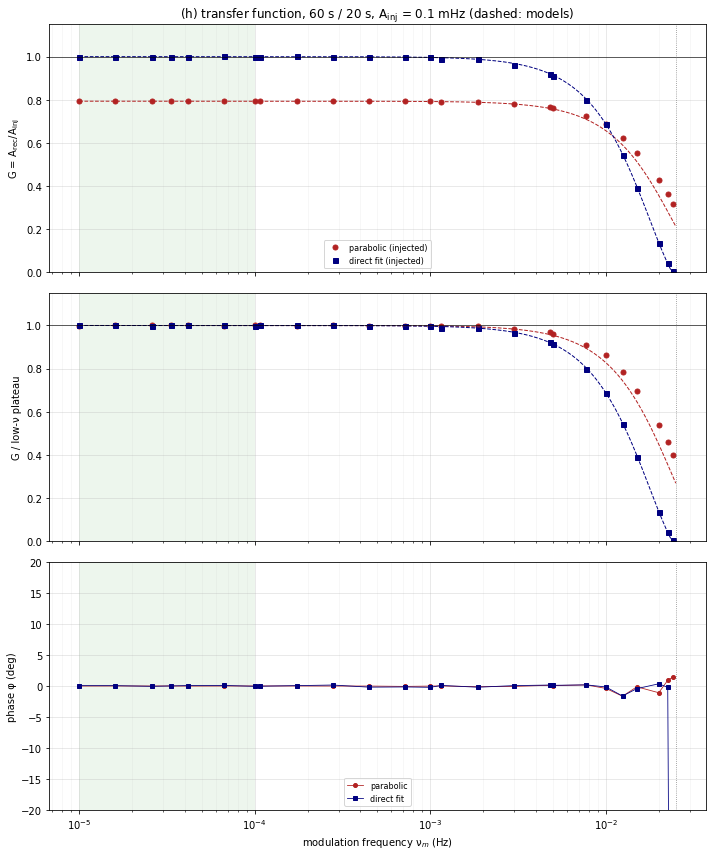

In [28]:
def kernel_response_uniform(win, nu):
    dt = 0.5; tk = np.arange(-win/2, win/2 + dt/2, dt); K = 1 - (2*tk/win)**2; K /= K.sum()
    return np.array([np.sum(K*np.cos(2*np.pi*v*tk)) for v in np.atleast_1d(nu)])

def run_sine_pair(nu, A, sigma, f0=F0_SIM, win=WIN_P, step=STEP_P):
    y = synth(t_sim(nu), f0, lambda t: DIVISOR*A*(1 - np.cos(2*np.pi*nu*t))/nu, sigma)
    tc, fpa, fdi = track_both(y, win, step, lambda tc: DIVISOR*(f0 + A*np.sin(2*np.pi*nu*tc)))
    M = np.c_[np.ones_like(tc), np.sin(2*np.pi*nu*tc), np.cos(2*np.pi*nu*tc)]
    out = []
    for f_ in (fpa, fdi):
        b = np.linalg.lstsq(M, f_, rcond=None)[0]
        out += [np.hypot(b[1], b[2])/A, np.arctan2(b[2], b[1]), (f_ - M @ b).std()]
    return out                                            # G_par, φ_par, resid_par, G_dir, φ_dir, resid_dir

nu_h = np.sort(np.r_[NU_LIST, 1e-3, 5e-3, 1e-2, 1.5e-2, 2e-2, 2.25e-2, 2.4e-2])
NU_H = nu_h[np.r_[True, np.diff(nu_h)/nu_h[1:] > 0.02]]   # drop near-duplicates
NU_NFH = (1e-4, 1e-3, 1e-2, 2e-2)
def _h_tf():
    global rng_f; rng_f = np.random.default_rng(11)
    return (np.array([run_sine_pair(nu, A_MAIN, sig60) for nu in NU_H]),
            {nu: run_sine_pair(nu, A_MAIN, 0) for nu in NU_NFH})
GH, GH_NF = cached('h_tf', ('v1', F0_SIM, A_MAIN, tuple(NU_H), NU_NFH, sig60, WIN_P, STEP_P, T_SIM_MAX), _h_tf)
print()

g_par_model = lambda nu: static_gain(WIN_P, F0_SIM)[0]*kernel_response(WIN_P, nu)
g_dir_model = lambda nu: kernel_response_uniform(WIN_P, nu)
print(f"{'ν_m (Hz)':>9} | {'G parabolic':>11} | {'(model)':>7} | {'φ par':>6} | {'G direct':>8} | {'(model)':>7} | {'φ dir':>6}")
for j, nu in enumerate(NU_H):
    print(f'{nu:9.2e} | {GH[j,0]:11.3f} | {g_par_model(nu)[0]:+7.3f} | {np.degrees(GH[j,1]):+6.1f} | '
          f'{GH[j,3]:8.3f} | {g_dir_model(nu)[0]:+7.3f} | {np.degrees(GH[j,4]):+6.1f}')
print(f'{0.025:9.2e} | {"not measurable (Nyquist)":>31} | model: parabolic {g_par_model(0.025)[0]:+.3f}, direct {g_dir_model(0.025)[0]:+.3f}')

print(f"\n{'':24s} | {'parabolic':>10} | {'direct':>10}")
low = NU_H <= 1e-4
pl_p, pl_d = GH[low, 0].mean(), GH[low, 3].mean()
print(f"{'low-ν plateau G':24s} | {pl_p:10.3f} | {pl_d:10.3f}")
for lev, lab in ((0.9, 'ν at -10% of plateau'), (0.5, 'ν at 50% of plateau')):
    a, b = crossing(NU_H, GH[:, 0]/pl_p, lev), crossing(NU_H, GH[:, 3]/pl_d, lev)
    print(f"{lab:24s} | " + ' | '.join('    not reached' if np.isnan(x) else f'{x*1e3:7.2f} mHz' for x in (a, b)))
for nu in (1e-3, 5e-3, 1e-2, 2e-2):
    j = np.argmin(abs(NU_H - nu))
    print(f"{f'G at {nu*1e3:g} mHz':24s} | {GH[j,0]:10.3f} | {GH[j,3]:10.3f}   (relative to plateau: {GH[j,0]/pl_p:.3f}, {GH[j,3]/pl_d:.3f})")
j = np.argmin(abs(NU_H - 2.4e-2))
print(f"{'G at 24 mHz':24s} | {GH[j,0]:10.3f} | {GH[j,3]:10.3f}   (relative to plateau: {GH[j,0]/pl_p:.3f}, {GH[j,3]/pl_d:.3f})")
print(f"{'G at 25 mHz (model only)':24s} | {g_par_model(0.025)[0]:10.3f} | {g_dir_model(0.025)[0]:10.3f}")
ok_ph = (GH[:, 0] > 0.1) & (GH[:, 3] > 0.1)
print(f"{'max |φ| where G > 0.1':24s} | {np.degrees(np.abs(GH[ok_ph, 1])).max():9.2f}° | {np.degrees(np.abs(GH[ok_ph, 4])).max():9.2f}°")
print(f"{'resid rms, ν ≤ 1e-4 (mHz)':24s} | {GH[low, 2].mean()*1e3:10.5f} | {GH[low, 5].mean()*1e3:10.5f}")

print('\nNOISE-FREE vs NOISY (A = 0.1 mHz)')
print(f"{'ν_m':>8} | {'G par noisy':>11} | {'noise-free':>10} | {'G dir noisy':>11} | {'noise-free':>10} | {'resid dir noise-free (mHz)':>26}")
for nu in NU_NFH:
    j = np.argmin(abs(NU_H - nu)); nf = GH_NF[nu]
    print(f'{nu:8.0e} | {GH[j,0]:11.3f} | {nf[0]:10.3f} | {GH[j,3]:11.3f} | {nf[3]:10.3f} | {nf[5]*1e3:26.6f}')

fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
nu_m = np.logspace(-5, np.log10(0.025), 300)
for a, norm in ((ax[0], False), (ax[1], True)):
    a.semilogx(NU_H, GH[:, 0]/(pl_p if norm else 1), 'o', ms=5, color='firebrick', label='parabolic (injected)')
    a.semilogx(NU_H, GH[:, 3]/(pl_d if norm else 1), 's', ms=5, color='navy', label='direct fit (injected)')
    a.semilogx(nu_m, g_par_model(nu_m)/(static_gain(WIN_P, F0_SIM)[0] if norm else 1), '--', color='firebrick', lw=1)
    a.semilogx(nu_m, g_dir_model(nu_m), '--', color='navy', lw=1)
    a.axhline(1, color='k', lw=0.6)
ax[0].set_ylabel('G = A$_{\\rm rec}$/A$_{\\rm inj}$'); ax[0].set_ylim(0, 1.15); ax[0].legend(fontsize=8)
ax[0].set_title(f'(h) transfer function, {WIN_P:.0f} s / {STEP_P:.0f} s, A$_{{\\rm inj}}$ = {A_MAIN*1e3:.1f} mHz (dashed: models)')
ax[1].set_ylabel('G / low-ν plateau'); ax[1].set_ylim(0, 1.15)
ax[2].semilogx(NU_H, np.degrees(GH[:, 1]), 'o-', ms=4, lw=0.8, color='firebrick', label='parabolic')
ax[2].semilogx(NU_H, np.degrees(GH[:, 4]), 's-', ms=4, lw=0.8, color='navy', label='direct fit')
ax[2].set_ylabel('phase φ (deg)'); ax[2].set_ylim(-20, 20); ax[2].legend(fontsize=8)
ax[2].set_xlabel('modulation frequency ν$_m$ (Hz)')
for a in ax:
    a.axvline(fs_p/2, color='gray', lw=0.8, ls=':'); a.axvspan(1e-5, 1e-4, color='green', alpha=0.07, lw=0)
    a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12)
plt.tight_layout(); plt.show()

**(h) result** (60 s / 20 s; validation only, no change to either analysis):

| | parabolic (primary) | direct fit |
|---|---|---|
| low-ν plateau G (≤ 10⁻⁴ Hz) | 0.794 | 1.000 |
| sub-bin dependence of G (from (g)) | 0.751–1.636 | 0.998–1.000 |
| low-ν bias of mean (from (g)) | up to ±0.42 mHz | ≤ 0.0003 mHz |
| estimator scatter (resid rms, low ν) | 0.0084 mHz | 0.0056 mHz |
| −10% point | 8.2 mHz | 5.2 mHz |
| 50% point | 21.2 mHz | 13.1 mHz |
| G / plateau at 1 / 5 / 10 / 20 / 24 mHz | 1.000 / 0.962 / 0.864 / 0.540 / 0.401 | 0.998 / 0.912 / 0.686 / 0.135 / 0.004 |
| 25 mHz | not measurable (Nyquist); model 0.21 | not measurable; model ≈ 0 |
| phase where G > 0.1 | ≤ 1.7° | ≤ 1.6° |
| agreement with model | within ~0.01 to 10 mHz; above that G exceeds the model (0.43 vs 0.36 at 20 mHz) | within ~0.01 everywhere |
| noisy vs noise-free G | same to ≤ 0.005 | same to ≤ 0.005 |

- The direct fit is unbiased and carrier-independent at low ν, with lower scatter, and its response
  matches a closed-form kernel (uniform-weight phase slope) at all ν.
- Its bandwidth at T_w = 60 s is narrower: the uniform weighting averages over the segment more than
  the Hann-weighted parabolic peak does. Above ~10 mHz it passes much less (0.14 vs 0.54 of plateau at
  20 mHz), and its response reaches ~0 near the 24 mHz first null of its kernel.
- The parabolic tracker's high-ν response also depends on the carrier's sub-bin position (its absolute
  gain does), so its high-ν level is not known without that position.

**(i) Direct-fit window length: 60 vs 40 vs 30 s** (20 s step for all). Validation only; chooses the
direct-fit window before freezing the primary estimator.

Per window: (1) stationary-tone bias and scatter, (2) G at 10⁻⁴ Hz, (3) Pb-like recovery, (4) transfer
function (−10% and 50% points), using the (g)/(h) framework with noise matched to that window's measured
median SNR; (5) the real-data PSD with the primary conventions (Hann full-record periodogram,
log-binned). Agreement of the real-data spectra is judged against the scatter expected from the measured
stationary-tone σ. Trade-off: bandwidth vs the white estimator floor 2σ²/f_s.

[cache] i_real: loaded
[cache] i_synth: loaded
 window |  SNR | stat. bias (mHz) | stat. σ (mHz) | G(1e-4 Hz) | Pb A_rec/A_inj | −10% (mHz) | 50% (mHz) | G at 10 / 20 mHz
   60 s |  552 |         +0.00010 |       0.00579 |      1.000 |          1.000 |       5.28 |     13.20 |   0.685 / 0.142
   40 s |  489 |         -0.00050 |       0.00967 |      0.998 |          0.999 |       8.04 |     20.08 |   0.853 / 0.503
   30 s |  469 |         -0.00017 |       0.01268 |      1.002 |          0.999 |      10.66 |    > 24 mHz |   0.912 / 0.683
(50% "> 24 mHz": not reached below the highest measurable ν; Nyquist of the 20 s step is 25 mHz)


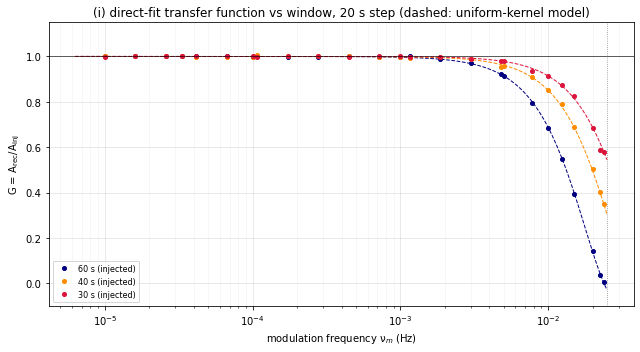

In [29]:
WINS_I = (60, 40, 30)
def track_direct(y, win, step, f_opt_fn, t0=0.0):
    """direct-fit tracker (same seed bin, bounds and model as track_both); returns (tc, f_direct, snr), rotor Hz"""
    nw_, sw_ = int(win*fs16), int(step*fs16); out = []
    for i in range(0, len(y) - nw_, sw_):
        tc = t0 + i/fs16 + win/2; trk = f_opt_fn(tc); seg = y[i:i+nw_]
        fraw, _, snr = peak_in_band(seg, fs16, max(trk*0.85, 0.02), trk*1.10)
        out.append((tc, freq_direct(seg, fs16, fraw, fs16/nw_)/DIVISOR, snr))
    return map(np.array, zip(*out))

def _i_real():
    out = {}
    for w in WINS_I:
        t_, f_, s_ = track_direct(y16, w, STEP_P, lambda tc: np.interp(tc, T, FR)*DIVISOR, t0=t16[0])
        m = ((t_ - T_REF)/3600 >= WIN_H[0]) & ((t_ - T_REF)/3600 <= WIN_H[1])
        out[w] = dict(t=t_[m], f=f_[m], d=f_[m] - f_[m].mean(), snr=np.median(s_[m]))
    return out
REAL_I = cached('i_real', ('v1', DATA_FP, WINS_I, STEP_P), _i_real)
assert np.array_equal(REAL_I[60]['f'], Fg_dir), '60 s direct track != (g) direct series'

def _i_synth():
    global rng_f; rng_f = np.random.default_rng(12)
    res = {}
    for w in WINS_I:
        sig = sigma_for(w, F0_SIM*DIVISOR, REAL_I[w]['snr'])
        y = synth(2*3600, F0_SIM, lambda t: 0*t, sig)                                   # (1) stationary
        _, fd, _ = track_direct(y, w, STEP_P, lambda tc: DIVISOR*F0_SIM)
        stat = (fd.mean() - F0_SIM, fd.std())
        tf = []                                                                         # (2), (4) sinusoidal FM
        for nu in NU_H:
            y = synth(t_sim(nu), F0_SIM, lambda t: DIVISOR*A_MAIN*(1 - np.cos(2*np.pi*nu*t))/nu, sig)
            tc, fd, _ = track_direct(y, w, STEP_P, lambda tc: DIVISOR*(F0_SIM + A_MAIN*np.sin(2*np.pi*nu*tc)))
            M = np.c_[np.ones_like(tc), np.sin(2*np.pi*nu*tc), np.cos(2*np.pi*nu*tc)]
            b = np.linalg.lstsq(M, fd, rcond=None)[0]
            tf.append((np.hypot(b[1], b[2])/A_MAIN, np.arctan2(b[2], b[1]), (fd - M @ b).std()))
        y = synth(T_PB_SIM, F0_SIM, lambda t: 2*np.pi*DIVISOR*D_INJ*(1 - np.exp(-LAMBDA_INJ*t))/LAMBDA_INJ, sig)  # (3)
        tc, fd, _ = track_direct(y, w, STEP_P, lambda tc: DIVISOR*(F0_SIM + D_INJ*np.exp(-LAMBDA_INJ*tc)))
        b = np.linalg.lstsq(np.c_[np.ones_like(tc), np.exp(-LAMBDA_INJ*tc)], fd, rcond=None)[0]
        res[w] = dict(sigma=sig, stat=stat, tf=np.array(tf), pb=b[1]/D_INJ)
    return res
SYN_I = cached('i_synth', ('v1', DATA_FP, F0_SIM, A_MAIN, tuple(NU_H), WINS_I, STEP_P, D_INJ, T_PB_SIM,
                           T_HALF_INJ_H, T_SIM_MAX), _i_synth)

print(f"{'window':>7} | {'SNR':>4} | {'stat. bias (mHz)':>16} | {'stat. σ (mHz)':>13} | {'G(1e-4 Hz)':>10} | {'Pb A_rec/A_inj':>14} | "
      f"{'−10% (mHz)':>10} | {'50% (mHz)':>9} | {'G at 10 / 20 mHz':>16}")
j4 = np.argmin(abs(NU_H - 1e-4)); j10 = np.argmin(abs(NU_H - 1e-2)); j20 = np.argmin(abs(NU_H - 2e-2))
for w in WINS_I:
    r = SYN_I[w]; g = r['tf'][:, 0]; pl = g[NU_H <= 1e-4].mean()
    c10, c50 = crossing(NU_H, g/pl, 0.9), crossing(NU_H, g/pl, 0.5)
    print(f'{w:5d} s | {REAL_I[w]["snr"]:4.0f} | {r["stat"][0]*1e3:+16.5f} | {r["stat"][1]*1e3:13.5f} | {g[j4]:10.3f} | '
          f'{r["pb"]:14.3f} | {c10*1e3:10.2f} | ' + ('   > 24 mHz' if np.isnan(c50) else f'{c50*1e3:9.2f}') +
          f' | {g[j10]:7.3f} / {g[j20]:.3f}')
print('(50% "> 24 mHz": not reached below the highest measurable ν; Nyquist of the 20 s step is 25 mHz)')

fig, ax = plt.subplots(figsize=(9, 5))
coli = {60: 'navy', 40: 'darkorange', 30: 'crimson'}
for w in WINS_I:
    ax.semilogx(NU_H, SYN_I[w]['tf'][:, 0], 'o', ms=4, color=coli[w], label=f'{w} s (injected)')
    ax.semilogx(nu_f, kernel_response_uniform(w, nu_f), '--', lw=1, color=coli[w])
ax.axhline(1, color='k', lw=0.6); ax.axvline(fs_p/2, color='gray', lw=0.8, ls=':')
ax.set_ylim(-0.1, 1.15); ax.set_xlabel('modulation frequency ν$_m$ (Hz)'); ax.set_ylabel('G = A$_{\\rm rec}$/A$_{\\rm inj}$')
ax.set_title('(i) direct-fit transfer function vs window, 20 s step (dashed: uniform-kernel model)')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

 window | mean f (Hz) | std δf (mHz) | std 1 h means | 1 h corr vs 60 s | rms diff (mHz) | expected from σ (mHz)
   60 s |    0.748876 |       0.1296 |    0.0662 mHz |          1.00000 |        0.00000 |               0.00000
   40 s |    0.748876 |       0.1705 |    0.0663 mHz |          0.99997 |        0.00052 |               0.00126
   30 s |    0.748876 |       0.2022 |    0.0661 mHz |          0.99989 |        0.00099 |               0.00138
(expected = white-noise estimator scatter only, 1 h averages of overlapping 20 s estimates; edges excluded)

        band (Hz) | 40 s / 60 s (model) | 30 s / 60 s (model) | 60 s: S / floor | 40 s: S / floor | 30 s: S / floor
7.1e-06-1.0e-04 |      1.002 ( 1.00) |      0.973 ( 1.00) |         26375 |          9487 |          5352
1.0e-04-1.0e-03 |      1.002 ( 1.00) |      1.003 ( 1.00) |           946 |           340 |           198
1.0e-03-5.0e-03 |      1.137 ( 1.02) |      1.402 ( 1.03) |           666 |           272 |           195
5.0e-

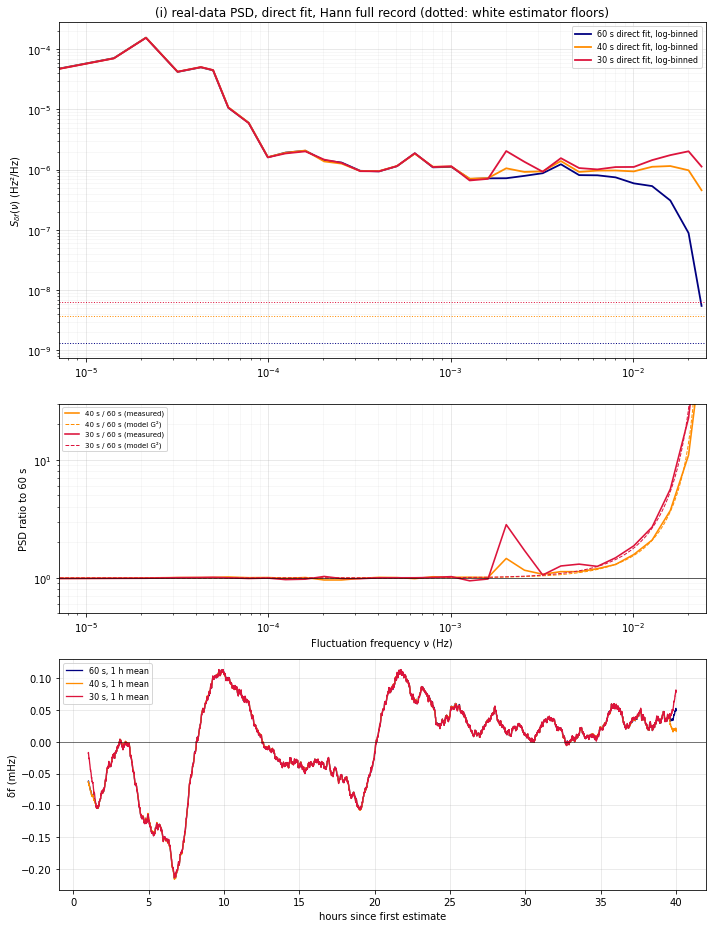

In [30]:
# (5) real-data PSDs with the primary conventions, and agreement within estimator uncertainty
PSD_I = {}
for w in WINS_I:
    e = REAL_I[w]; fs_w = 1/np.median(np.diff(e['t']))
    nu_w, S_w = periodogram(e['d'], fs=fs_w, window='hann', detrend=False)
    PSD_I[w] = dict(nu=nu_w, S=S_w, lb=tuple(log_bin(nu_w, S_w)), fs=fs_w,
                    floor=2*SYN_I[w]['stat'][1]**2/fs_w)            # white estimator floor from the stationary σ

t60i = REAL_I[60]['t']
slow_i = {w: uniform_filter1d(np.interp(t60i, REAL_I[w]['t'], REAL_I[w]['d']), N_SLOW, mode='nearest') for w in WINS_I}
print(f"{'window':>7} | {'mean f (Hz)':>11} | {'std δf (mHz)':>12} | {'std 1 h means':>13} | {'1 h corr vs 60 s':>16} | "
      f"{'rms diff (mHz)':>14} | {'expected from σ (mHz)':>21}")
for w in WINS_I:
    e = REAL_I[w]
    sd = slow_i[w][N_SLOW:-N_SLOW]; s60 = slow_i[60][N_SLOW:-N_SLOW]
    exp_ = np.sqrt((SYN_I[60]['stat'][1]**2*max(60, STEP_P) + SYN_I[w]['stat'][1]**2*max(w, STEP_P))/3600) if w != 60 else 0
    print(f'{w:5d} s | {e["f"].mean():11.6f} | {e["d"].std()*1e3:12.4f} | {sd.std()*1e3:9.4f} mHz | '
          f'{np.corrcoef(sd, s60)[0, 1]:16.5f} | {np.sqrt(np.mean((sd - s60)**2))*1e3:14.5f} | {exp_*1e3:21.5f}')
print('(expected = white-noise estimator scatter only, 1 h averages of overlapping 20 s estimates; edges excluded)')

def bmean(w, lo, hi):
    p = PSD_I[w]; b = band(p['nu'], lo, hi); return p['S'][b].mean()
BANDS_I = ((PSD_I[60]['nu'][1], 1e-4), (1e-4, 1e-3), (1e-3, 5e-3), (5e-3, 1e-2), (1e-2, 1.5e-2), (1.5e-2, 2e-2), (2e-2, 0.025))
print(f"\n{'band (Hz)':>17} | " + ' | '.join(f'{w} s / 60 s (model)' for w in WINS_I[1:]) + ' | ' +
      ' | '.join(f'{w} s: S / floor' for w in WINS_I))
for lo, hi in BANDS_I:
    nc = np.sqrt(lo*hi)
    rat = [f'{bmean(w, lo, hi)/bmean(60, lo, hi):10.3f} ({(kernel_response_uniform(w, nc)/kernel_response_uniform(60, nc))[0]**2:5.2f})'
           for w in WINS_I[1:]]
    snr_ = [f'{bmean(w, lo, hi)/PSD_I[w]["floor"]:13.0f}' for w in WINS_I]
    print(f'{lo:.1e}-{hi:.1e} | ' + ' | '.join(rat) + ' | ' + ' | '.join(snr_))
print('white estimator floors 2σ²/f_s: ' + ', '.join(f'{w} s {PSD_I[w]["floor"]:.2e}' for w in WINS_I) + ' Hz²/Hz')

fig, ax = plt.subplots(3, 1, figsize=(10, 13), gridspec_kw=dict(height_ratios=[1.6, 1, 1.1]))
for w in WINS_I:
    nlb, slb, _ = PSD_I[w]['lb']
    ax[0].loglog(nlb, slb, color=coli[w], lw=1.8, label=f'{w} s direct fit, log-binned')
    ax[0].axhline(PSD_I[w]['floor'], color=coli[w], ls=':', lw=1)
    if w != 60:
        n60, s60_, _ = PSD_I[60]['lb']
        ax[1].semilogx(nlb, slb/np.interp(nlb, n60, s60_), color=coli[w], lw=1.6, label=f'{w} s / 60 s (measured)')
        ax[1].semilogx(nu_f, (kernel_response_uniform(w, nu_f)/kernel_response_uniform(60, nu_f))**2, '--', color=coli[w], lw=1,
                       label=f'{w} s / 60 s (model G²)')
ax[0].set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)'); ax[0].legend(fontsize=8)
ax[0].set_title('(i) real-data PSD, direct fit, Hann full record (dotted: white estimator floors)')
ax[1].axhline(1, color='k', lw=0.6); ax[1].set_ylim(0.5, 30); ax[1].set_yscale('log')
ax[1].set_ylabel('PSD ratio to 60 s'); ax[1].legend(fontsize=7)
for a in ax[:2]: a.set_xlim(PSD_I[60]['nu'][1], 0.025); a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12)
ax[1].set_xlabel('Fluctuation frequency ν (Hz)')
for w in WINS_I: ax[2].plot((t60i - T_REF)/3600, slow_i[w]*1e3, color=coli[w], lw=1.3, label=f'{w} s, 1 h mean')
ax[2].axhline(0, color='k', lw=0.5); ax[2].set_ylabel('δf (mHz)'); ax[2].set_xlabel('hours since first estimate')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**(i) result** (direct fit, 20 s step; validation only):

| | 60 s | 40 s | 30 s |
|---|---|---|---|
| stationary bias / σ (mHz) | +0.0001 / 0.0058 | −0.0005 / 0.0097 | −0.0002 / 0.0127 |
| G at 10⁻⁴ Hz | 1.000 | 0.998 | 1.002 |
| Pb-like A_rec/A_inj | 1.000 | 0.999 | 0.999 |
| −10% / 50% point | 5.3 / 13.2 mHz | 8.0 / 20.1 mHz | 10.7 / > 24 mHz |
| G at 10 / 20 mHz | 0.69 / 0.14 | 0.85 / 0.50 | 0.91 / 0.68 |
| white estimator floor 2σ²/f_s | 1.3e-9 | 3.7e-9 | 6.4e-9 Hz²/Hz |

1. **Low ν and multi-hour evolution agree within estimator uncertainty.** Mean f is 0.748876 Hz for all
   three. PSD ratio to 60 s: 1.002 / 0.973 (7 µHz–0.1 mHz) and 1.002 / 1.003 (0.1–1 mHz) for 40 / 30 s.
   1 h means correlate at 0.99997 / 0.99989 with rms differences 0.0005 / 0.0010 mHz, below the
   0.0013 / 0.0014 mHz expected from the stationary-tone σ alone.
2. **High ν follows the transfer functions.** PSD ratio to 60 s at 10–15 mHz: 2.0 / 2.6 (model
   1.96 / 2.44); at 15–20 mHz: 5.1 / 8.7 (model 5.0 / 8.0). The extra power in the shorter windows is
   the signal the 60 s window attenuates. Measured PSD / white floor at 15–20 mHz: 173 / 318 / 314; at
   20–25 mHz: 17 / 168 / 230.
3. **Unexplained mid-band excess in the shorter windows.** At 1–5 mHz the ratio to 60 s is 1.14 (40 s)
   and 1.40 (30 s) against a model 1.02–1.03, concentrated in a peak near 2.2 mHz (30 s: 13.9× the local
   median, 2.18 mHz; weaker at 40 s). It is not predicted by the transfer function or the white-noise
   floor. An aliased beat with the rotation harmonics was checked (2.25 mHz expected) and does not match;
   the origin is not established.
4. **Trade-off:** from 60 → 40 → 30 s the scatter grows ×1.7 / ×2.2 and the −10% bandwidth grows ×1.5 /
   ×2.0. All three remain far above their white floors everywhere they have appreciable gain.

**(j) The ~2.2 mHz feature: rotor content or estimator coupling?** Diagnostic only; nothing downstream changes.

Uses the (i) direct-fit series (60 / 40 / 30 s, 20 s step, 1–40 h). (1) peak in the unbinned Hann
periodograms over 1.5–3 mHz; (2) persistence in four contiguous sections; (3) spectra of the 40 s fit's
nuisance quantities (amplitude, c₀, c₁, residual rms), re-evaluated at the already-estimated f; (4)
observed amplitude ratios between windows vs the measured transfer functions; (5) which optical
components could alias onto the peak through the 20 s sampling, checked in the 16 Hz LES spectrum.
Amplitudes are least-squares sinusoid fits at a fixed frequency; "control" = the median amplitude at
frequencies 1.5–3 mHz more than 0.1 mHz from the peak.

(1) unbinned Hann periodogram, 1.5-3 mHz
  60 s: peak at 2.3433 mHz (bin 329), S = 4.53e-06 Hz²/Hz =   7.8x band median
  40 s: peak at 2.1795 mHz (bin 306), S = 4.50e-06 Hz²/Hz =   6.7x band median
  30 s: peak at 2.1792 mHz (bin 306), S = 1.07e-05 Hz²/Hz =  13.7x band median
  bin spacing 1/T = 7.12 µHz; reference frequency NU_PK = 2.1792 mHz (30 s peak)

(1)/(4) sinusoid amplitude at NU_PK, full record, vs transfer function
 window |  A (mHz) | control (mHz) | A/control | A / A_60 | G/G_60 at NU_PK
   60 s |  0.00690 |       0.00314 |       2.2 |     1.00 |           1.000
   40 s |  0.01098 |       0.00329 |       3.3 |     1.59 |           1.012
   30 s |  0.01631 |       0.00361 |       4.5 |     2.36 |           1.013
  measured G at NU_PK: 60 s 0.983, 40 s 0.995, 30 s 0.996
  genuine modulation aliasing onto NU_PK (20 s sampling), model G at k·50 mHz ± NU_PK:
     47.821 mHz: 60 s +0.036, 40 s -0.084, 30 s -0.002
     52.179 mHz: 60 s +0.027, 40 s -0.064, 30 s -0.050
     97.82

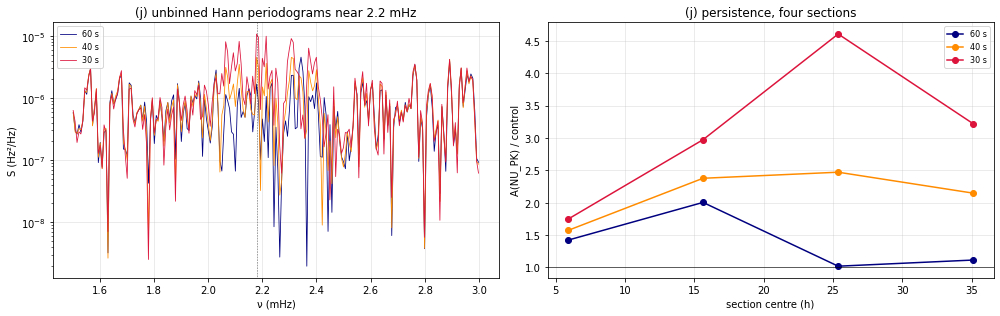

In [31]:
# (1) peak, (2) persistence, (4) window dependence
def sine_amp(t, d, nu):
    M = np.c_[np.ones_like(t), np.sin(2*np.pi*nu*t), np.cos(2*np.pi*nu*t)]
    b = np.linalg.lstsq(M, d, rcond=None)[0]; return np.hypot(b[1], b[2])

def amp_and_control(t, d, nu0, lo=1.5e-3, hi=3e-3, step=None):
    step = step or 1/(t[-1] - t[0])
    ctrl = [sine_amp(t, d, v) for v in np.arange(lo, hi, step) if abs(v - nu0) > 1e-4]
    return sine_amp(t, d, nu0), np.median(ctrl)

print('(1) unbinned Hann periodogram, 1.5-3 mHz')
PK_J = {}
for w in WINS_I:
    nu_w, S_w = PSD_I[w]['nu'], PSD_I[w]['S']; b = band(nu_w, 1.5e-3, 3e-3)
    j = np.flatnonzero(b)[np.argmax(S_w[b])]
    PK_J[w] = (nu_w[j], S_w[j], S_w[j]/np.median(S_w[b]))
    print(f'  {w:2d} s: peak at {nu_w[j]*1e3:.4f} mHz (bin {j}), S = {S_w[j]:.2e} Hz²/Hz = {PK_J[w][2]:5.1f}x band median')
NU_PK = PK_J[30][0]
print(f'  bin spacing 1/T = {PSD_I[60]["nu"][1]*1e6:.2f} µHz; reference frequency NU_PK = {NU_PK*1e3:.4f} mHz (30 s peak)')

print(f'\n(1)/(4) sinusoid amplitude at NU_PK, full record, vs transfer function')
print(f"{'window':>7} | {'A (mHz)':>8} | {'control (mHz)':>13} | {'A/control':>9} | {'A / A_60':>8} | {'G/G_60 at NU_PK':>15}")
A_J = {}
for w in WINS_I:
    e = REAL_I[w]; A_J[w] = amp_and_control(e['t'], e['d'], NU_PK)
G_at = {w: np.interp(NU_PK, NU_H, SYN_I[w]['tf'][:, 0]) for w in WINS_I}
for w in WINS_I:
    a, c = A_J[w]
    print(f'{w:5d} s | {a*1e3:8.5f} | {c*1e3:13.5f} | {a/c:9.1f} | {a/A_J[60][0]:8.2f} | {G_at[w]/G_at[60]:15.3f}')
print(f'  measured G at NU_PK: ' + ', '.join(f'{w} s {G_at[w]:.3f}' for w in WINS_I))
print('  genuine modulation aliasing onto NU_PK (20 s sampling), model G at k·50 mHz ± NU_PK:')
for kk in (1, 2):
    for sgn in (-1, 1):
        v = kk/STEP_P + sgn*NU_PK
        print(f'    {v*1e3:7.3f} mHz: ' + ', '.join(f'{w} s {kernel_response_uniform(w, v)[0]:+.3f}' for w in WINS_I))

print('\n(2) persistence: A(NU_PK) / control in four contiguous sections')
edges_h = np.linspace(WIN_H[0], WIN_H[1], 5)
print(f"{'section (h)':>12} | " + ' | '.join(f'{w:>2d} s A (mHz), A/ctrl' for w in WINS_I))
SEC_J = {}
for a_, b_ in zip(edges_h[:-1], edges_h[1:]):
    row = []
    for w in WINS_I:
        e = REAL_I[w]; h = (e['t'] - T_REF)/3600; m = (h >= a_) & (h < b_)
        A, c = amp_and_control(e['t'][m], e['d'][m] - e['d'][m].mean(), NU_PK)
        SEC_J[(a_, w)] = (A, c); row.append(f'{A*1e3:9.5f}, {A/c:5.1f}x')
    print(f'{a_:5.1f}-{b_:5.1f} | ' + ' | '.join(f'{r:>20}' for r in row))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for w in WINS_I:
    b = band(PSD_I[w]['nu'], 1.5e-3, 3e-3)
    ax[0].semilogy(PSD_I[w]['nu'][b]*1e3, PSD_I[w]['S'][b], color=coli[w], lw=0.8, label=f'{w} s')
    ax[1].plot([(a_ + b_)/2 for a_, b_ in zip(edges_h[:-1], edges_h[1:])],
               [SEC_J[(a_, w)][0]/SEC_J[(a_, w)][1] for a_ in edges_h[:-1]], 'o-', color=coli[w], label=f'{w} s')
ax[0].axvline(NU_PK*1e3, color='k', lw=0.6, ls=':'); ax[0].set_xlabel('ν (mHz)'); ax[0].set_ylabel('S (Hz²/Hz)')
ax[0].set_title('(j) unbinned Hann periodograms near 2.2 mHz'); ax[0].legend(fontsize=8)
ax[1].axhline(1, color='k', lw=0.6); ax[1].set_xlabel('section centre (h)'); ax[1].set_ylabel('A(NU_PK) / control')
ax[1].set_title('(j) persistence, four sections'); ax[1].legend(fontsize=8)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

[cache] j_nuis: loaded
(3) 40 s direct fit: sinusoid amplitude at NU_PK = 2.1792 mHz relative to control, and periodogram peak/median
  frequency δf        : A/control   3.3x;  periodogram at NU_PK (±1 bin)   6.7x band median
  amplitude √(A²+B²)  : A/control   0.6x;  periodogram at NU_PK (±1 bin)   2.2x band median
  c0 (offset)         : A/control   0.6x;  periodogram at NU_PK (±1 bin)   1.3x band median
  c1 (slope)          : A/control   0.9x;  periodogram at NU_PK (±1 bin)   1.2x band median
  residual rms        : A/control   1.9x;  periodogram at NU_PK (±1 bin)   7.5x band median


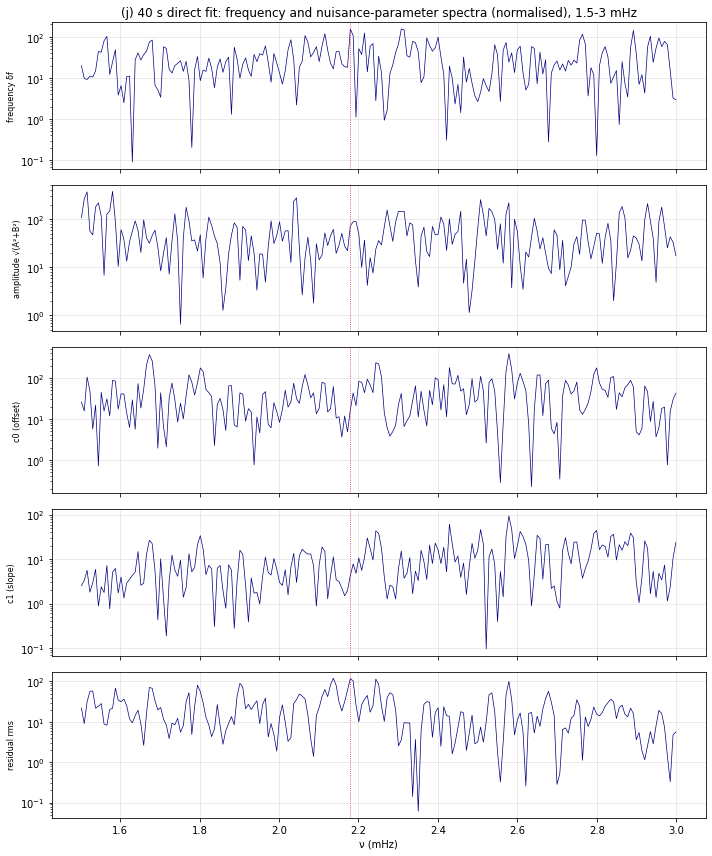

In [32]:
# (3) nuisance quantities of the 40 s direct fit, re-evaluated at the already-estimated frequency
def fit_params(seg, fsx, f):
    n = len(seg); tt = (np.arange(n) - (n - 1)/2)/fsx
    M = np.c_[np.ones(n), tt, np.cos(2*np.pi*f*tt), np.sin(2*np.pi*f*tt)]
    b = np.linalg.lstsq(M, seg, rcond=None)[0]
    return b[0], b[1], np.hypot(b[2], b[3]), (seg - M @ b).std()

def _j_nuis():
    w = 40; nw_ = int(w*fs16); e = REAL_I[40]; out = []
    for tc, f in zip(e['t'], e['f']):
        i = int(round((tc - w/2 - t16[0])*fs16))
        out.append(fit_params(y16[i:i+nw_], fs16, f*DIVISOR))
    return np.array(out)
NUIS_J = cached('j_nuis', ('v1', DATA_FP, 40, STEP_P), _j_nuis)

t40 = REAL_I[40]['t']
series_j = {'frequency δf': REAL_I[40]['d'], 'amplitude √(A²+B²)': NUIS_J[:, 2], 'c0 (offset)': NUIS_J[:, 0],
            'c1 (slope)': NUIS_J[:, 1], 'residual rms': NUIS_J[:, 3]}
print(f'(3) 40 s direct fit: sinusoid amplitude at NU_PK = {NU_PK*1e3:.4f} mHz relative to control, and periodogram peak/median')
fig, ax = plt.subplots(len(series_j), 1, figsize=(10, 12), sharex=True)
for a, (name, x) in zip(ax, series_j.items()):
    z = (x - x.mean())/x.std()
    A, c = amp_and_control(t40, z, NU_PK)
    nu_z, S_z = periodogram(z, fs=1/STEP_P, window='hann', detrend=False)
    b = band(nu_z, 1.5e-3, 3e-3); jj = np.argmin(abs(nu_z - NU_PK))
    loc = S_z[jj-1:jj+2].max()/np.median(S_z[b])
    print(f'  {name:20s}: A/control {A/c:5.1f}x;  periodogram at NU_PK (±1 bin) {loc:5.1f}x band median')
    a.semilogy(nu_z[b]*1e3, S_z[b], color='navy', lw=0.7); a.axvline(NU_PK*1e3, color='crimson', lw=0.8, ls=':')
    a.set_ylabel(name, fontsize=8); a.grid(alpha=.3)
ax[0].set_title('(j) 40 s direct fit: frequency and nuisance-parameter spectra (normalised), 1.5-3 mHz')
ax[-1].set_xlabel('ν (mHz)')
plt.tight_layout(); plt.show()

optical line f_L = 1.497752 Hz; 20 s sampling: offsets D = k·50 mHz ± 2.1792 mHz alias onto NU_PK
rotation-harmonic beats: |0f_rot - f_L| -> 2.2483 mHz, |1f_rot - f_L| -> 1.1242 mHz, |3f_rot - f_L| -> 1.1242 mHz, |4f_rot - f_L| -> 2.2483 mHz, |5f_rot - f_L| -> 3.3725 mHz, |6f_rot - f_L| -> 4.4966 mHz

952 optical components > 30x local floor (0.01-8 Hz); strongest 15, and every one aliasing within 21 µHz of NU_PK:
    f (Hz) | power / line |  / floor | |f - f_L| (Hz) | alias (mHz) | match
   1.49782 |     5.45e+00 |    25905 |        0.00007 |      0.0682 | 
   1.49770 |     4.93e+00 |    23690 |        0.00005 |      0.0529 | 
   1.49778 |     4.28e+00 |    20347 |        0.00003 |      0.0325 | 
   1.49791 |     3.55e+00 |    17090 |        0.00015 |      0.1536 | 
   1.49788 |     3.43e+00 |    16307 |        0.00013 |      0.1323 | 
   1.49766 |     3.36e+00 |    16180 |        0.00010 |      0.0957 | 
   1.49783 |     3.06e+00 |    14579 |        0.00008 |      0.0824 | 
   1.4978

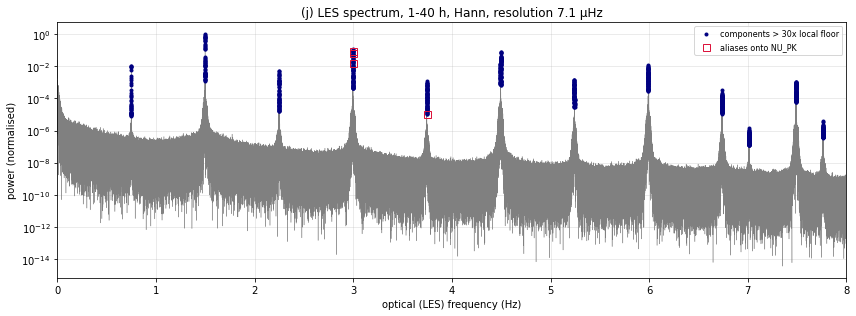

In [33]:
# (5) alias candidates and the underlying 16 Hz optical spectrum
from scipy.ndimage import median_filter
fs_e = 1/STEP_P
f_L = REAL_I[40]['f'].mean()*DIVISOR                     # optical line (Hz)
alias = lambda D: np.abs(D - np.round(D/fs_e)*fs_e)       # frequency at which a beat at offset D appears after 20 s sampling
print(f'optical line f_L = {f_L:.6f} Hz; 20 s sampling: offsets D = k·{fs_e*1e3:.0f} mHz ± {NU_PK*1e3:.4f} mHz alias onto NU_PK')
print('rotation-harmonic beats: ' + ', '.join(f'|{n}f_rot - f_L| -> {alias(abs(n*f_L/DIVISOR - f_L))*1e3:.4f} mHz'
                                           for n in (0, 1, 3, 4, 5, 6)))

m_opt = (t16 >= T_REF + WIN_H[0]*3600) & (t16 <= T_REF + WIN_H[1]*3600)
xo = y16[m_opt] - y16[m_opt].mean()
fo = np.fft.rfftfreq(len(xo), 1/fs16); Po = np.abs(np.fft.rfft(xo*np.hanning(len(xo))))**2
floor_o = median_filter(Po, size=2001, mode='nearest')
pk = np.flatnonzero((Po[1:-1] > Po[:-2]) & (Po[1:-1] >= Po[2:]) & (Po[1:-1] > 30*floor_o[1:-1])) + 1
pk = pk[fo[pk] > 0.01]
tol = 3*PSD_I[40]['nu'][1]                                  # 3 bins of the 20 s-series periodogram
rows = sorted(((fo[i], Po[i]/Po[np.argmin(abs(fo - f_L))], Po[i]/floor_o[i], alias(abs(fo[i] - f_L))) for i in pk),
              key=lambda r: -r[1])
print(f'\n{len(pk)} optical components > 30x local floor (0.01-8 Hz); strongest 15, and every one aliasing within '
      f'{tol*1e6:.0f} µHz of NU_PK:')
print(f"{'f (Hz)':>10} | {'power / line':>12} | {'/ floor':>8} | {'|f - f_L| (Hz)':>14} | {'alias (mHz)':>11} | match")
shown = 0
for f_, rl, rf, al in rows:
    match = abs(al - NU_PK) < tol
    if shown < 15 or match:
        print(f'{f_:10.5f} | {rl:12.2e} | {rf:8.0f} | {abs(f_ - f_L):14.5f} | {al*1e3:11.4f} | {"<-- MATCH" if match else ""}')
        shown += 1

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.semilogy(fo, Po/Po.max(), color='gray', lw=0.4)
ax.semilogy(fo[pk], Po[pk]/Po.max(), 'o', ms=3, color='navy', label='components > 30x local floor')
mt = [i for i in pk if abs(alias(abs(fo[i] - f_L)) - NU_PK) < tol]
ax.semilogy(fo[mt], Po[mt]/Po.max(), 's', ms=7, mfc='none', color='crimson', label='aliases onto NU_PK')
ax.set_xlim(0, fs16/2); ax.set_xlabel('optical (LES) frequency (Hz)'); ax.set_ylabel('power (normalised)')
ax.set_title(f'(j) LES spectrum, {WIN_H[0]}-{WIN_H[1]} h, Hann, resolution {fo[1]*1e6:.1f} µHz')
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**(j) result** (diagnostic only; 40 s working configuration unchanged):
1. **Frequency:** the 40 s and 30 s peaks are in the same bin, 2.1795 / 2.1792 mHz (6.7× / 13.7× the
   1.5–3 mHz median). At 60 s the band maximum is elsewhere (2.343 mHz), and the sinusoid amplitude at
   2.179 mHz is only 2.2× control (40 s 3.3×, 30 s 4.5×).
2. **Persistence:** present in all four ~10 h sections for 40 s (1.6–2.5× control) and 30 s (1.7–4.6×);
   for 60 s, 1.4–2.0× in the first half and ~1.0× in the second. Not confined to one stretch.
3. **Nuisance quantities (40 s):** the **fit residual rms** has a matching feature (periodogram 7.5× the
   band median at the peak; sinusoid 1.9× control). Fitted amplitude 2.2× (sinusoid 0.6×), c₀ and c₁ ≈
   1×: no clear feature.
4. **Window dependence:** amplitude ratio to 60 s is 1.59 (40 s) and 2.36 (30 s), whereas the measured
   transfer functions predict 1.01 for genuine modulation at this frequency. Genuine modulation near
   k·50 mHz ± 2.18 mHz aliasing through the 20 s sampling would be passed at |G| ≤ 0.08 and cannot
   produce this growth.
5. **Alias:** with 20 s sampling, a beat at offset D appears at |D − k·50 mHz|. The optical line's own
   second harmonic (2f_L ≈ 2.9956 Hz, the 4× rotation component, ~0.5× the line power) sits at
   D = f_L ≈ 1.4978 Hz from the line, which aliases to |f_L − 1.5 Hz| = 2.17–2.20 mHz for the measured
   harmonic components. The earlier 2.25 mHz estimate used the *mean* f_L; the spectrum is dominated by
   the line's most occupied frequency (≈ 1.49782 Hz). Leakage of that harmonic into an untapered fit
   scales roughly as 1/(π × offset in bins): predicted 2.0 : 1.5 : 1 for 30 : 40 : 60 s vs observed
   2.36 : 1.59 : 1.

**Classification: consistent with estimator/fit coupling or aliasing.** The feature's growth with
shorter windows contradicts the measured transfer function for genuine modulation. Its frequency matches
the aliased beat between the line and its second harmonic, and it appears in the fit residual. This is
consistent with harmonic leakage into the untapered single-sinusoid fit, not a demonstration of it; a
genuine component at 2.18 mHz underneath the leakage is not excluded (the 60 s series shows a weaker
excess in part of the record).

**(j2) Falsification test of the harmonic-leakage mechanism.** Diagnostic only.

Two-harmonic direct fit, $y = c_0 + c_1 t + A_1\cos 2\pi f t + B_1\sin 2\pi f t + A_2\cos 4\pi f t + B_2\sin 4\pi f t$,
with **one** nonlinear parameter f (the harmonic is fixed at exactly 2f); same seed bin, ±1 bin bounds,
band and windows as the single-harmonic fit, on the same real data at 60 / 40 / 30 s, 20 s step.
Hypothesis: if the 2.18 mHz feature is mainly second-harmonic leakage into the single-sinusoid fit,
fitting the harmonic should strongly suppress it and its growth with shorter windows.

[cache] j2_real: computed and saved
(1) mean f and std δf;  (2) low-ν agreement, two-harmonic vs single-harmonic
 window | mean f 1h (Hz) | mean f 2h (Hz) | std δf 1h | std δf 2h | PSD 2h/1h <0.1 mHz | 1 h corr | 1 h rms diff
   60 s |       0.748876 |       0.748876 | 0.1296 mHz | 0.1292 mHz |             0.9993 |  0.99997 |  0.00050 mHz
   40 s |       0.748876 |       0.748876 | 0.1705 mHz | 0.1691 mHz |             0.9979 |  0.99987 |  0.00107 mHz
   30 s |       0.748876 |       0.748876 | 0.2022 mHz | 0.1986 mHz |             1.0013 |  0.99969 |  0.00166 mHz

(3)-(5) the 2.1792 mHz component: unbinned PSD (peak in 1.5-3 mHz, value at NU_PK ±1 bin) and sinusoid amplitude
 window |  model | 1.5-3 mHz peak (mHz, x median) | at NU_PK (x median) |  A (mHz) | A/control | A/A_60
   60 s |     1h |       2.3433 (  7.8x)          |                 2.9 |  0.00690 |       2.2 |   1.00
   40 s |     1h |       2.1795 (  6.7x)          |                 6.7 |  0.01098 |       3.3 |   1.59
   

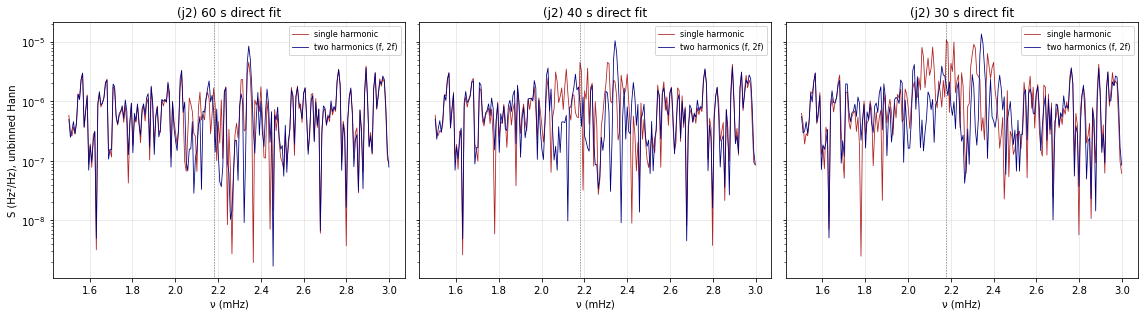

In [34]:
def fit_direct(x, fsx, f_guess, df_bin, n_harm):
    """direct fit with n_harm harmonics locked at k·f (one nonlinear parameter); returns (f, residual rms)"""
    n = len(x); tt = (np.arange(n) - (n - 1)/2)/fsx; base = np.c_[np.ones(n), tt]
    def design(f):
        return np.c_[base] if n_harm == 0 else np.column_stack(
            [base] + [g(2*np.pi*h*f*tt) for h in range(1, n_harm + 1) for g in (np.cos, np.sin)])
    def resid(f):
        M = design(f); return x - M @ np.linalg.lstsq(M, x, rcond=None)[0]
    f = minimize_scalar(lambda f: (r := resid(f)) @ r, bounds=(f_guess - df_bin, f_guess + df_bin),
                        method='bounded', options=dict(xatol=1e-9)).x
    return f, resid(f).std()

def _j2_real():
    out = {}
    for w in WINS_I:
        e = REAL_I[w]; nw_ = int(w*fs16); rows_ = []
        for tc, f1 in zip(e['t'], e['f']):
            i = int(round((tc - w/2 - t16[0])*fs16)); seg = y16[i:i+nw_]
            trk = np.interp(tc, T, FR)*DIVISOR
            fraw, _, _ = peak_in_band(seg, fs16, max(trk*0.85, 0.02), trk*1.10)
            f2, r2 = fit_direct(seg, fs16, fraw, fs16/nw_, 2)
            _, _, _, r1 = fit_params(seg, fs16, f1*DIVISOR)              # single-harmonic residual at its own f
            rows_.append((f2/DIVISOR, r2, r1))
        a = np.array(rows_)
        out[w] = dict(f=a[:, 0], d=a[:, 0] - a[:, 0].mean(), r2=a[:, 1], r1=a[:, 2])
    return out
H2 = cached('j2_real', ('v1', DATA_FP, WINS_I, STEP_P), _j2_real)

def hann_psd(d): return periodogram(d, fs=1/STEP_P, window='hann', detrend=False)
print(f"(1) mean f and std δf;  (2) low-ν agreement, two-harmonic vs single-harmonic")
print(f"{'window':>7} | {'mean f 1h (Hz)':>14} | {'mean f 2h (Hz)':>14} | {'std δf 1h':>9} | {'std δf 2h':>9} | "
      f"{'PSD 2h/1h <0.1 mHz':>18} | {'1 h corr':>8} | {'1 h rms diff':>12}")
for w in WINS_I:
    d1, d2 = REAL_I[w]['d'], H2[w]['d']
    nu_, S1 = hann_psd(d1); _, S2 = hann_psd(d2); b = band(nu_, nu_[1], 1e-4)
    s1, s2 = (uniform_filter1d(x, N_SLOW, mode='nearest')[N_SLOW:-N_SLOW] for x in (d1, d2))
    print(f'{w:5d} s | {REAL_I[w]["f"].mean():14.6f} | {H2[w]["f"].mean():14.6f} | {d1.std()*1e3:6.4f} mHz | {d2.std()*1e3:6.4f} mHz | '
          f'{S2[b].mean()/S1[b].mean():18.4f} | {np.corrcoef(s1, s2)[0, 1]:8.5f} | {np.sqrt(np.mean((s1 - s2)**2))*1e3:8.5f} mHz')

print(f'\n(3)-(5) the {NU_PK*1e3:.4f} mHz component: unbinned PSD (peak in 1.5-3 mHz, value at NU_PK ±1 bin) and sinusoid amplitude')
print(f"{'window':>7} | {'model':>6} | {'1.5-3 mHz peak (mHz, x median)':>30} | {'at NU_PK (x median)':>19} | {'A (mHz)':>8} | {'A/control':>9} | {'A/A_60':>6}")
AJ2 = {}
for nh, src_ in (('1h', REAL_I), ('2h', H2)):
    for w in WINS_I:
        d = src_[w]['d']; t_ = REAL_I[w]['t']; nu_, S = hann_psd(d); b = band(nu_, 1.5e-3, 3e-3); med = np.median(S[b])
        jp = np.flatnonzero(b)[np.argmax(S[b])]; jj = np.argmin(abs(nu_ - NU_PK))
        AJ2[(nh, w)] = amp_and_control(t_, d, NU_PK)
        A, c = AJ2[(nh, w)]
        print(f'{w:5d} s | {nh:>6} | {nu_[jp]*1e3:12.4f} ({S[jp]/med:5.1f}x)          | {S[jj-1:jj+2].max()/med:19.1f} | '
              f'{A*1e3:8.5f} | {A/c:9.1f} | {A/AJ2[(nh, 60)][0] if w != 60 else 1.0:6.2f}')

print(f'\n(6) residual rms: mean level and its feature at NU_PK')
print(f"{'window':>7} | {'mean resid 1h':>13} | {'mean resid 2h':>13} | {'1h: A/ctrl, PSD x med':>21} | {'2h: A/ctrl, PSD x med':>21}")
for w in WINS_I:
    t_ = REAL_I[w]['t']; out_ = []
    for r in (H2[w]['r1'], H2[w]['r2']):
        z = (r - r.mean())/r.std(); A, c = amp_and_control(t_, z, NU_PK)
        nu_, S = hann_psd(z); b = band(nu_, 1.5e-3, 3e-3); jj = np.argmin(abs(nu_ - NU_PK))
        out_.append(f'{A/c:6.1f}, {S[jj-1:jj+2].max()/np.median(S[b]):6.1f}')
    print(f'{w:5d} s | {H2[w]["r1"].mean():13.3f} | {H2[w]["r2"].mean():13.3f} | {out_[0]:>21} | {out_[1]:>21}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for a, w in zip(ax, WINS_I):
    for d, lab, col in ((REAL_I[w]['d'], 'single harmonic', 'firebrick'), (H2[w]['d'], 'two harmonics (f, 2f)', 'navy')):
        nu_, S = hann_psd(d); b = band(nu_, 1.5e-3, 3e-3)
        a.semilogy(nu_[b]*1e3, S[b], color=col, lw=0.8, label=lab)
    a.axvline(NU_PK*1e3, color='k', lw=0.6, ls=':'); a.set_title(f'(j2) {w} s direct fit'); a.set_xlabel('ν (mHz)')
    a.grid(alpha=.3); a.legend(fontsize=8)
ax[0].set_ylabel('S (Hz²/Hz), unbinned Hann')
plt.tight_layout(); plt.show()

**(j2) result** (diagnostic only; two-harmonic fit not adopted):
1. **Mean f** unchanged (0.748876 Hz, all windows); std δf slightly lower: 0.1292 / 0.1691 / 0.1986 mHz vs
   0.1296 / 0.1705 / 0.2022 (60 / 40 / 30 s).
2. **Low ν unchanged:** PSD ratio two/single-harmonic below 0.1 mHz 0.9993 / 0.9979 / 1.0013; 1 h means
   correlate at 0.99997 / 0.99987 / 0.99969 with rms differences 0.0005 / 0.0011 / 0.0017 mHz. The
   Pb-relevant series is not materially changed.
3. **The 2.18 mHz feature is suppressed.** Sinusoid amplitude at 2.1792 mHz falls from 0.0069 / 0.0110 /
   0.0163 mHz (2.2 / 3.3 / 4.5× control) to 0.0034 / 0.0029 / 0.0037 mHz (1.1 / 0.9 / 1.2× control,
   i.e. at the noise level).
4. **Its window dependence disappears:** A/A_60 = 1.00 / 0.84 / 1.10, vs 1.00 / 1.59 / 2.36 before.
5. **Residual rms:** its mean level drops ~26% (≈200 → ≈148 counts), so the harmonic carries a large part
   of what the single-sinusoid fit left unmodelled. The residual's own feature at 2.18 mHz, however, is
   **not** removed (periodogram 8.4 / 7.3 / 6.2× median vs 8.6 / 7.5 / 6.4× before), so it is not a
   signature of the frequency leakage and is not explained here.
6. **New observation:** with the harmonic fitted, a component at 2.3433 mHz becomes the band maximum in all
   three windows (sinusoid 2.0 / 2.3 / 2.7× control; 0.3–1.1× with the single-harmonic fit). Not
   interpreted.

**Outcome:** the prediction of the harmonic-leakage hypothesis held. Fitting the second harmonic removed
the 2.18 mHz frequency feature and its anomalous window dependence while leaving the low-frequency series
unchanged. A genuine rotor component at 2.18 mHz larger than ~1× the local noise is not supported in the
two-harmonic series. Open: the residual-rms feature at 2.18 mHz and the 2.34 mHz component.

## 2. Pb-212 signal

### 2.1 Decay timescale in Fourier space (shape only)

Where in ν the 10.6 h half-life sits. **Shape only:** no force, torque, I or δf amplitude is assumed.

A(t) = 2^(−t/T½), A0 = 1, on the 1–40 h timestamps of the primary 60 s track (§1.5) (t = 0 at the start of the interval;
that choice only rescales A and cancels in the normalisation). Spectral estimate as in §1.5: the
1–40 h mean subtracted (as for δf), one Hann periodogram over the full interval, same fs, `detrend=False`. Normalised by its
maximum over ν > 0.

Pb-212 half-life              = 10.6 h
mean lifetime tau = T½/ln 2   = 15.29 h   (decay rate 1/(2π tau) = 2.89e-06 Hz)
duration analysed             = 7020 x 20 s = 39.00 h
lowest nonzero ν              = 7.123e-06 Hz  (period 39.00 h)
Nyquist                       = 2.500e-02 Hz  (period 40 s)


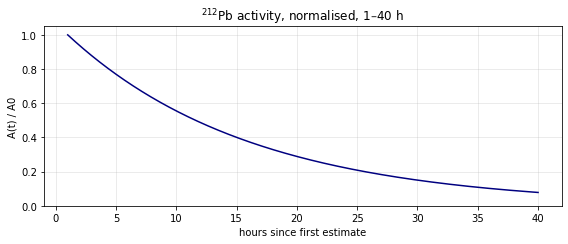

In [35]:
T_HALF_H = 10.6                                  # Pb-212 half-life (h)
TAU_PB_H = T_HALF_H/np.log(2)                   # mean lifetime (h)
t_pb = (t_p - t_p[0])/3600                       # h, 1-40 h timestamps of the primary track (1.5)
A_pb = 2**(-t_pb/T_HALF_H)                       # A0 = 1, dimensionless

nu_pb, P_pb = periodogram(A_pb - A_pb.mean(), fs=fs_p, window='hann', detrend=False)
P_norm = P_pb[1:]/P_pb[1:].max()

print(f'Pb-212 half-life              = {T_HALF_H:.1f} h')
print(f'mean lifetime tau = T½/ln 2   = {TAU_PB_H:.2f} h   (decay rate 1/(2π tau) = {1/(2*np.pi*TAU_PB_H*3600):.2e} Hz)')
print(f'duration analysed             = {len(t_pb)} x {1/fs_p:.0f} s = {len(t_pb)/fs_p/3600:.2f} h')
print(f'lowest nonzero ν              = {nu_pb[1]:.3e} Hz  (period {1/nu_pb[1]/3600:.2f} h)')
print(f'Nyquist                       = {fs_p/2:.3e} Hz  (period {2/fs_p:.0f} s)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot((t_p - T_REF)/3600, A_pb, color='navy', lw=1.5)
ax.set_xlabel('hours since first estimate'); ax.set_ylabel('A(t) / A0')
ax.set_title('$^{212}$Pb activity, normalised, 1–40 h')
ax.set_ylim(0, 1.05); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

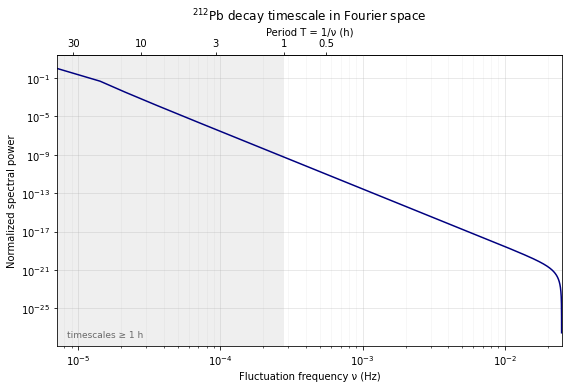

In [36]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_pb[1:], P_norm, color='navy', lw=1.5)
ax.set_xlim(nu_pb[1], fs_p/2)
ax.axvspan(nu_pb[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Normalized spectral power')
ax.set_title('$^{212}$Pb decay timescale in Fourier space')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)

def nu_to_h(x):
    with np.errstate(divide='ignore'): return 1/(3600*x)
top = ax.secondary_xaxis('top', functions=(nu_to_h, nu_to_h))
top.set_xticks([0.5, 1, 3, 10, 30]); top.set_xticklabels(['0.5', '1', '3', '10', '30'])
top.xaxis.set_minor_locator(plt.NullLocator())
top.set_xlabel('Period T = 1/ν (h)')
plt.tight_layout(); plt.show()

**Interpretation.**
- A normalised spectral **shape**, not a predicted signal: no units, no amplitude.
- The 10.6 h decay (τ = 15.3 h) sets the slow time dependence of the expected recoil signal. Its natural
  rate, 1/(2πτ) ≈ 2.9e-6 Hz, is below the lowest ν here, 1/(39 h) ≈ 7.1e-6 Hz, set by the observation interval.
- So within 1–40 h the decay is a slow drift: 95% of its power in the lowest bin (7.1 µHz), 99.9% in the
  lowest three (≤ 21 µHz, timescales ≳ 13 h). The ν⁻⁶ fall-off above is the Hann window's roll-off, not the decay.
- That is the same ν range as the red component of the measured frequency noise (§1.5).
- The absolute Pb-212 recoil spectrum (Hz²/Hz) comes later, after converting the expected recoil
  force/torque into a rotor-frequency response.

### 2.2 Expected recoil signal in frequency-noise units

Expected Pb-212 recoil force → rotor-frequency signal, as a spectrum in Hz²/Hz on the §1.5 measured PSD.

- Linear drag (supported by the exponential spin-down): $I\dot\omega = -\gamma\omega$, $\gamma = I/\tau_{\rm mech}$
  (N·m·s; a drag coefficient, not the rate `GAMMA` = 1/τ used in §3–4).
- Recoil torque $\tau_0 = rF_0$; quasi-static shift $\Delta f_0 = \tau_0/(2\pi\gamma)$.
- $\delta f_{\rm Pb}(t) = \Delta f_0\,e^{-\lambda t}$, $\lambda = \ln 2/T_{1/2}$, on the §1.5 timestamps (60 s / 20 s track, 1–40 h).
- **Assumption: F0 = 5.1 fN is the recoil force at t = 0, the start of the analysed 1–40 h interval.**
  For any other origin the amplitude scales by $e^{-\lambda t_{\rm start}}$.
- I = 1.1e-11 kg·m² (§0).
- Spectrum of the expected signal: mean subtracted, one full-record **rectangular (no-taper)** periodogram,
  `detrend=False`, one-sided density, same ν grid as §1.5. Absolute level from Δf0; not matched to the data.
  Not Hann: on this deterministic signal the Hann window imposes its own ν⁻⁶ roll-off (diagnostic below),
  whereas the rectangular record keeps the exponential's ν⁻² slope.
- **Signal-comparison overlay: both curves use the rectangular full-record periodogram** (measured: the
  §1.6(d) series). The Hann PSD of §1.5 remains the primary rotor-noise characterization; §1.6(d) shows
  its band level is robust to the window.

**This is a deterministic finite-record signal, not stationary noise.** Its "Hz²/Hz" is the periodogram
of this particular record: the level depends on the record length and window, and it is meaningful
only against a PSD computed over the same record.

**Quasi-static approximation.** The mechanical relaxation time (τ_mech ≈ 1.33 h) is much shorter than
the Pb-212 mean lifetime (≈ 15.3 h), so the rotor tracks the slowly decaying torque. The exact response
$I\dot\omega + \gamma\omega = \tau_0 e^{-\lambda t}$ can be included later as a correction (its driven
term is larger by $1/(1-\lambda\tau_{\rm mech}) \approx 1.10$, plus a start-up transient that depends on
the initial condition).

gamma = I/tau_mech        = 2.2974e-15 N m s
tau_0 = r F0 (r = 1.38 mm) = 7.0380e-18 N m
Delta_f0 (r = 1.38 mm)     = 4.8756e-04 Hz = 0.4876 mHz
Delta_f0 (r = 1.88 mm tip) = 6.6422e-04 Hz = 0.6642 mHz   (geometry comparison)
over 1-40 h: 0.4876 -> 0.0381 mHz


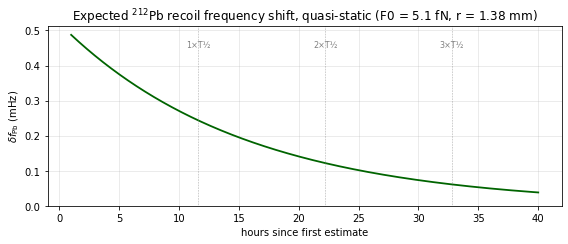

In [37]:
assert (I_TOTAL, TAU_S, R_EFF, R_TIP) == (1.1e-11, 79.8*60, 1.38e-3, 1.88e-3)   # section 0 constants

F0_PB = 5.1e-15                                   # N, initial recoil force
LAMBDA_PB = np.log(2)/(T_HALF_H*3600)             # 1/s  (T_HALF_H = 10.6 h, 2.1)
GAMMA_DRAG = I_TOTAL/TAU_S                        # N m s
TAU0_PB = R_EFF*F0_PB                             # N m
DF0_PB = TAU0_PB/(2*np.pi*GAMMA_DRAG)             # Hz, quasi-static
DF0_PB_TIP = R_TIP*F0_PB/(2*np.pi*GAMMA_DRAG)

t_rel = t_p - t_p[0]                              # s, §1.5 timestamps, t = 0 at the start of 1-40 h
df_pb = DF0_PB*np.exp(-LAMBDA_PB*t_rel)           # Hz
nu_pbs, S_pb = periodogram(df_pb - df_pb.mean(), fs=fs_p, window='hann', detrend=False)
assert np.allclose(nu_pbs, nu_p)                  # same ν grid as the measured PSD
S_pb_tip = S_pb*(R_TIP/R_EFF)**2

print(f'gamma = I/tau_mech        = {GAMMA_DRAG:.4e} N m s')
print(f'tau_0 = r F0 (r = 1.38 mm) = {TAU0_PB:.4e} N m')
print(f'Delta_f0 (r = 1.38 mm)     = {DF0_PB:.4e} Hz = {DF0_PB*1e3:.4f} mHz')
print(f'Delta_f0 (r = 1.88 mm tip) = {DF0_PB_TIP:.4e} Hz = {DF0_PB_TIP*1e3:.4f} mHz   (geometry comparison)')
print(f'over 1-40 h: {df_pb[0]*1e3:.4f} -> {df_pb[-1]*1e3:.4f} mHz')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot((t_p - T_REF)/3600, df_pb*1e3, color='darkgreen', lw=1.8)
for n in range(1, 4):
    h = (t_p[0] - T_REF)/3600 + n*T_HALF_H
    ax.axvline(h, color='gray', lw=0.6, ls=':'); ax.text(h, DF0_PB*1e3*0.97, f'{n}×T½', fontsize=8, color='gray', ha='center', va='top')
ax.set_xlabel('hours since first estimate'); ax.set_ylabel('$\\delta f_{\\rm Pb}$ (mHz)')
ax.set_title(f'Expected $^{{212}}$Pb recoil frequency shift, quasi-static (F0 = {F0_PB*1e15:.1f} fN, r = {R_EFF*1e3:.2f} mm)')
ax.set_ylim(0, DF0_PB*1e3*1.05); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

In [38]:
# expected recoil: rectangular full-record spectral density, absolute (from Δf0), + Parseval and slope checks
x_pb = df_pb - df_pb.mean()                               # mean subtracted, as for the measured δf
nu_pr, S_pb_rect = periodogram(x_pb, fs=fs_p, window='boxcar', detrend=False)    # Hz²/Hz, one-sided
assert np.allclose(nu_pr, nu_p)
S_pb_rect_tip = S_pb_rect*(R_TIP/R_EFF)**2
dnu = nu_p[1] - nu_p[0]                                   # = 1/T_record

ms_total = np.mean(df_pb**2)                              # mean square of δf_Pb over the record
ms_dc = df_pb.mean()**2                                   # removed by the mean subtraction
ms_ac = np.mean(x_pb**2)                                  # what the spectrum should contain
integral = S_pb_rect.sum()*dnu                            # Σ S Δν over all one-sided bins (DC, 0<ν<Nyq, Nyquist)
print('PARSEVAL (rectangular, one-sided density; DC and Nyquist bins not doubled by periodogram)')
print(f'  mean square of δf_Pb          = {ms_total:.6e} Hz²')
print(f'  - mean² (removed, DC)         = {ms_dc:.6e} Hz²')
print(f'  = mean square after mean sub. = {ms_ac:.6e} Hz²')
print(f'  Σ S Δν over all bins          = {integral:.6e} Hz²   (DC bin S[0] = {S_pb_rect[0]:.1e})')
print(f'  fractional difference         = {(integral - ms_ac)/ms_ac:+.2e}')
print(f'  of which in the lowest nonzero bin: {S_pb_rect[1]*dnu/ms_ac:.1%}, lowest 3: {S_pb_rect[1:4].sum()*dnu/ms_ac:.1%}')

for lo, hi in ((1e-4, 1e-3), (1e-3, 5e-3)):
    m = band(nu_p, lo, hi)
    print(f'  log-log slope {lo:.0e}-{hi:.0e} Hz: {np.polyfit(np.log10(nu_p[m]), np.log10(S_pb_rect[m]), 1)[0]:.2f}')

PARSEVAL (rectangular, one-sided density; DC and Nyquist bins not doubled by periodogram)
  mean square of δf_Pb          = 4.633944e-08 Hz²
  - mean² (removed, DC)         = 3.107814e-08 Hz²
  = mean square after mean sub. = 1.526130e-08 Hz²
  Σ S Δν over all bins          = 1.526130e-08 Hz²   (DC bin S[0] = 4.5e-36)
  fractional difference         = -4.34e-16
  of which in the lowest nonzero bin: 57.6%, lowest 3: 81.0%
  log-log slope 1e-04-1e-03 Hz: -2.00
  log-log slope 1e-03-5e-03 Hz: -1.98


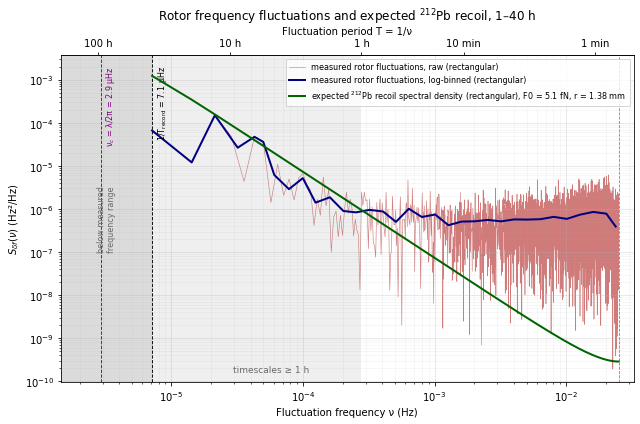

In [39]:
# Signal-comparison overlay: BOTH curves use the rectangular (no-taper) full-record periodogram.
# (The primary rotor-noise PSD, 1.5, stays Hann; 1.6(d) shows the band level is window-robust.)
nu_c_pb = LAMBDA_PB/(2*np.pi)
def nyq_display(S):
    # display only: periodogram leaves the Nyquist bin undoubled; x2 there gives the one-sided density
    S = S.copy(); S[-1] *= 2; return S
S_meas_ov, S_pb_ov = nyq_display(S_df_rect), nyq_display(S_pb_rect)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(nu_p[1:], S_meas_ov[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1,
          label='measured rotor fluctuations, raw (rectangular)')
ax.loglog(nu_lb, S_lb_rect, color='navy', lw=2.0, zorder=3, label='measured rotor fluctuations, log-binned (rectangular)')
ax.loglog(nu_p[1:], S_pb_ov[1:], color='darkgreen', lw=2.0, zorder=4,
          label=f'expected $^{{212}}$Pb recoil spectral density (rectangular), '
                f'F0 = {F0_PB*1e15:.1f} fN, r = {R_EFF*1e3:.2f} mm')
ax.set_ylim(S_meas_ov[1:].min()*0.5, max(S_meas_ov[1:].max(), S_pb_ov[1:].max())*3)
x_left = nu_c_pb*0.5
ax.set_xlim(x_left, fs_p/2*1.3)
ax.axvline(fs_p/2, color='gray', lw=0.8, ls='--')
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.axvspan(x_left, nu_p[1], color='gray', alpha=0.28, lw=0)
ax.text(np.sqrt(x_left*nu_p[1]), 0.5, 'below measured\nfrequency range', transform=ax.get_xaxis_transform(),
        rotation=90, ha='center', va='center', fontsize=8, color='dimgray')
for x, lab, col in ((nu_p[1], f'1/T$_{{\\rm record}}$ = {nu_p[1]*1e6:.1f} µHz', 'k'),
                    (nu_c_pb, f'ν$_c$ = λ/2π = {nu_c_pb*1e6:.1f} µHz', 'purple')):
    ax.axvline(x, color=col, lw=0.9, ls='--')
    ax.text(x*1.07, 0.97, lab, transform=ax.get_xaxis_transform(), rotation=90, va='top', fontsize=8, color=col)
ax.text(0.30, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency fluctuations and expected $^{{212}}$Pb recoil, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)
ax.legend(fontsize=8, loc='upper right')
top = ax.secondary_xaxis('top', functions=(inv, inv))
per = [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (10*3600, '10 h'), (100*3600, '100 h')]
top.set_xticks([p for p, _ in per]); top.set_xticklabels([l for _, l in per])
top.xaxis.set_minor_locator(plt.NullLocator()); top.set_xlabel('Fluctuation period T = 1/ν')
plt.tight_layout(); plt.show()

In [40]:
print('SUMMARY (quasi-static, t = 0 at the start of 1-40 h)')
print(f'  gamma          = {GAMMA_DRAG:.4e} N m s')
print(f'  tau_mech       = {TAU_S/60:.1f} min = {TAU_S/3600:.3f} h')
print(f'  F0             = {F0_PB:.2e} N')
print(f'  r              = {R_EFF:.2e} m   (tip {R_TIP:.2e} m)')
print(f'  tau_recoil_0   = {TAU0_PB:.4e} N m   (tip {R_TIP*F0_PB:.4e})')
print(f'  Delta_f0       = {DF0_PB:.4e} Hz = {DF0_PB*1e3:.4f} mHz   (tip {DF0_PB_TIP*1e3:.4f} mHz)')
print(f'  lambda         = {LAMBDA_PB:.4e} 1/s   (mean lifetime {1/LAMBDA_PB/3600:.2f} h)')
print(f'  half-life      = {T_HALF_H:.1f} h')
print(f'  nu_c = λ/2π    = {LAMBDA_PB/(2*np.pi):.3e} Hz;  1/T_record = {nu_p[1]:.3e} Hz')
print('\nexpected recoil (rectangular) vs measured, raw bins [measured Hann = primary; rectangular from 1.6(d)]:')
print(f"{'ν (µHz)':>8} | {'recoil':>9} | {'(tip)':>9} | {'meas Hann':>9} | {'ratio':>6} | {'meas rect':>9} | {'ratio':>6}")
for j in range(1, 7):
    print(f'{nu_p[j]*1e6:8.1f} | {S_pb_rect[j]:9.2e} | {S_pb_rect_tip[j]:9.2e} | {S_df[j]:9.2e} | {S_pb_rect[j]/S_df[j]:6.2f} | '
          f'{S_df_rect[j]:9.2e} | {S_pb_rect[j]/S_df_rect[j]:6.2f}')
for lo, hi in ((1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2)):
    bh = band(nu_p, lo, hi)
    print(f'band {lo:.0e}-{hi:.0e} Hz, ratio of means: recoil/meas Hann {S_pb_rect[bh].mean()/S_df[bh].mean():.3f}, '
          f'recoil/meas rect {S_pb_rect[bh].mean()/S_df_rect[bh].mean():.3f}')

SUMMARY (quasi-static, t = 0 at the start of 1-40 h)
  gamma          = 2.2974e-15 N m s
  tau_mech       = 79.8 min = 1.330 h
  F0             = 5.10e-15 N
  r              = 1.38e-03 m   (tip 1.88e-03 m)
  tau_recoil_0   = 7.0380e-18 N m   (tip 9.5880e-18)
  Delta_f0       = 4.8756e-04 Hz = 0.4876 mHz   (tip 0.6642 mHz)
  lambda         = 1.8164e-05 1/s   (mean lifetime 15.29 h)
  half-life      = 10.6 h
  nu_c = λ/2π    = 2.891e-06 Hz;  1/T_record = 7.123e-06 Hz

expected recoil (rectangular) vs measured, raw bins [measured Hann = primary; rectangular from 1.6(d)]:
 ν (µHz) |    recoil |     (tip) | meas Hann |  ratio | meas rect |  ratio
     7.1 |  1.23e-03 |  2.29e-03 |  3.02e-05 |  40.81 |  6.64e-05 |  18.58
    14.2 |  3.45e-04 |  6.41e-04 |  4.46e-05 |   7.75 |  1.21e-05 |  28.60
    21.4 |  1.57e-04 |  2.91e-04 |  9.78e-05 |   1.60 |  1.50e-04 |   1.04
    28.5 |  8.89e-05 |  1.65e-04 |  4.98e-05 |   1.79 |  4.87e-05 |   1.83
    35.6 |  5.71e-05 |  1.06e-04 |  2.67e-06 |  21

**Result, as observations:**
- Δf0 = 0.488 mHz (tip: 0.664 mHz), decaying to 0.038 mHz by 40 h. For scale, the measured δf has std 0.140 mHz.
- **Recoil curve** (rectangular record, absolute from Δf0): Parseval holds to 4e-16 (Σ S Δν = mean square
  after mean subtraction = 1.53e-8 Hz²; the removed mean², 3.11e-8 Hz², is the DC term). 58% of the
  power is in the lowest bin, 81% in the lowest three. Slope −2.00 (0.1–1 mHz), −1.98 (1–5 mHz).
- **Overlay, both rectangular:** recoil / measured is 18.6× in the lowest bin, 28.6× in the second; band
  means 2.4× (10–100 µHz), 0.83× (0.1–1 mHz), 0.013× (1–10 mHz). (Against the Hann §1.5 PSD instead:
  41×, 7.8×; bands 2.9×, 0.89×, 0.013×.)
- **Caveats.** Per-bin ratios at the lowest ν depend on the window (§1.6(d): single low bins shift by
  factors ~0.2–6 between Hann and rectangular) and each bin is a single χ²₂ estimate. The recoil's ν⁻²
  tail above the lowest bins comes from the record's end-to-end jump (diagnostic below), not from
  structure in the decay, so where the curves cross is not a statement about detectability at those ν.
- A time-domain fit of $e^{-\lambda t}$ to δf(t) remains the natural detection statistic; not done here.

**Diagnostic (validation): window dependence of the recoil spectrum's shape.** Shape only.
Same δf(t) = Δf0 e^(−λt), same samples, compared as:
1. analytic infinite-duration exponential, ∝ 1/[λ² + (2πν)²];
2. finite-record periodogram, rectangular window (mean subtracted, `detrend=False`);
3. finite-record periodogram, Hann window (as the measured PSD).

The §2.2 figure uses (2), in absolute units.

All normalised at the lowest nonzero bin (ν = 1/T), so only the slopes are compared.

ν_c = λ/2π = 2.891e-06 Hz;  1/T_record = 7.123e-06 Hz;  Nyquist = 2.500e-02 Hz
                         | slope 1e-04-1e-03 Hz | slope 1e-03-5e-03 Hz
analytic (infinite)      |                  -2.00 |                  -2.00
rectangular, finite      |                  -2.00 |                  -1.98
Hann, finite             |                  -6.00 |                  -6.00


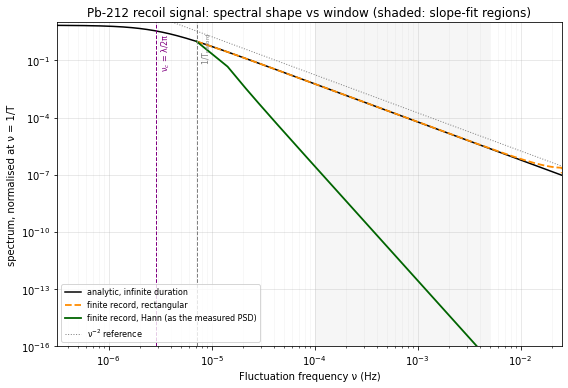

In [41]:
nu_c = LAMBDA_PB/(2*np.pi)
_, S_rect = periodogram(df_pb - df_pb.mean(), fs=fs_p, window='boxcar', detrend=False)
S_ana = lambda nu: 1/(LAMBDA_PB**2 + (2*np.pi*nu)**2)
j0 = 1                                                   # normalisation bin, ν = 1/T
curves = {'analytic (infinite)': S_ana(nu_p)/S_ana(nu_p[j0]),
          'rectangular, finite': S_rect/S_rect[j0],
          'Hann, finite': S_pb/S_pb[j0]}

def slope(nu, S, lo, hi):
    m = (nu >= lo) & (nu <= hi)
    return np.polyfit(np.log10(nu[m]), np.log10(S[m]), 1)[0]

REGIONS = [(1e-4, 1e-3), (1e-3, 5e-3)]                  # well above ν_c and 1/T, well below Nyquist
print(f'ν_c = λ/2π = {nu_c:.3e} Hz;  1/T_record = {nu_p[1]:.3e} Hz;  Nyquist = {fs_p/2:.3e} Hz')
print(f"{'':24s} | " + ' | '.join(f'slope {lo:.0e}-{hi:.0e} Hz' for lo, hi in REGIONS))
for name, S in curves.items():
    print(f'{name:24s} | ' + ' | '.join(f'{slope(nu_p, S, lo, hi):22.2f}' for lo, hi in REGIONS))

fig, ax = plt.subplots(figsize=(8, 5.5))
nu_fine = np.logspace(-6.5, np.log10(fs_p/2), 400)
ax.loglog(nu_fine, S_ana(nu_fine)/S_ana(nu_p[j0]), color='k', lw=1.5, label='analytic, infinite duration')
ax.loglog(nu_p[1:], curves['rectangular, finite'][1:], color='darkorange', lw=1.8, ls='--', label='finite record, rectangular')
ax.loglog(nu_p[1:], curves['Hann, finite'][1:], color='darkgreen', lw=1.8, label='finite record, Hann (as the measured PSD)')
ref = (nu_fine/1e-4)**-2 * (S_ana(1e-4)/S_ana(nu_p[j0]))*3
ax.loglog(nu_fine, ref, color='gray', lw=1, ls=':', label='ν$^{-2}$ reference')
ax.axvline(nu_c, color='purple', lw=1, ls='--'); ax.text(nu_c*1.08, 0.97, 'ν$_c$ = λ/2π', rotation=90, va='top', fontsize=8,
                                                          color='purple', transform=ax.get_xaxis_transform())
ax.axvline(nu_p[1], color='gray', lw=1, ls='--'); ax.text(nu_p[1]*1.08, 0.97, '1/T$_{\\rm record}$', rotation=90, va='top',
                                                          fontsize=8, color='gray', transform=ax.get_xaxis_transform())
for lo, hi in REGIONS: ax.axvspan(lo, hi, color='gray', alpha=0.07, lw=0)
ax.set_ylim(1e-16, 10); ax.set_xlim(nu_fine[0], fs_p/2)
ax.set_xlabel('Fluctuation frequency ν (Hz)'); ax.set_ylabel('spectrum, normalised at ν = 1/T')
ax.set_title('Pb-212 recoil signal: spectral shape vs window (shaded: slope-fit regions)')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

**Diagnostic result.**
- **The ν⁻⁶ fall-off is set by the Hann window, not by the exponential.** Fitted slopes (0.1–1 mHz and
  1–5 mHz): analytic −2.00 / −2.00, rectangular −2.00 / −1.98, Hann −6.00 / −6.00. ν⁻⁶ is the Hann
  window's own sidelobe roll-off.
- **Where the ν⁻² comes from.** The analytic spectrum's ν⁻² tail comes from the step at the exponential's
  onset (t = 0). The rectangular record's comes from the jump between its first and last values
  (0.488 vs 0.038 mHz), which the periodogram treats as a discontinuity. Inside the record the decay is
  smooth; neither tail carries information about the decay beyond the lowest bins. Hann tapers both ends
  to zero, which removes that edge leakage.
- **The window already matters in the second bin:** normalised at ν = 1/T, the rectangular curve is ~6×
  the Hann curve at 14 µHz. The §2.2 figure therefore uses the rectangular record for the recoil, which
  keeps the exponential's ν⁻² shape; §1.6(d) shows how much the measured PSD itself depends on the window.

### 2.3 Parallel analysis with the direct-fit estimator (comparison only)

The §1.5 primary PSD and the §2.2 Pb-212 comparison, repeated with the 60 s / 20 s **direct
continuous-frequency fit** of §1.6(g) instead of the parabolic tracker. Everything else is identical:
interval, 20 s series, mean subtraction, full-record periodograms (Hann for the noise PSD, rectangular for
the Pb overlay), normalisation, log-binning, and the unchanged physical Pb-212 model. **No
transfer-function correction is applied to either measured PSD.** The primary analysis is unchanged.

Expected: at low ν, $S_{\rm direct}/S_{\rm parab} = (G_{\rm direct}/G_{\rm parab})^2 = (1/0.794)^2 \approx 1.59$ (§1.6(f)–(h));
at higher ν the ratio follows $(G_{\rm direct}(\nu)/G_{\rm parab}(\nu))^2$, measured in §1.6(h).

std δf: parabolic 0.1396 mHz, direct 0.1296 mHz;  predicted low-ν ratio (1/0.794)² = 1.586  [(h) plateaus: 1.587]

bin |  ν (µHz) | R = S_dir/S_par (Hann, raw bin)
  1 |     7.12 |                           1.574
  2 |    14.25 |                           1.593
  3 |    21.37 |                           1.590
  4 |    28.49 |                           1.600
  5 |    35.61 |                           1.644
  6 |    42.74 |                           1.593

        band (Hz) | ratio of band means | median bin ratio | predicted (h, model)
7.1e-06-1.0e-04 |               1.591 |            1.589 |                1.588
1.0e-04-1.0e-03 |               1.607 |            1.607 |                1.588
1.0e-03-5.0e-03 |               1.548 |            1.552 |                1.561
5.0e-03-1.0e-02 |               1.244 |            1.254 |                1.331
1.0e-02-1.5e-02 |               0.745 |            0.767 |                0.881
1.5e-02-2.0e-02 |               0.271 |            0.265 | 

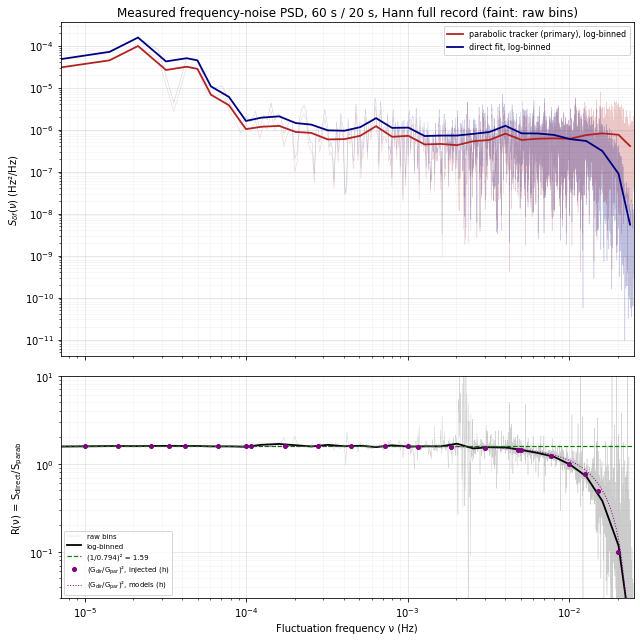

In [42]:
assert np.allclose(Tg, t_p), 'direct-fit series is not on the primary timestamps'
d_dir = Fg_dir - Fg_dir.mean()
_, S_dir = periodogram(d_dir, fs=fs_p, window='hann', detrend=False)
_, S_dir_lb, _ = log_bin(nu_p, S_dir)
_, S_dir_rect = periodogram(d_dir, fs=fs_p, window='boxcar', detrend=False)
_, S_dir_lb_rect, _ = log_bin(nu_p, S_dir_rect)

R_PRED_LOW = (1/0.794)**2
R_raw = S_dir/np.where(S_df > 0, S_df, np.nan)
R_lb = S_dir_lb/S_lb
R_inj = (GH[:, 3]/GH[:, 0])**2                           # §1.6(h), injected
R_mod = lambda nu: (g_dir_model(nu)/g_par_model(nu))**2   # §1.6(h), kernel models

print(f'std δf: parabolic {delta_f.std()*1e3:.4f} mHz, direct {d_dir.std()*1e3:.4f} mHz;  '
      f'predicted low-ν ratio (1/0.794)² = {R_PRED_LOW:.3f}  [(h) plateaus: {(pl_d/pl_p)**2:.3f}]')
print(f"\n{'bin':>3} | {'ν (µHz)':>8} | {'R = S_dir/S_par (Hann, raw bin)':>31}")
for j in range(1, 7): print(f'{j:3d} | {nu_p[j]*1e6:8.2f} | {R_raw[j]:31.3f}')
print(f"\n{'band (Hz)':>17} | {'ratio of band means':>19} | {'median bin ratio':>16} | {'predicted (h, model)':>20}")
for lo, hi in ((nu_p[1], 1e-4), (1e-4, 1e-3), (1e-3, 5e-3), (5e-3, 1e-2), (1e-2, 1.5e-2), (1.5e-2, 2e-2), (2e-2, fs_p/2)):
    b = band(nu_p, lo, hi)
    print(f'{lo:.1e}-{hi:.1e} | {S_dir[b].mean()/S_df[b].mean():19.3f} | {np.median(R_raw[b]):16.3f} | '
          f'{R_mod(np.sqrt(lo*hi))[0]:20.3f}')
dev = np.abs(R_lb/R_PRED_LOW - 1) > 0.10
onset = nu_lb[np.flatnonzero(dev & (nu_lb > 1e-4))[0]] if (dev & (nu_lb > 1e-4)).any() else np.nan
onset_mod = nu_f[np.flatnonzero(np.abs(R_mod(nu_f)/R_PRED_LOW - 1) > 0.10)[0]]
print(f'\nratio departs from 1.59 by >10% (above 0.1 mHz): log-binned measured at ν ≈ {onset*1e3:.2f} mHz, '
      f'model (h) at {onset_mod*1e3:.2f} mHz')

fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True, gridspec_kw=dict(height_ratios=[1.5, 1]))
ax[0].loglog(nu_p[1:], S_df[1:], color='firebrick', lw=0.4, alpha=0.25)
ax[0].loglog(nu_p[1:], S_dir[1:], color='navy', lw=0.4, alpha=0.25)
ax[0].loglog(nu_lb, S_lb, color='firebrick', lw=1.8, label='parabolic tracker (primary), log-binned')
ax[0].loglog(nu_lb, S_dir_lb, color='navy', lw=1.8, label='direct fit, log-binned')
ax[0].set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)'); ax[0].legend(fontsize=8)
ax[0].set_title(f'Measured frequency-noise PSD, {WIN_P:.0f} s / {STEP_P:.0f} s, Hann full record (faint: raw bins)')
ax[1].loglog(nu_p[1:], R_raw[1:], color='gray', lw=0.4, alpha=0.4, label='raw bins')
ax[1].loglog(nu_lb, R_lb, color='k', lw=1.8, label='log-binned')
ax[1].axhline(R_PRED_LOW, color='green', lw=1.2, ls='--', label='(1/0.794)² = 1.59')
ax[1].loglog(NU_H, R_inj, 'o', ms=4, color='purple', label='(G$_{\\rm dir}$/G$_{\\rm par}$)², injected (h)')
ax[1].loglog(nu_f, R_mod(nu_f), color='purple', lw=1, ls=':', label='(G$_{\\rm dir}$/G$_{\\rm par}$)², models (h)')
ax[1].set_ylim(0.03, 10); ax[1].set_ylabel('R(ν) = S$_{\\rm direct}$/S$_{\\rm parab}$')
ax[1].set_xlabel('Fluctuation frequency ν (Hz)'); ax[1].legend(fontsize=7, loc='lower left')
for a in ax: a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12); a.set_xlim(nu_p[1], fs_p/2)
plt.tight_layout(); plt.show()

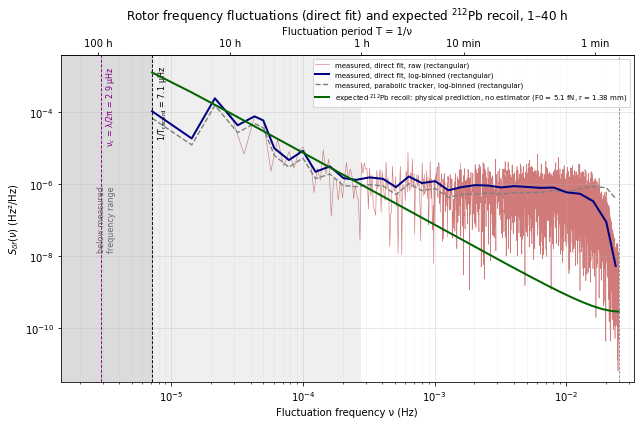

expected recoil (physical) / measured, both rectangular, raw bins:
 ν (µHz) |    recoil | meas direct |  ratio | meas parab |  ratio
     7.1 |  1.23e-03 |    1.04e-04 |  11.92 |   6.64e-05 |  18.58
    14.2 |  3.45e-04 |    1.83e-05 |  18.90 |   1.21e-05 |  28.60
    21.4 |  1.57e-04 |    2.37e-04 |   0.66 |   1.50e-04 |   1.04
    28.5 |  8.89e-05 |    7.79e-05 |   1.14 |   4.87e-05 |   1.83
    35.6 |  5.71e-05 |    6.68e-06 |   8.56 |   4.35e-06 |  13.15
    42.7 |  3.98e-05 |    7.49e-05 |   0.53 |   4.74e-05 |   0.84
band 1e-05-1e-04 Hz, recoil/measured (band means): direct 1.542, parabolic 2.440
band 1e-04-1e-03 Hz, recoil/measured (band means): direct 0.518, parabolic 0.826
band 1e-03-1e-02 Hz, recoil/measured (band means): direct 0.009, parabolic 0.013


In [43]:
# Section 2 Pb-212 comparison with the direct-fit measured PSD (rectangular, as §2.2); physical Pb model unchanged
S_dir_ov = nyq_display(S_dir_rect)
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(nu_p[1:], S_dir_ov[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1,
          label='measured, direct fit, raw (rectangular)')
ax.loglog(nu_lb, S_dir_lb_rect, color='navy', lw=2.0, zorder=3, label='measured, direct fit, log-binned (rectangular)')
ax.loglog(nu_lb, S_lb_rect, color='gray', lw=1.4, ls='--', zorder=2, label='measured, parabolic tracker, log-binned (rectangular)')
ax.loglog(nu_p[1:], S_pb_ov[1:], color='darkgreen', lw=2.0, zorder=4,
          label=f'expected $^{{212}}$Pb recoil: physical prediction, no estimator (F0 = {F0_PB*1e15:.1f} fN, r = {R_EFF*1e3:.2f} mm)')
ax.set_ylim(S_dir_ov[1:].min()*0.5, max(S_dir_ov[1:].max(), S_pb_ov[1:].max())*3)
ax.set_xlim(x_left, fs_p/2*1.3)
ax.axvline(fs_p/2, color='gray', lw=0.8, ls='--')
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.axvspan(x_left, nu_p[1], color='gray', alpha=0.28, lw=0)
ax.text(np.sqrt(x_left*nu_p[1]), 0.5, 'below measured\nfrequency range', transform=ax.get_xaxis_transform(),
        rotation=90, ha='center', va='center', fontsize=8, color='dimgray')
for x, lab, col in ((nu_p[1], f'1/T$_{{\\rm record}}$ = {nu_p[1]*1e6:.1f} µHz', 'k'),
                    (nu_c_pb, f'ν$_c$ = λ/2π = {nu_c_pb*1e6:.1f} µHz', 'purple')):
    ax.axvline(x, color=col, lw=0.9, ls='--')
    ax.text(x*1.07, 0.97, lab, transform=ax.get_xaxis_transform(), rotation=90, va='top', fontsize=8, color=col)
ax.set_xlabel('Fluctuation frequency ν (Hz)'); ax.set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency fluctuations (direct fit) and expected $^{{212}}$Pb recoil, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=7, loc='upper right')
period_top = ax.secondary_xaxis('top', functions=(inv, inv))
per = [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (10*3600, '10 h'), (100*3600, '100 h')]
period_top.set_xticks([p for p, _ in per]); period_top.set_xticklabels([l for _, l in per])
period_top.xaxis.set_minor_locator(plt.NullLocator()); period_top.set_xlabel('Fluctuation period T = 1/ν')
plt.tight_layout(); plt.show()

print('expected recoil (physical) / measured, both rectangular, raw bins:')
print(f"{'ν (µHz)':>8} | {'recoil':>9} | {'meas direct':>11} | {'ratio':>6} | {'meas parab':>10} | {'ratio':>6}")
for j in range(1, 7):
    print(f'{nu_p[j]*1e6:8.1f} | {S_pb_rect[j]:9.2e} | {S_dir_rect[j]:11.2e} | {S_pb_rect[j]/S_dir_rect[j]:6.2f} | '
          f'{S_df_rect[j]:10.2e} | {S_pb_rect[j]/S_df_rect[j]:6.2f}')
for lo, hi in ((1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2)):
    b = band(nu_p, lo, hi)
    print(f'band {lo:.0e}-{hi:.0e} Hz, recoil/measured (band means): direct {S_pb_rect[b].mean()/S_dir_rect[b].mean():.3f}, '
          f'parabolic {S_pb_rect[b].mean()/S_df_rect[b].mean():.3f}')

**§2.3 result** (comparison only; primary unchanged, no transfer-function correction):
1. **Low-ν ratio agrees with the prediction.** S_direct/S_parab = 1.591 (band mean, 7 µHz–0.1 mHz),
   and 1.574–1.644 in each of the first six bins, against (1/0.794)² = 1.586. It stays 1.55–1.61 to
   5 mHz. The two estimators see the same fluctuations; the parabolic PSD is uniformly ×0.63 at low ν.
2. **Where it changes:** the log-binned ratio departs from 1.59 by >10% at ≈ 6.4 mHz (model: 5.6 mHz).
   Above that it falls (1.24 at 5–10 mHz, 0.75 at 10–15 mHz, 0.27 at 15–20 mHz, 0.04 at 20–25 mHz),
   because the direct fit's bandwidth is narrower (§1.6(h)). Above ~10 mHz the measured ratio sits
   somewhat below the model ratio, consistent with the parabolic tracker exceeding its model there.
3. **Pb-212 comparison (rectangular, physical model unchanged).** The physical prediction is the true δf
   with no estimator; the direct-fit measured PSD has G = 1 at these ν, so this is the like-for-like
   comparison. Recoil/measured, direct (parabolic): lowest bin 11.9 (18.6), second 18.9 (28.6); band
   means 1.54 (2.44) at 10–100 µHz, 0.52 (0.83) at 0.1–1 mHz, 0.009 (0.013) at 1–10 mHz. Every ratio
   drops by ≈ 1/1.59.
4. **For Section 2:** the qualitative picture is unchanged (the recoil exceeds the measured fluctuations
   only in the lowest few bins and is a slow drift), but the parabolic estimator overstated the
   recoil-to-noise ratio by ≈ 1.6 at the ν relevant to Pb-212. The per-bin caveats of §2.2 still apply
   (single χ² estimates; the ν⁻² tail is the record's end-to-end jump).

## 3. Thermal noise floor

Fluctuation–dissipation limit from gas damping alone:
$S_\Omega(\nu) = 4k_BT\gamma / [I(\gamma^2 + (2\pi\nu)^2)]$, ASD in Hz/√Hz = √S_Ω / 2π.
Uses only I, γ = 1/τ and T_bath.

The table compares it with the measured ASD of the linearly detrended 1–40 h `FR` (September's
method, Welch at 60 s cadence), not yet with the §1.5 PSD.

In [44]:
t_res = T[mref] - T[mref][0]                     # linearly detrended 1-40 h FR (same as sigma_f_table in 4)
resid = FR[mref] - np.polyval(np.polyfit(t_res, FR[mref], 1), t_res)

def thermal_asd_f(f):
    return np.sqrt(4*KB_J*T_BATH*GAMMA/(I_TOTAL*(GAMMA**2 + (2*np.pi*f)**2)))/(2*np.pi)

dt_tr = np.median(np.diff(t_res)); fs_tr = 1/dt_tr
NPS = 256
f_tr, P_f = welch(resid, fs=fs_tr, nperseg=NPS)
asd_f = np.sqrt(P_f)
print(f"{'freq':>10} | {'measured':>10} | {'thermal':>10} | x thermal")
for fr in (1.3e-4, 1e-3, 5e-3):
    j = np.argmin(abs(f_tr - fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.3e} | {thermal_asd_f(f_tr[j]):10.3e} | {asd_f[j]/thermal_asd_f(f_tr[j]):6.0f}x')

      freq |   measured |    thermal | x thermal
   0.130mHz |  2.385e-03 |  1.057e-04 |     23x
   0.977mHz |  1.095e-03 |  1.454e-05 |     75x
   5.013mHz |  8.230e-04 |  2.834e-06 |    290x


## 4. Sensitivity: σ_f(T) → minimum torque and force

σ_f(T) = std of T-long block means of the linearly detrended `FR` over 1–40 h
(`sensitivity_20260911.ipynb` §3–4). Frequency-channel threshold:

$$\Delta\tau_{\min}(T) = \frac{2\pi I\,\gamma\,N_\sigma\,\sigma_f(T)}{1 - e^{-\gamma T}},\qquad
F_{\min} = \Delta\tau_{\min}/r$$

(force on one wing at lever arm r). **First table = regression check:** September's settings
(I = 1.7e-11, r = 1.88 mm, 1–45 h) must give 18.15 fN at 1 h and 6.96 fN at 4 h.

REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)
   T=    60 s  F=  884.39 fN
   T=   300 s  F=  165.98 fN
   T=   600 s  F=   84.33 fN
   T=  1800 s  F=   31.18 fN
   T=  3600 s  F=   18.15 fN
   T=  7200 s  F=   11.51 fN
   T= 14400 s  F=    6.96 fN
   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)

THIS NOTEBOOK: I=1.10e-11, tau=79.8 min, window 1-40 h, resid std 0.1064 mHz
      T | sigma_f (Hz) | dtau_min (N m) | F @1.38 mm (fN) | F @1.88 mm (fN)
     60 |    1.064e-04 |      6.165e-16 |          446.76 |          327.94
    300 |    7.773e-05 |      9.237e-17 |           66.94 |           49.13
    600 |    7.210e-05 |      4.418e-17 |           32.02 |           23.50
   1800 |    6.645e-05 |      1.531e-17 |           11.09 |            8.14
   3600 |    6.287e-05 |      8.585e-18 |            6.22 |            4.57
   7200 |    5.445e-05 |      5.054e-18 |            3.66 |            2.69
  14400 |    4.919e-05 |      3.735e-18 |            2.71 |      

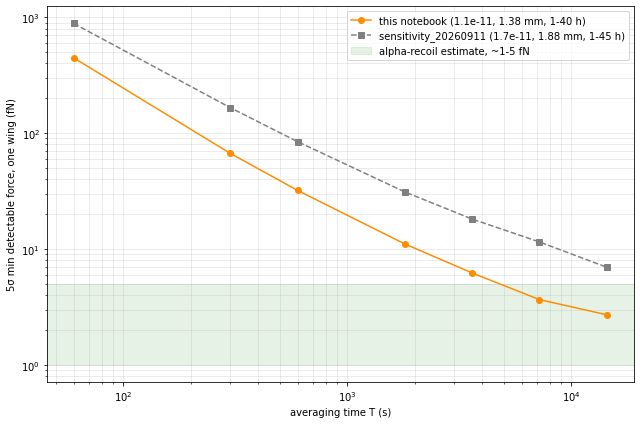

In [45]:
T_AVGS = np.array([60, 300, 600, 1800, 3600, 7200, 14400])

def window(h0, h1):
    m = (H_ALL >= h0) & (H_ALL <= h1)
    t = T[m] - T[m][0]
    return m, t

def sigma_f_table(h0, h1):
    m, t = window(h0, h1)
    r = FR[m] - np.polyval(np.polyfit(t, FR[m], 1), t)
    dt = np.median(np.diff(t)); out = []
    for Ta in T_AVGS:
        n = max(1, int(round(Ta/dt))); nb = len(r)//n
        out.append(r[:nb*n].reshape(nb, n).mean(1).std() if nb >= 4 else np.nan)
    return np.array(out), r, t

def min_torque(sf):
    return 2*np.pi*I_TOTAL*GAMMA*NSIG*sf / (1 - np.exp(-GAMMA*T_AVGS))

# --- regression check against sensitivity_20260911 ---
sf_sep, _, _ = sigma_f_table(1, 45)
F_sep = 2*np.pi*1.7e-11*GAMMA*NSIG*sf_sep/(1-np.exp(-GAMMA*T_AVGS)) / 1.88e-3
print('REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)')
for Ta, F in zip(T_AVGS, F_sep): print(f'   T={Ta:6d} s  F={F*1e15:8.2f} fN')
assert abs(F_sep[4]*1e15 - 18.15) < 0.05 and abs(F_sep[6]*1e15 - 6.96) < 0.05, 'regression failed'
print('   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)\n')

# --- this notebook's numbers ---
sf, resid, t_res = sigma_f_table(*WIN_H)
dtau = min_torque(sf)
print(f'THIS NOTEBOOK: I={I_TOTAL:.2e}, tau={TAU_S/60:.1f} min, window {WIN_H[0]}-{WIN_H[1]} h, '
      f'resid std {resid.std()*1e3:.4f} mHz')
print(f"{'T':>7} | {'sigma_f (Hz)':>12} | {'dtau_min (N m)':>14} | {'F @1.38 mm (fN)':>15} | {'F @1.88 mm (fN)':>15}")
for Ta, s, d in zip(T_AVGS, sf, dtau):
    print(f'{Ta:>7d} | {s:12.3e} | {d:14.3e} | {d/R_EFF*1e15:15.2f} | {d/R_TIP*1e15:15.2f}')
print(f'\nI systematic: with I = {I_ALT:.1e} every torque/force number is x{I_ALT/I_TOTAL:.3f}.')

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(T_AVGS, dtau/R_EFF*1e15, 'o-', color='darkorange', label=f'this notebook ({I_TOTAL:.2g}, 1.38 mm, 1-40 h)')
ax.loglog(T_AVGS, F_sep*1e15, 's--', color='gray', label='sensitivity_20260911 (1.7e-11, 1.88 mm, 1-45 h)')
ax.axhspan(1, 5, color='green', alpha=0.1, label='alpha-recoil estimate, ~1-5 fN')
ax.set_xlabel('averaging time T (s)'); ax.set_ylabel(f'{NSIG:.0f}σ min detectable force, one wing (fN)')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

## 5. Laser RIN (fractional)

RIN = (PD − dark)/mean. As in `laser_dark_vs_on.ipynb`: 1 Hz series, one global linear detrend,
Welch with 10 000 s segments (0.1 mHz resolution, trusted above ~0.3 mHz). **Dark baseline:** same
PD with the laser off, from the spindown right after the hold (dataset 2, +700 s on), so alignment
and electronics are unchanged; expressed as RIN at the same operating level.

ON level 473.84 counts, dark 1.794 -> signal 472.04 counts; 39.0 h
averages: ON ~27, DARK ~11

      band (mHz) | RIN ON (/rtHz) | DARK (/rtHz) | ON/DARK
   0.30-    1.0 |       3.39e-02 |     1.50e-03 |   22.6x
   1.00-    3.0 |       2.45e-03 |     7.91e-04 |    3.1x
   3.00-   10.0 |       7.46e-04 |     5.77e-04 |    1.3x
  10.00-  100.0 |       2.30e-04 |     1.53e-04 |    1.5x
 100.00-  500.0 |       7.38e-05 |     4.18e-05 |    1.8x


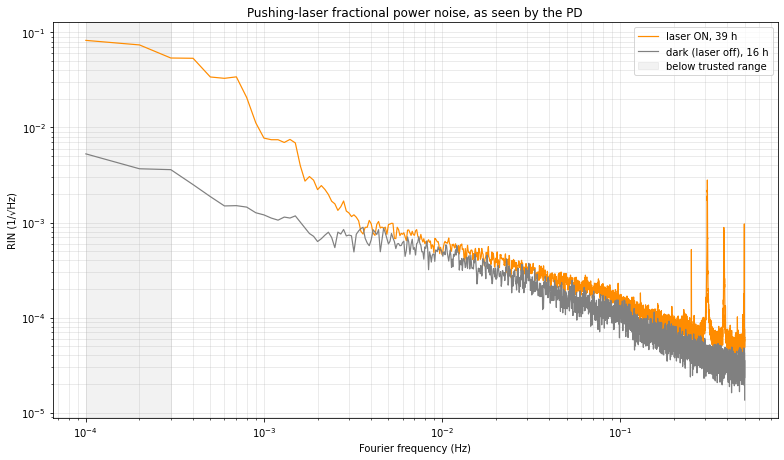

In [46]:
m1 = (tpd1 - T_REF >= WIN_H[0]*3600) & (tpd1 - T_REF < WIN_H[1]*3600)
on = pd1[m1].astype(float)
P0 = on.mean() - DARK_LEVEL
print(f'ON level {on.mean():.2f} counts, dark {DARK_LEVEL:.3f} -> signal {P0:.2f} counts; {len(on)/3600:.1f} h')

SEG_LO_S = 10000
def asd_lowf(y, fs=1.0, seg_s=SEG_LO_S):
    ts = np.arange(len(y))/fs
    yd = y - np.polyval(np.polyfit(ts, y, 1), ts)
    f, P = welch(yd, fs=fs, nperseg=int(seg_s*fs))
    return f, np.sqrt(P), len(y)/(seg_s*fs/2) - 1

f_r, a_on, n_on = asd_lowf(on)
_, a_dk, n_dk = asd_lowf(dark)
rin_on, rin_dk = a_on/P0, a_dk/P0
print(f'averages: ON ~{n_on:.0f}, DARK ~{n_dk:.0f}\n')

BANDS = [(3e-4,1e-3),(1e-3,3e-3),(3e-3,1e-2),(1e-2,1e-1),(0.1,0.5)]
print(f"{'band (mHz)':>16} | {'RIN ON (/rtHz)':>14} | {'DARK (/rtHz)':>12} | ON/DARK")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi)
    r1, r2 = np.median(rin_on[b]), np.median(rin_dk[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:14.2e} | {r2:12.2e} | {r1/r2:6.1f}x')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser fractional power noise, as seen by the PD')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 5.1 Requirement: three candidates (not yet adopted)

PI's logic (`laser_dark_vs_on.ipynb`): laser power noise enters as torque through the same response
as thermal torque, so the requirement is laser torque noise = thermal torque noise, flat in ν:
RIN_req = √(4k_BTγI) / (torque per mW × P). The candidates differ only in torque per mW:

- **(A) steady state, no calibration:** laser torque = drag torque Iγ·2πf₀, so
  RIN_req = √(4k_BTγI) / (Iγ·2πf₀). Uses only I, τ, f₀; assumes k = 1.
- **(B) PI's number:** 0.735 µW/√Hz at the chamber, as RIN at 5.8 mW. Uses κ_PD = 7.35e-16 N·m/count
  and 16.2 counts/mW (July step-down, τ = 67.65 min); `apparatus_log.md` flags both as July-only.
  Implies a laser torque 6.4× the drag torque here.
- **(C) 09-15 step-down slope, 1030 → 1010 counts** (§8; Δf_ss ≈ 21 mHz). A band because ΔP isn't
  measured: strict edge = commanded counts (11.87 µW/count), lax edge = step-down PD (suspect).
  Provisional; it is the local slope at 1030–1010, not at 1300.

(B) and (C) as RIN need the 5.8 mW calibration; (A) doesn't. §6 measures |k| < 0.033, so each line
answers "*if* the PD wander reached the sail as torque, would it matter?"; §7 uses the measured k.

thermal torque ASD 6.170e-18 N m/rtHz (tau = 79.8 min); drag torque at f0 = 0.74905 Hz: 1.081e-14 N m
(C): df_ss = 21.05 mHz over dP = 237 uW (commanded) / 395 uW (PD)

                         candidate | torque/mW (N m) | req (uW/rtHz) | RIN req (/rtHz)
     (A) steady-state ratio, k = 1 |        1.86e-15 |          3.31 |        5.71e-04
                (B) PI, July kappa |        1.19e-14 |          0.52 |        8.93e-05
 (C) step 1030->1010, commanded dP |        1.28e-15 |          4.82 |        8.31e-04
        (C) step 1030->1010, PD dP |        7.70e-16 |          8.01 |        1.38e-03

(B) implies a laser torque at 5.8 mW of 6.91e-14 N m = 6.4x the drag torque

      band (mHz) |    RIN ON | x req (A) | x req (B) |    x req (C)
   0.30-    1.0 |  3.39e-02 |     59.5x |    380.0x |  24.6-40.8x
   1.00-    3.0 |  2.45e-03 |      4.3x |     27.4x |   1.8- 2.9x
   3.00-   10.0 |  7.46e-04 |      1.3x |      8.4x |   0.5- 0.9x
  10.00-  100.0 |  2.30e-04 |      0.4x |      2.6x 

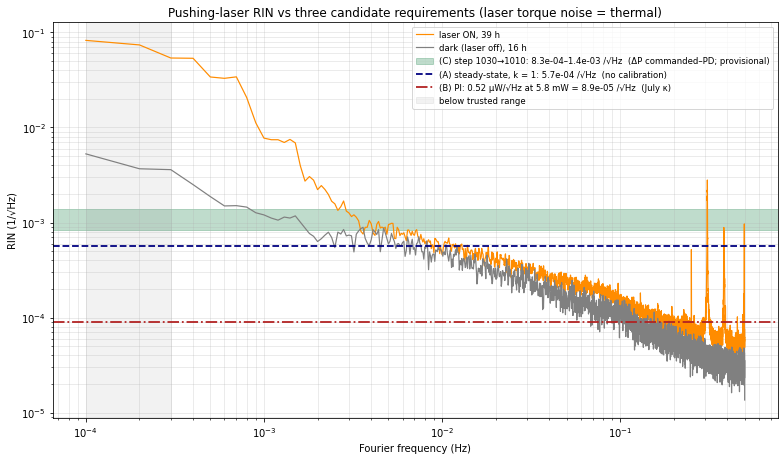

In [47]:
# Three candidate requirements on the same RIN plot (see markdown above) -- for choosing, not yet adopted
mR, _ = window(*WIN_H)
f0_hold = FR[mR].mean()
S_N_TH = np.sqrt(4*KB_J*T_BATH*GAMMA*I_TOTAL)       # thermal torque ASD, N m/rtHz
N_HOLD = I_TOTAL*GAMMA*2*np.pi*f0_hold              # drag torque at f0 = the laser torque, if the laser holds the rotor
P_CHAMBER_MW = 5.8                                  # LASER_OFFSET 1300 (dataset notes) -- itself a power calibration

# (A) calibration-free: torque per mW = steady-state ratio N_HOLD / P (k = 1)
TPM_A = N_HOLD/P_CHAMBER_MW
# (B) PI / laser_dark_vs_on: kappa_PD 7.35e-16 N m/count x 16.2 cts/mW (July step-down, tau 67.65 min -> 0.735 uW/rtHz)
TPM_B = 7.3499e-16*167.6/10.34
# (C) slope from the 09-15 step-down, 1030 -> 1010 (the only clean, large, plateaued pair; §8 table)
st = pd.read_csv('stepdown_20260914_steps.csv').drop_duplicates('offset').set_index('offset')
df_step = st.loc[1030, 'f_ss'] - st.loc[1010, 'f_ss']
dP_cmd = 20*11.87e-3                                # mW: commanded counts x 11.87 uW/count (apparatus_log, "still good")
dP_pd = (360.62 - 329.09)/463.23*P_CHAMBER_MW       # mW: step-down PD means (stepdown_20260914 §4); 463 cts at 1300
TPM_C = np.array([I_TOTAL*GAMMA*2*np.pi*df_step/dP for dP in (dP_cmd, dP_pd)])   # N m/mW, [commanded, PD]

rin_req = lambda tpm: S_N_TH/tpm/P_CHAMBER_MW       # laser torque noise = thermal  ->  RIN at this run's power
RIN_REQ_SS, RIN_REQ_PI, RIN_REQ_C = rin_req(TPM_A), rin_req(TPM_B), rin_req(TPM_C)

print(f'thermal torque ASD {S_N_TH:.3e} N m/rtHz (tau = {TAU_S/60:.1f} min); drag torque at f0 = {f0_hold:.5f} Hz: {N_HOLD:.3e} N m')
print(f'(C): df_ss = {df_step*1e3:.2f} mHz over dP = {dP_cmd*1e3:.0f} uW (commanded) / {dP_pd*1e3:.0f} uW (PD)\n')
print(f"{'candidate':>34} | {'torque/mW (N m)':>15} | {'req (uW/rtHz)':>13} | {'RIN req (/rtHz)':>15}")
for name, tpm in [('(A) steady-state ratio, k = 1', TPM_A), ('(B) PI, July kappa', TPM_B),
                  ('(C) step 1030->1010, commanded dP', TPM_C[0]), ('(C) step 1030->1010, PD dP', TPM_C[1])]:
    print(f'{name:>34} | {tpm:15.2e} | {S_N_TH/tpm*1e3:13.2f} | {rin_req(tpm):15.2e}')
print(f'\n(B) implies a laser torque at {P_CHAMBER_MW} mW of {TPM_B*P_CHAMBER_MW:.2e} N m = {TPM_B*P_CHAMBER_MW/N_HOLD:.1f}x the drag torque\n')

def crossing(req, nsm=9):
    """Lowest trusted frequency where the (running-median) ON RIN falls below req."""
    sm = np.array([np.median(rin_on[max(i-nsm//2, 0):i+nsm//2+1]) for i in range(len(rin_on))])
    ok = (f_r > 3e-4) & (sm < req)
    return f_r[ok][0] if ok.any() else np.nan

print(f"{'band (mHz)':>16} | {'RIN ON':>9} | {'x req (A)':>9} | {'x req (B)':>9} | {'x req (C)':>12}")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi); r1 = np.median(rin_on[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:9.2e} | {r1/RIN_REQ_SS:8.1f}x | {r1/RIN_REQ_PI:8.1f}x | '
          f'{r1/RIN_REQ_C[1]:5.1f}-{r1/RIN_REQ_C[0]:4.1f}x')
print(f'\nON RIN falls below (A) above ~{crossing(RIN_REQ_SS)*1e3:.1f} mHz, (B) above ~{crossing(RIN_REQ_PI)*1e3:.1f} mHz, '
      f'(C, strict edge) above ~{crossing(RIN_REQ_C[0])*1e3:.1f} mHz')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axhspan(*RIN_REQ_C, color='seagreen', alpha=0.3,
           label=f'(C) step 1030→1010: {RIN_REQ_C[0]:.1e}–{RIN_REQ_C[1]:.1e} /√Hz  (ΔP commanded–PD; provisional)')
ax.axhline(RIN_REQ_SS, color='navy', ls='--', lw=1.8,
           label=f'(A) steady-state, k = 1: {RIN_REQ_SS:.1e} /√Hz  (no calibration)')
ax.axhline(RIN_REQ_PI, color='firebrick', ls='-.', lw=1.8,
           label=f'(B) PI: {S_N_TH/TPM_B*1e3:.2f} µW/√Hz at {P_CHAMBER_MW} mW = {RIN_REQ_PI:.1e} /√Hz  (July κ)')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser RIN vs three candidate requirements (laser torque noise = thermal)')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 5.2 Does the power wander average down?

Boxcar-smoothed, detrended fractional std vs the white-noise prediction (`laser_dark_vs_on.ipynb` §6).
Ratio ≫ 1 means correlated wander.

In [48]:
print(f"{'boxcar':>7} | {'fractional std':>14} | {'white pred.':>11} | ratio")
for mins in [1, 5, 10, 30, 60, 120, 240]:
    n = mins*60
    sm = uniform_filter1d(on, n)[n//2:-n//2]
    ts = np.arange(len(sm)); sm = sm - np.polyval(np.polyfit(ts, sm, 1), ts)
    meas, pred = sm.std()/P0, on.std()/P0/np.sqrt(n)
    print(f'{mins:5d} m | {meas:14.2e} | {pred:11.2e} | {meas/pred:5.0f}x')
print(f'\nfor comparison, rotor fractional frequency std at 1 h: {sf[4]/FR[window(*WIN_H)[0]].mean():.2e}')

 boxcar | fractional std | white pred. | ratio
    1 m |       2.23e-03 |    3.06e-04 |     7x
    5 m |       2.21e-03 |    1.37e-04 |    16x
   10 m |       2.16e-03 |    9.69e-05 |    22x
   30 m |       1.94e-03 |    5.59e-05 |    35x
   60 m |       1.77e-03 |    3.95e-05 |    45x
  120 m |       1.59e-03 |    2.80e-05 |    57x
  240 m |       1.46e-03 |    1.98e-05 |    74x

for comparison, rotor fractional frequency std at 1 h: 8.39e-05


## 6. Correlation: does the PD wander show up in the rotor frequency?

If torque follows power, $\frac{\delta f}{f}(\omega) = k\,\frac{1}{1 + i\omega\tau}\,\frac{\delta P}{P}(\omega)$;
k is the DC gain (k = 1 for torque ∝ power, linear drag, no other torques). Both series share the
tracker's 150 s windows (PD averaged over the same windows, §1.1).

### 6.1 Frequency and PD on the same fractional scale

Deviation from each series' own 1–40 h mean, in ‰, on one axis (the raw axes span ~1% vs ~170%).
Top: whole file (the PD slide after 40.5 h and the 45.5 h jump run off-scale; the first hour is
spin-up). Bottom: 1–40 h, 30 min running mean, the timescale where a laser effect would appear
after the ~80 min rotor response.

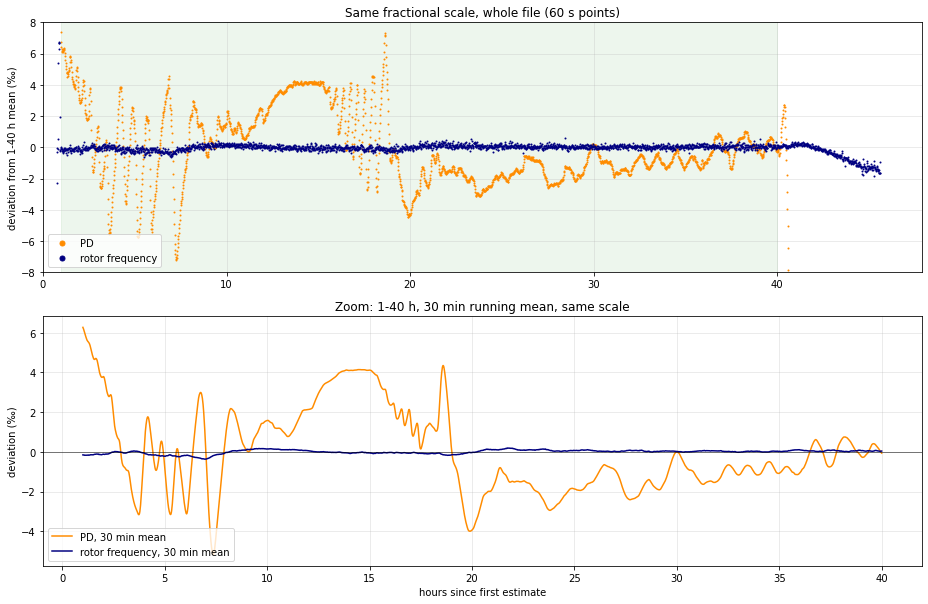

In [49]:
f_ref, p_ref = FR[mref].mean(), PDW[mref].mean() - DARK_LEVEL
dfr = (FR/f_ref - 1)*1e3                        # permil
dpd = ((PDW - DARK_LEVEL)/p_ref - 1)*1e3

fig, ax = plt.subplots(2, 1, figsize=(13, 8.5))
ax[0].plot(H_ALL, dpd, '.', ms=2, color='darkorange', label='PD')
ax[0].plot(H_ALL, dfr, '.', ms=2, color='navy', label='rotor frequency')
ax[0].axvspan(*WIN_H, color='green', alpha=0.07)
ax[0].set_ylim(-8, 8); ax[0].set_xlim(0, H_ALL.max())
ax[0].set_ylabel('deviation from 1-40 h mean (‰)')
ax[0].set_title('Same fractional scale, whole file (60 s points)')
ax[0].legend(loc='lower left', markerscale=5)

N30 = int(round(1800/np.median(np.diff(T))))
h_w = H_ALL[mref]
sm = lambda z: uniform_filter1d(z, N30, mode='nearest')
ax[1].plot(h_w, sm(dpd[mref]), color='darkorange', lw=1.5, label='PD, 30 min mean')
ax[1].plot(h_w, sm(dfr[mref]), color='navy', lw=1.5, label='rotor frequency, 30 min mean')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_ylabel('deviation (‰)'); ax[1].set_xlabel('hours since first estimate')
ax[1].set_title(f'Zoom: {WIN_H[0]}-{WIN_H[1]} h, 30 min running mean, same scale')
ax[1].legend(loc='lower left')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [50]:
print(f'1-40 h, 30 min means: PD std {sm(dpd[mref]).std():.2f} ‰, frequency std {sm(dfr[mref]).std():.3f} ‰ '
      f'(ratio {sm(dpd[mref]).std()/sm(dfr[mref]).std():.0f}x)')

1-40 h, 30 min means: PD std 2.12 ‰, frequency std 0.101 ‰ (ratio 21x)


### 6.2 DC gain k: matched fit

Both series linearly detrended over 1–40 h. δP/P is passed through the model (k = 1) and
least-squares scaled onto δf/f. Null: circular PD shifts ≥ 4 h (breaks any link, keeps each series'
colour). An injection test checks that a known k is recovered. (Replaces the planned coherence
estimator; see §6.3.)

In [51]:
mW, tW = window(*WIN_H)
def det(z): return z - np.polyval(np.polyfit(tW, z, 1), tW)
x = det((PDW[mW] - DARK_LEVEL)/P0)            # fractional power
y = det(FR[mW]/FR[mW].mean())                 # fractional frequency
dtW = np.median(np.diff(tW))

def response(xx, tau_s=TAU_S):
    a = dtW/tau_s
    return lfilter([a], [1, -(1-a)], xx)

def k_matched(xx, yy, tau_s=TAU_S):
    u = det(response(xx, tau_s))
    return np.dot(u, yy)/np.dot(u, u)

rng = np.random.default_rng(1)
SHIFTS = rng.integers(240, len(x) - 240, 2000)          # >= 4 h at 60 s cadence
k0 = k_matched(x, y)
null = np.array([k_matched(np.roll(x, s), y) for s in SHIFTS])
lo95, hi95 = np.percentile(null - null.mean(), [2.5, 97.5])
K_UL = max(abs(k0 - null.mean() + lo95), abs(k0 - null.mean() + hi95))
print(f'k (tau = {TAU_S/60:.1f} min) = {k0:+.4f} ± {null.std():.4f}   '
      f'({(k0-null.mean())/null.std():+.1f} σ from the shift-null)')
print(f'95% interval for k: [{k0-null.mean()+lo95:+.4f}, {k0-null.mean()+hi95:+.4f}]  ->  |k| < {K_UL:.3f}')

print('\ninjection test (y + k_true * model response to the measured PD):')
for kt in [0.01, 0.03, 0.1, 0.3, 1.0]:
    k_rec = k_matched(x, y + det(kt*response(x)))
    print(f'   k_true = {kt:5.2f} -> recovered {k_rec:+.4f}   (expected {k0+kt:+.4f})')

print('\nrobustness to the assumed response time:')
for tm in [5, 20, 44, 79.8, 160]:
    kk = k_matched(x, y, tm*60)
    nn = np.array([k_matched(np.roll(x, s), y, tm*60) for s in SHIFTS[:500]])
    print(f'   tau = {tm:5.1f} min: k = {kk:+.4f} ± {nn.std():.4f}')

print(f'\nfor scale: measured δf/f std {y.std():.2e}; predicted std if k = 1: {det(response(x)).std():.2e}')

k (tau = 79.8 min) = -0.0105 ± 0.0143   (-0.9 σ from the shift-null)
95% interval for k: [-0.0326, +0.0149]  ->  |k| < 0.033

injection test (y + k_true * model response to the measured PD):
   k_true =  0.01 -> recovered -0.0005   (expected -0.0005)
   k_true =  0.03 -> recovered +0.0195   (expected +0.0195)
   k_true =  0.10 -> recovered +0.0895   (expected +0.0895)
   k_true =  0.30 -> recovered +0.2895   (expected +0.2895)
   k_true =  1.00 -> recovered +0.9895   (expected +0.9895)

robustness to the assumed response time:
   tau =   5.0 min: k = -0.0070 ± 0.0083
   tau =  20.0 min: k = -0.0071 ± 0.0109
   tau =  44.0 min: k = -0.0077 ± 0.0128
   tau =  79.8 min: k = -0.0105 ± 0.0144
   tau = 160.0 min: k = -0.0171 ± 0.0177

for scale: measured δf/f std 1.42e-04; predicted std if k = 1: 1.46e-03


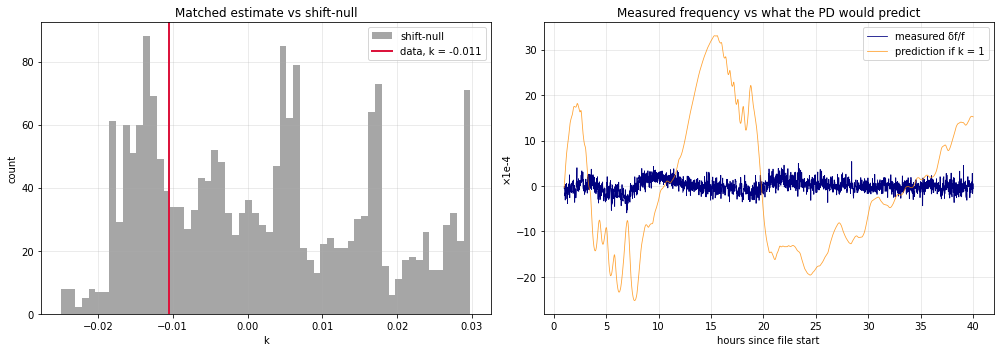

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(null, bins=60, color='gray', alpha=0.7, label='shift-null')
ax[0].axvline(k0, color='crimson', lw=2, label=f'data, k = {k0:+.3f}')
ax[0].set_xlabel('k'); ax[0].set_ylabel('count'); ax[0].legend(); ax[0].set_title('Matched estimate vs shift-null')
hh = tW/3600 + WIN_H[0]
ax[1].plot(hh, y*1e4, lw=0.8, color='navy', label='measured δf/f')
ax[1].plot(hh, det(response(x))*1e4, lw=0.8, color='darkorange', alpha=0.8, label='prediction if k = 1')
ax[1].set_xlabel('hours since file start'); ax[1].set_ylabel('×1e-4'); ax[1].legend()
ax[1].set_title('Measured frequency vs what the PD would predict')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 6.3 Coherence (diagnostic only)

The planned coherence/transfer-function estimate over 0.1–5 mHz failed the injection test: that band
is above the rotor corner (γ/2π ≈ 33 µHz), where a laser signal is suppressed by 1/(2πντ) and buried
in rotor noise. Shown, not used for k.

9 independent segments -> 95% null coherence ~ 0.31; median in 0.1-5 mHz = 0.05; bins above null: 8 of 75


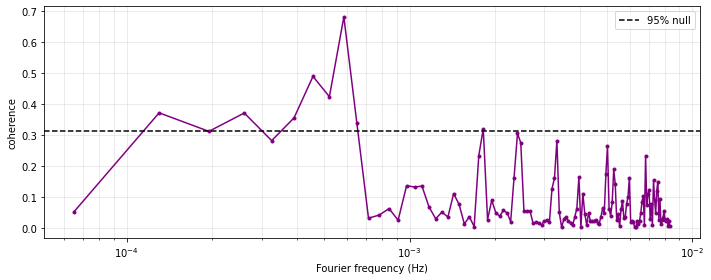

In [53]:
f_c, C = coherence(x, y, fs=1/dtW, nperseg=NPS)
n_ind = len(x)//NPS
C95 = 1 - 0.05**(1/(n_ind - 1))
band = (f_c >= 1e-4) & (f_c <= 5e-3)
print(f'{n_ind} independent segments -> 95% null coherence ~ {C95:.2f}; '
      f'median in 0.1-5 mHz = {np.median(C[band]):.2f}; bins above null: {(C[band] > C95).sum()} of {band.sum()}')
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(f_c[1:], C[1:], '.-', color='purple'); ax.axhline(C95, color='k', ls='--', label='95% null')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('coherence'); ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 7. Noise projection

Rotor-frequency ASD (Hz/√Hz), 60 s grid:
- **measured:** from §3 (linearly detrended `FR`);
- **laser at the 95% upper limit on k:** |K_UL| · |1/(1+i2πντ)| · RIN · f₀, RIN from the
  window-averaged PD (same smoothing);
- **thermal:** the §3 floor.

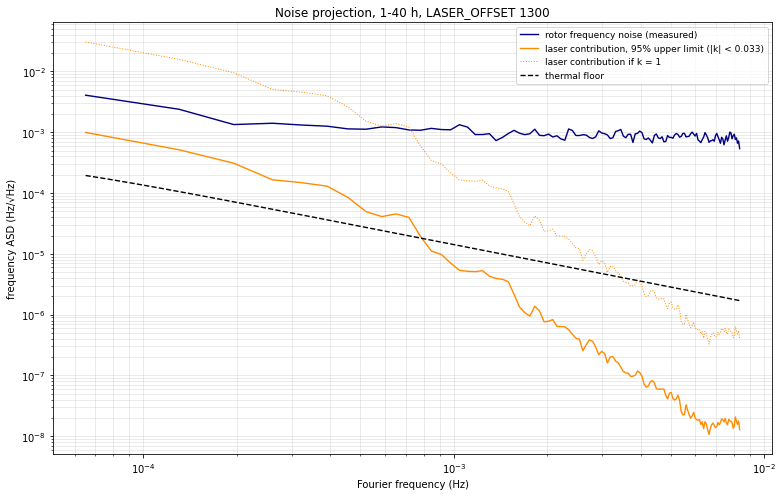

      freq |   measured | laser (UL) | laser if k=1 |    thermal
   0.130mHz |   2.38e-03 |   5.15e-04 |     1.58e-02 |   1.06e-04
   0.521mHz |   1.12e-03 |   4.96e-05 |     1.52e-03 |   2.72e-05
   0.977mHz |   1.10e-03 |   7.05e-06 |     2.16e-04 |   1.45e-05
   5.013mHz |   8.23e-04 |   5.26e-08 |     1.61e-06 |   2.83e-06


In [54]:
f0 = FR[mW].mean()
f_x, P_x = welch(x, fs=1/dtW, nperseg=NPS)
rin_w = np.sqrt(P_x)
M = np.abs(1/(1 + 2j*np.pi*f_x*TAU_S))
laser_proj = K_UL * M * rin_w * f0

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(f_tr[1:], asd_f[1:], color='navy', lw=1.4, label='rotor frequency noise (measured)')
ax.loglog(f_x[1:], laser_proj[1:], color='darkorange', lw=1.4, label=f'laser contribution, 95% upper limit (|k| < {K_UL:.3f})')
ax.loglog(f_x[1:], (M*rin_w*f0)[1:], color='darkorange', lw=1, ls=':', label='laser contribution if k = 1')
fl = np.logspace(np.log10(f_tr[1]), np.log10(f_tr[-1]), 200)
ax.loglog(fl, thermal_asd_f(fl), 'k--', lw=1.4, label='thermal floor')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('frequency ASD (Hz/√Hz)')
ax.set_title('Noise projection, 1-40 h, LASER_OFFSET 1300')
ax.legend(fontsize=9); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

print(f"{'freq':>10} | {'measured':>10} | {'laser (UL)':>10} | {'laser if k=1':>12} | {'thermal':>10}")
for fr in (1.3e-4, 5e-4, 1e-3, 5e-3):
    j, i = np.argmin(abs(f_tr-fr)), np.argmin(abs(f_x-fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.2e} | {laser_proj[i]:10.2e} | {(M*rin_w*f0)[i]:12.2e} | {thermal_asd_f(f_tr[j]):10.2e}')

## 8. Step-down observations, 09-14/15 (reported, not interpreted)

From `stepdown_20260914_steps.csv` (`stepdown_20260914.ipynb`): same rotor, nearby operating points.
The cause is not understood, and no number here depends on it.

In [55]:
steps = pd.read_csv('stepdown_20260914_steps.csv')
print(steps[['offset', 'utc', 'f_ss', 'tau_min', 'rms_mHz', 'plateaued']].to_string(index=False))
print(f'\nfree-decay tau for comparison: {TAU_S/60:.1f} min')

 offset                  utc     f_ss    tau_min  rms_mHz  plateaued
 1300.0 2026-09-14T21:52:36Z 0.749712  22.626916 0.060024       True
 1250.0 2026-09-14T23:02:38Z 0.749503 480.000000 0.065762       True
 1200.0 2026-09-15T00:12:39Z 0.750269  21.649185 0.058791       True
 1150.0 2026-09-15T01:22:40Z 0.750432   5.790409 0.067735       True
 1100.0 2026-09-15T02:32:41Z 0.750510  18.254454 0.070418       True
 1050.0 2026-09-15T03:42:42Z 0.751010  63.136473 1.546137       True
 1040.0 2026-09-15T04:52:43Z 0.749844 479.999494 0.333297       True
 1030.0 2026-09-15T06:02:44Z 0.748393   7.206929 0.449694       True
 1020.0 2026-09-15T08:02:46Z 0.736822  44.070252 0.415704       True
 1010.0 2026-09-15T09:37:48Z 0.727340  31.943333 0.306891       True
 1000.0 2026-09-15T10:47:49Z 0.701059  30.373375 1.802495      False
 1000.0 2026-09-15T12:47:51Z 0.684193 146.330083 1.020672      False

free-decay tau for comparison: 79.8 min


Observations:
- **1300 → 1050 counts:** f_ss stays within 0.7497–0.7510 Hz while the PD drops ~18%. τ unconstrained
  (6–480 min): no step to fit.
- **1030 → 1020 → 1010:** f_ss 0.7484 → 0.7368 → 0.7273 Hz; τ 44 and 32 min (< 79.8 min free decay).
- **1000:** no plateau; the frequency keeps falling.

Consistent with §6 (no response to PD wander at 1300). Neither says why.

## 9. Conclusions

1. **Sensitivity (5σ, one wing, I = 1.1e-11, τ = 79.8 min, r = 1.38 mm, 1–40 h): ~6.2 fN at 1 h,
   ~2.7 fN at 4 h** (447 fN at 1 min). Better than September's 18 / 7 fN, from dropping 40–45 h
   (σ_f at 1 h: 1.6e-4 → 6.3e-5 Hz) and the smaller I; the shorter lever arm works the other way.
   Systematics: I ±10% from the weighing (0.99–1.21e-11); ×0.73 with the tip lever arm. The regression check
   reproduces September exactly.
2. **Rotor noise vs thermal:** 23× at 0.13 mHz, ~75× at 1 mHz, ~290× at 5 mHz. Technical-noise limited.
3. **Laser RIN (as the PD sees it):** 3.4e-2 /√Hz at 0.3–1 mHz, 23× the dark floor; doesn't average
   down (45× white at 1 h); at the dark floor above ~3 mHz. Fractional wander at 1 h: 1.8e-3 (power)
   vs 8.4e-5 (rotor frequency).
4. **Correlation: k = −0.011 ± 0.014; |k| < 0.033 (95%)**, for any assumed response time 5–160 min.
   With k = 1 the rotor would wander ~10× more than measured. The injection test recovers k.
5. **Noise projection:** at the k upper limit the laser (as the PD sees it) is below the measured rotor
   noise everywhere; it doesn't explain the rotor wander at 1300.

**Caveat.** A null k at 1300 fits either (a) the PD wander isn't power reaching the sail, or (b) the
rotor doesn't respond to torque changes at this operating point (§8). Not separable here; (b) would
affect the sensitivity, which assumes the free-decay response. Would separate them: a calibrated
torque step at 1300; an independent power monitor at the sail.

**Open:** the 40.5 h PD slide and 45.5 h jump; lab temperature as a correlation witness
(`ambient_temp_pull.py`); the imaging-beam null test.

In [56]:
print(f'SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = {I_TOTAL:.2g}, tau = 79.8 min, 1-40 h):')
for Ta, d in zip(T_AVGS, dtau):
    if Ta in (60, 3600, 14400): print(f'   {Ta/60:6.0f} min : {d/R_EFF*1e15:7.2f} fN')
print(f'   (x{I_ALT/I_TOTAL:.2f} with I = 1.7e-11; x{R_EFF/R_TIP:.2f} with the tip lever arm)')
b = (f_r > 3e-4) & (f_r < 1e-3)
print(f'LASER RIN 0.3-1 mHz: {np.median(rin_on[b]):.1e} /rtHz ({np.median(rin_on[b])/np.median(rin_dk[b]):.0f}x the dark floor)')
print(f'CORRELATION: k = {k0:+.4f} ± {null.std():.4f};  |k| < {K_UL:.3f} (95%)')

SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = 1.1e-11, tau = 79.8 min, 1-40 h):
        1 min :  446.76 fN
       60 min :    6.22 fN
      240 min :    2.71 fN
   (x1.55 with I = 1.7e-11; x0.73 with the tip lever arm)
LASER RIN 0.3-1 mHz: 3.4e-02 /rtHz (23x the dark floor)
CORRELATION: k = -0.0105 ± 0.0143;  |k| < 0.033 (95%)
